**Машинки** **2024**

# 1 семестр

In [ ]:
# Линейная регрессия задание номер 1
import numpy as np

def fit_func_matrix(x):
    return np.column_stack([
        np.sin(x), np.cos(x), x, np.ones_like(x)
    ])

with open("input.txt", 'r') as file:
    N = int(file.readline().strip())
    y = np.array(list(map(float, file.readline().strip().split())))

x = np.arange(len(y))
X = fit_func_matrix(x)

params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

x_pred = np.arange(max(N + 1, len(y)))
X_pred = fit_func_matrix(x_pred)
predictions_full = X_pred @ params

with open("output.txt", 'w') as file:
    file.write(f"{predictions_full[N]:.3f}\n")


In [ ]:
# Данил
import numpy as np

def linear_regression_extrapolation(file_input, file_output):
    with open(file_input, 'r') as f:
        N = int(f.readline().strip())
        values = list(map(float, f.readline().strip().split()))

    x = np.arange(N)
    y = np.array(values)

    A = np.vstack([x, np.ones(N)]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]

    x_new = N
    y_new = m * x_new + c

    with open(file_output, 'w') as f:
        f.write(f"{y_new:.3f}\n")

linear_regression_extrapolation('input.txt', 'output.txt')


In [ ]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

def read_input(file_path):
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    with open(file_path, 'w') as file:
        file.write(f"{result:.6f}\n")

def predict_next_value(input_file, output_file):
    N, values = read_input(input_file)

    x = np.arange(N)
    y = np.array(values)

    # Сглаживание данных
    # y_smoothed = savgol_filter(y, window_length=min(7, N), polyorder=2)
    y_smoothed = y

    # Экстраполяция с использованием сплайнов
    spline = CubicSpline(x, y_smoothed, bc_type='natural')
    predicted_value = spline(N)

    print(f"Сглаженные значения: {y_smoothed}")
    print(f"Предсказанное значение: {predicted_value}")

    write_output(output_file, predicted_value)

predict_next_value("input.txt", "output.txt")


Сглаженные значения: [700.949074 715.616206 726.958614 730.983909 730.42702 ]
Предсказанное значение: 729.8701309999999


In [ ]:
import numpy as np

def read_input(file_path):
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    with open(file_path, 'w') as file:
        file.write(f"{result:.12f}\n")

def predict_next_value(input_file, output_file):
    N, values = read_input(input_file)

    x = np.arange(N)
    y = np.array(values)

    # Полиномиальная интерполяция без сглаживания
    coefficients = np.polyfit(x, y, deg=4)  # Точная интерполяция
    poly = np.poly1d(coefficients)

    predicted_value = poly(N)

    print(f"Коэффициенты полинома: {coefficients}")
    print(f"Предсказанное значение: {predicted_value}")

    write_output(output_file, predicted_value)

predict_next_value("input.txt", "output.txt")


Коэффициенты полинома: [ 2.80304917e-01 -2.34722767e+00  3.41718658e+00  1.33168682e+01
  7.00949074e+02]
Предсказанное значение: 734.7501939999992


In [ ]:
# Задача 01B. Экстраполяция
import numpy as np
from scipy.optimize import curve_fit

def read_input(file_path):
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    with open(file_path, 'w') as file:
        file.write(f"{result:.13f}\n")

def model(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

def extrapolation(input_file, output_file):
    N, values = read_input(input_file)

    x = np.arange(N)
    y = np.array(values)

    try:
        # params, _ = curve_fit(model, x, y, p0=[1, 0.1, 0, 1, y[0]])
        # params, _ = curve_fit(model, x, y, p0=[0.5, 0.01, 0, 0.1, np.mean(y)])
        # params, _ = curve_fit(model, x, y, p0=[10, 0.1, 0, 0.1, np.mean(y)], maxfev=10000)

        params, _ = curve_fit(model, x, y, p0=[0.7, 0.015, 0.01, 0.05, y[0]], maxfev=20000)


        predicted_value = model(N, *params)
    except RuntimeError:
        coefficients = np.polyfit(x, y, deg=min(4, N-1))
        poly = np.poly1d(coefficients)
        predicted_value = poly(N)

    write_output(output_file, predicted_value)

extrapolation("input.txt", "output.txt")

# Я получил такой ответ: 732.2357136181301, нужно настроить параметры чтобы получить точно такой результат:732.2357177317001

<ipython-input-35-2fc55594880e>:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(model, x, y, p0=[0.7, 0.015, 0.01, 0.05, y[0]], maxfev=20000)


In [ ]:
732.2357177317001

Я получил такой ответ: 732.2357136181301, нужно настроить параметры чтобы получить точно такой результат:732.2357177317001

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from itertools import product
from decimal import Decimal

def read_input(file_path):
    """Чтение данных из файла."""
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    """Запись результата в файл."""
    with open(file_path, 'w') as file:
        file.write(f"{result:.13f}\n")

def model(x, a, b, c, d, e):
    """Синусоидально-линейная модель."""
    return a * np.sin(b * x + c) + d * x + e

def find_best_fit(x, y, model, ranges, max_attempts=20000):
    """Автоматический подбор параметров модели."""
    best_params = None
    best_error = float('inf')

    for p0 in product(*ranges):
        try:
            params, _ = curve_fit(model, x, y, p0=p0, maxfev=max_attempts)
            error = np.sum((y - model(x, *params))**2)
            if error < best_error:
                best_error = error
                best_params = params
        except RuntimeError:
            continue

    return best_params

def extrapolation(input_file, output_file):
    """Основная функция для экстраполяции."""
    N, values = read_input(input_file)

    x = np.arange(len(values))
    y = np.array(values)

    predicted_value = None
    errors = []
    predictions = []

    # Диапазоны параметров для автоматического подбора
    ranges = [
        [0.5, 1, 5],  # Для a
        [0.01, 0.05, 0.1],  # Для b
        [0, 0.1, 0.5],  # Для c
        [-0.1, 0.0, 0.1],  # Для d
        [np.min(y), np.mean(y), np.max(y)]  # Для e
    ]

    # Попробуем синусоидальную модель
    try:
        params = find_best_fit(x, y, model, ranges)
        if params is not None:  # Проверяем, что параметры найдены
            predictions.append(model(N, *params))
            errors.append(np.sum((y - model(x, *params))**2))
    except RuntimeError as e:
        print(f"Ошибка подбора синусоидальной модели: {e}")

    # Попробуем полином степени 3–5
    for degree in range(3, 6):
        try:
            coefficients = np.polyfit(x, y, deg=min(degree, len(x) - 1))
            poly = np.poly1d(coefficients)
            predictions.append(poly(N))
            errors.append(np.sum((y - poly(x))**2))
        except Exception as e:
            print(f"Ошибка подбора полинома степени {degree}: {e}")

    # Выбираем лучшее предсказание
    if errors:
        best_index = np.argmin(errors)
        predicted_value = predictions[best_index]
    else:
        predicted_value = 0.0  # Если ничего не удалось предсказать

    # Используем Decimal для точного округления результата
    write_output(output_file, float(Decimal(predicted_value).quantize(Decimal('1.0000000000000'))))

# Запуск программы
extrapolation("input.txt", "output.txt")


<ipython-input-41-3d13c1747f3b>:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(model, x, y, p0=p0, maxfev=max_attempts)


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from mpmath import mp

# Устанавливаем точность mpmath
mp.dps = 20  # Устанавливаем точность до 20 десятичных знаков

def model(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

def extrapolation_high_precision(input_file, output_file):
    # Читаем данные
    with open(input_file, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))

    x = np.arange(N, dtype=np.float64)
    y = np.array(values, dtype=np.float64)

    # Начальные параметры
    p0 = [0.5, 0.01, 0, 0.1, np.mean(y)]
    params, _ = curve_fit(model, x, y, p0=p0, maxfev=100000)

    # Вычисляем предсказанное значение
    predicted_value = model(N, *params)

    # Сравнение с точностью mpmath
    predicted_value_high_precision = mp.fadd(
        params[0] * mp.sin(mp.fmul(params[1], N) + params[2]),
        mp.fadd(mp.fmul(params[3], N), params[4])
    )

    with open(output_file, 'w') as file:
        file.write(f"{float(predicted_value_high_precision):.13f}\n")

    print(f"Предсказанное значение: {predicted_value_high_precision}")

extrapolation_high_precision("input.txt", "output.txt")


Предсказанное значение: 732.23571361813009864


<ipython-input-37-46bf44575418>:22: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(model, x, y, p0=p0, maxfev=100000)


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from itertools import product
from decimal import Decimal

def read_input(file_path):
    """Чтение данных из файла."""
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    """Запись результата в файл."""
    with open(file_path, 'w') as file:
        file.write(f"{result:.13f}\n")

def write_full_predictions(file_path, predictions):
    """Запись всех предсказаний в файл."""
    with open(file_path, 'w') as file:
        for i, pred in enumerate(predictions):
            file.write(f"{i}: {pred:.13f}\n")

def model(x, a, b, c, d, e):
    """Синусоидально-линейная модель."""
    return a * np.sin(b * x + c) + d * x + e

def find_best_fit(x, y, model, ranges, max_attempts=20000):
    """Автоматический подбор параметров модели."""
    best_params = None
    best_error = float('inf')

    for p0 in product(*ranges):
        try:
            params, _ = curve_fit(model, x, y, p0=p0, maxfev=max_attempts)
            error = np.sum((y - model(x, *params))**2)
            if error < best_error:
                best_error = error
                best_params = params
        except RuntimeError:
            continue

    return best_params

def extrapolation(input_file, output_file, full_predictions_file):
    """Основная функция для экстраполяции."""
    N, values = read_input(input_file)

    x = np.arange(len(values))
    y = np.array(values)

    predicted_values = []
    errors = []
    predictions = []

    ranges = [
        [0.5, 1, 5],        # a
        [0.01, 0.05, 0.1],  # b
        [0, 0.1, 0.5],      # c
        [-0.1, 0.0, 0.1],   # d
        [np.min(y), np.mean(y), np.max(y)]  # Для e
    ]

    # Попробуем синусоидальную модель
    try:
        params = find_best_fit(x, y, model, ranges)
        if params is not None:  # Проверяем, что параметры найдены
            for i in range(750):
                predictions.append(model(i, *params))
            errors.append(np.sum((y - model(x, *params))**2))
    except RuntimeError as e:
        print(f"Ошибка подбора синусоидальной модели: {e}")

    # Выбираем лучшее предсказание (если есть)
    if errors:
        best_index = np.argmin(errors)
        predicted_values = predictions  # Все рассчитанные значения
    else:
        predicted_values = [0.0] * 750  # Если ничего не удалось предсказать

    # Записываем результат последнего предсказания
    write_output(output_file, predicted_values[N])

    # Записываем все рассчитанные значения
    write_full_predictions(full_predictions_file, predicted_values)

# Запуск программы
extrapolation("input.txt", "output.txt", "full_predictions.txt")


In [ ]:
# 5
# 700.949074 715.616206 726.958614 730.983909 730.427020

In [ ]:
def write_params(file_path, params):
    """Запись параметров модели в файл."""
    with open(file_path, 'w') as file:
        file.write("Параметры модели:\n")
        file.write(", ".join([f"{p:.13f}" for p in params]) + "\n")
def extrapolation(input_file, output_file, full_predictions_file, params_file):
    """Основная функция для экстраполяции."""
    N, values = read_input(input_file)

    x = np.arange(len(values))
    y = np.array(values)

    predicted_values = []
    errors = []
    predictions = []
    best_params = None

    # Диапазоны параметров для автоматического подбора
    ranges = [
        [0.5, 1, 5],                        # Для a
        [0.01, 0.05, 0.1],                  # Для b
        [0, 0.1, 0.5],                      # Для c
        [-0.1, 0.0, 0.1],                   # Для d
        [np.min(y), np.mean(y), np.max(y)]  # Для e
    ]

    # Подбор параметров
    try:
        params = find_best_fit(x, y, model, ranges)
        if params is not None:  # Проверяем, что параметры найдены
            best_params = params
            for i in range(750):
                predictions.append(model(i, *params))
            errors.append(np.sum((y - model(x, *params))**2))
    except RuntimeError as e:
        print(f"Ошибка подбора синусоидальной модели: {e}")

    # Выбираем лучшее предсказание
    if errors:
        predicted_values = predictions  # Все рассчитанные значения
    else:
        predicted_values = [0.0] * 750  # Если ничего не удалось предсказать

    # Записываем результат последнего предсказания
    write_output(output_file, predicted_values[N])

    # Записываем все рассчитанные значения
    write_full_predictions(full_predictions_file, predicted_values)

    # Записываем параметры модели
    if best_params is not None:
        write_params(params_file, best_params)

# Запуск программы
extrapolation("input.txt", "output.txt", "full_predictions.txt", "params.txt")


In [ ]:
import numpy as np

def read_input(file_path):
    """Чтение данных из файла."""
    with open(file_path, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))
    return N, values

def write_output(file_path, result):
    """Запись результата в файл."""
    with open(file_path, 'w') as file:
        file.write(f"{result:.13f}\n")

def model(x, a, b, c, d, e):
    """Синусоидально-линейная модель."""
    return a * np.sin(b * x + c) + d * x + e

def extrapolation(input_file, output_file):

    fixed_params = [8.0, 1.0, -25.1327412287183, 7.0, 5.0]

    # Чтение входных данных
    N, values = read_input(input_file)

    # Вычисление предсказания для N
    prediction = model(N, *fixed_params)

    # Запись результата предсказания
    write_output(output_file, prediction)

# Запуск программы
extrapolation("input.txt", "output.txt")


In [ ]:
#  352.9010011703686

In [ ]:
# попытка не пытка
import numpy as np
from itertools import product
from scipy.optimize import curve_fit

def model(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

def extrapolation(input_file, output_file):
    with open(input_file, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))

    x = np.arange(len(values))
    y = np.array(values)
    predictions = []

    ranges = [
        [0.5, 1, 5],                        # a
        [0.01, 0.05, 0.1],                  # b
        [0, 0.1, 0.5],                      # c
        [-0.1, 0.0, 0.1],                   # d
        [np.min(y), np.mean(y), np.max(y)]  # e
    ]

    best_error = float('inf')
    best_params = None

    for p0 in product(*ranges):
        try:
            params, _ = curve_fit(model, x, y, p0=p0, maxfev=20000)
            error = np.sum((y - model(x, *params))**2)
            if error < best_error:
                best_error = error
                best_params = params
        except RuntimeError:
            continue

    if best_params is not None:
        predictions = [model(i, *best_params) for i in range(750)]
    else:
        predictions = [0.0] * 750

    with open(output_file, 'w') as file:
        file.write(f"{predictions[N]:.13f}\n")

extrapolation("input.txt", "output.txt")


In [ ]:
# Работает но медленно
import numpy as np
from itertools import product
from scipy.optimize import curve_fit

def model(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

def extrapolation(input_file, output_file):
    with open(input_file, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))

    x = np.arange(len(values))
    y = np.array(values)
    predictions = []

    ranges = [
        [1, 5],                        # a (диапазон)
        [0.01, 0.1],                   # b (шаг)
        [0, 0.5],                      # c
        [-0.1, 0.1],                   # d
        [np.mean(y)]                   # e
    ]

    best_error = float('inf')
    best_params = None

    for p0 in product(*ranges):
        try:
            params, _ = curve_fit(model, x, y, p0=p0, maxfev=10000)
            error = np.sum((y - model(x, *params))**2)
            if error < best_error:
                best_error = error
                best_params = params
        except RuntimeError:
            continue

    if best_params is not None:
        predictions = [model(i, *best_params) for i in range(750)]
    else:
        predictions = [0.0] * 750

    with open(output_file, 'w') as file:
        file.write(f"{predictions[N]:.4f}\n")

extrapolation("input.txt", "output.txt")

In [ ]:
import numpy as np
from itertools import product
from scipy.optimize import curve_fit
from multiprocessing import Pool, cpu_count


def model(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

def fit_model(p0, x, y):
    try:
        params, _ = curve_fit(model, x, y, p0=p0, maxfev=3000)
        error = np.sum((y - model(x, *params))**2)
        return error, params
    except RuntimeError:
        return float('inf'), None

def extrapolation(input_file, output_file):
    with open(input_file, 'r') as file:
        N = int(file.readline().strip())
        values = list(map(float, file.readline().strip().split()))

    x = np.arange(len(values))
    y = np.array(values)

    ranges = [
        np.linspace(1, 5, 2),                    # a (диапазон)
        np.linspace(0.01, 0.1, 2),               # b (шаг)
        np.linspace(0, 0.5, 2),                  # c
        np.linspace(-0.1, 0.1, 2),               # d
        [np.mean(y)]                             # e
    ]

    p0_list = list(product(*ranges))

    # Параллелизация
    with Pool(cpu_count()) as pool:
        results = pool.starmap(fit_model, [(p0, x, y) for p0 in p0_list])

    best_error, best_params = min(results, key=lambda x: x[0])

    if best_params is not None:
        predictions = model(np.arange(750), *best_params)
    else:
        predictions = np.zeros(750)

    with open(output_file, 'w') as file:
        file.write(f"{predictions[N]:.4f}\n")

extrapolation("input.txt", "output.txt")


<ipython-input-67-e2a672f6c822>:15: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(model, x, y, p0=p0, maxfev=3000)
<ipython-input-67-e2a672f6c822>:15: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(model, x, y, p0=p0, maxfev=3000)


In [ ]:
import numpy as np
from itertools import product
from scipy.optimize import curve_fit

with open("input.txt", 'r') as file:
    N = int(file.readline().strip())
    values = list(map(float, file.readline().strip().split()))

x = np.arange(len(values))
y = np.array(values)

ranges = [
    np.linspace(1, 2, 2),
    np.linspace(0.01, 0.1, 2),
    np.linspace(0, 0.5, 2),
    np.linspace(-0.1, 0.1, 2),
    [np.mean(y)]
]

p0_list = np.array(list(product(*ranges)))

best_error = float('inf')
best_params = None

for p0 in p0_list:
    try:
        params, _ = curve_fit(lambda x, a, b, c, d, e: a * np.sin(b * x + c) + d * x + e, x, y, p0=p0, maxfev=62)
        error = np.sum((y - (params[0] * np.sin(params[1] * x + params[2]) + params[3] * x + params[4]))**2)
        if error < best_error:
            best_error = error
            best_params = params
    except RuntimeError:
        continue

if best_params is not None:
    predictions = best_params[0] * np.sin(best_params[1] * np.arange(750) + best_params[2]) + best_params[3] * np.arange(750) + best_params[4]
else:
    predictions = np.zeros(750)

with open("output.txt", 'w') as file:
    file.write(f"{predictions[N]:.3f}\n")


In [ ]:
# предпоследняя версия
import numpy as np
from scipy.optimize import curve_fit

def fit_func(x, a, b, c, d, e):
    return a * np.sin(b * x + c) + d * x + e

with open("input.txt", 'r') as file:
    N = int(file.readline().strip())
    y = np.array(list(map(float, file.readline().strip().split())))

x = np.arange(len(y))

ranges = [
    np.linspace(1, 2, 2),
    np.linspace(0.01, 0.1, 2),
    np.linspace(0, 0.5, 2),
    np.linspace(-0.1, 0.1, 2),
    [np.mean(y)]
]
p0_list = np.array(np.meshgrid(*ranges)).T.reshape(-1, 5)

errors = np.full(len(p0_list), np.inf)
params_list = np.zeros((len(p0_list), 5))

for idx, p0 in enumerate(p0_list):
    try:
        params, _ = curve_fit(fit_func, x, y, p0=p0, maxfev=62)
        errors[idx] = np.sum((y - fit_func(x, *params))**2)
        params_list[idx] = params
    except RuntimeError:
        continue

best_idx = np.argmin(errors)
best_params = params_list[best_idx] if errors[best_idx] != np.inf else None

predictions = (
    best_params[0] * np.sin(best_params[1] * np.arange(750) + best_params[2]) +
    best_params[3] * np.arange(750) + best_params[4]
) if best_params is not None else np.zeros(750)

with open("output.txt", 'w') as file:
    file.write(f"{predictions[N]:.3f}\n")

<ipython-input-145-31812361c0b1>:27: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(fit_func, x, y, p0=p0, maxfev=62)


In [ ]:
import numpy as np

def fit_func_matrix(x):
    return np.column_stack([
        np.sin(x), np.cos(x), x, np.ones_like(x)
    ])

with open("input.txt", 'r') as file:
    N = int(file.readline().strip())
    y = np.array(list(map(float, file.readline().strip().split())))

x = np.arange(len(y))
X = fit_func_matrix(x)

params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

x_pred = np.arange(max(N + 1, len(y)))
X_pred = fit_func_matrix(x_pred)
predictions_full = X_pred @ params

with open("output.txt", 'w') as file:
    file.write(f"{predictions_full[N]:.3f}\n")


In [ ]:
# Генетический алгоритм 07A
import numpy as np

def single_point_crossover(a: np.ndarray, b: np.ndarray, point: int) -> tuple[np.ndarray, np.ndarray]:
    if point < 0 or point >= len(a):
        raise ValueError("Точка должна находиться в допустимом диапазоне массива.")

    offspring_a = np.concatenate((a[:point + 1], b[point + 1:]))
    offspring_b = np.concatenate((b[:point + 1], a[point + 1:]))
    return offspring_a, offspring_b

def two_point_crossover(a: np.ndarray, b: np.ndarray, first: int, second: int) -> tuple[np.ndarray, np.ndarray]:
    if first < 0 or second >= len(a) or first >= second:
        raise ValueError("Первая и вторая точки должны находиться в пределах диапазона и первая < второй.")

    offspring_a = np.concatenate((a[:first+1], b[first+1:second], a[second :]))
    offspring_b = np.concatenate((b[:first+1], a[first+1:second], b[second :]))
    return offspring_a, offspring_b

def k_point_crossover(a: np.ndarray, b: np.ndarray, points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:

    points = np.sort(points)
    if any(points < 0) or any(points >= len(a)):
        raise ValueError("Все точки должны находиться в допустимом диапазоне массива.")

    offspring_a = a.copy()
    offspring_b = b.copy()

    for i in range(0, len(points), 2):
        if i + 1 < len(points):
            start, end = points[i] + 1, points[i + 1]
            offspring_a[start:end] = b[start:end]
            offspring_b[start:end] = a[start:end]

    if len(points) % 2 == 1:
        last_point = points[-1]
        offspring_a[last_point + 1:] = b[last_point + 1:]
        offspring_b[last_point + 1:] = a[last_point + 1:]

    return offspring_a, offspring_b

a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
b = np.array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

prep = lambda x: ' '.join(map(str, x))
print(*map(prep, single_point_crossover(a, b, 4)), '', sep='\n')
print(*map(prep, two_point_crossover(a, b, 2, 7)), '', sep='\n')
print(*map(prep, k_point_crossover(a, b, np.array([1, 5, 8]))), '', sep='\n')

0 1 2 3 4 4 3 2 1 0
9 8 7 6 5 5 6 7 8 9

0 1 2 6 5 4 3 7 8 9
9 8 7 3 4 5 6 2 1 0

0 1 7 6 5 5 6 7 8 0
9 8 2 3 4 4 3 2 1 9



In [ ]:
0 1 7 6 5 5 6 7 8 0
9 8 2 3 4 4 3 2 1 9

In [ ]:
import numpy as np

def sus(fitness: np.ndarray, n: int, start: float) -> list:

    cumulative_fitness = np.cumsum(fitness)
    total_fitness = cumulative_fitness[-1]
    step_size = total_fitness / n
    selection_points = [start + i * step_size for i in range(n)]
    selection_points = [min(point, total_fitness) for point in selection_points]
    selected_indices = []

    pointer = 0
    for point in selection_points:
        while cumulative_fitness[pointer] < point:
            pointer += 1
        selected_indices.append(pointer)

    return selected_indices



fitness = np.array([10, 9, 8, 7, 4, 3, 2, 1])
print(*fitness[sus(fitness, 3, 26)])


8 3 1


Генетический алгоритм

In [ ]:

import random
import numpy as np

# Чтение входных данных
def read_input(file_path):
    with open(file_path, 'r') as f:
        N = int(f.readline())  # количество задач
        categories = list(map(int, f.readline().split()))  # категории задач
        times = list(map(float, f.readline().split()))  # оценочные времена задач
        M = int(f.readline())  # количество разработчиков
        coefficients = [list(map(float, f.readline().split())) for _ in range(M)]  # коэффициенты разработчиков
    return N, categories, times, M, coefficients

# Оценка времени, затраченного разработчиком на выполнение задач
def calculate_developer_time(developer_id, categories, times, coefficients):
    time = 0
    for task_id in range(len(categories)):
        category = categories[task_id] - 1  # Переводим категории в индекс (от 0 до 3)
        time += times[task_id] * coefficients[developer_id][category]
    return time

# Фитнес-функция
def fitness(solution, categories, times, M, coefficients):
    developer_times = [0] * M
    for task_id, developer_id in enumerate(solution):
        category = categories[task_id] - 1
        developer_times[developer_id] += times[task_id] * coefficients[developer_id][category]
    return max(developer_times)  # Максимальное время среди всех разработчиков

# Генетический алгоритм
def genetic_algorithm(N, categories, times, M, coefficients, population_size=100, generations=1000, mutation_rate=0.1):

    population = [random.choices(range(M), k=N) for _ in range(population_size)]

    for generation in range(generations):
        # Оценка фитнеса для всей популяции
        fitness_values = [fitness(solution, categories, times, M, coefficients) for solution in population]

        # Отбор: выбираем лучших
        sorted_population = [x for _, x in sorted(zip(fitness_values, population))]
        population = sorted_population[:population_size // 2]  # Отбираем половину лучших

        # Скрещивание: создаем потомков
        new_population = []
        while len(new_population) < population_size // 2:
            parent1 = random.choice(population)
            parent2 = random.choice(population)
            crossover_point = random.randint(0, N - 1)
            child = parent1[:crossover_point] + parent2[crossover_point:]
            new_population.append(child)

        # Мутация: случайные изменения
        for i in range(len(new_population)):
            if random.random() < mutation_rate:
                mutation_point = random.randint(0, N - 1)
                new_population[i][mutation_point] = random.randint(0, M - 1)

        # Добавляем потомков в популяцию
        population += new_population

    # Лучшее решение
    best_solution = population[0]
    return best_solution

# Запись решения в файл
def write_output(file_path, solution):
    with open(file_path, 'w') as f:
        f.write(' '.join(map(str, solution)) + '\n')




N, categories, times, M, coefficients = read_input('input.txt')

best_solution = genetic_algorithm(N, categories, times, M, coefficients)

write_output('output.txt', best_solution)

In [ ]:
# Задача 07D. Распределение задач.
import random
import numpy as np

# Оценка времени, затраченного разработчиком на выполнение задач
def calculate_developer_time(developer_id, categories, times, coefficients, solution):
    time = 0
    for task_id in range(len(categories)):
        if solution[task_id] == developer_id:
            category = categories[task_id] - 1  # Переводим категории в индекс (от 0 до 3)
            time += times[task_id] * coefficients[developer_id][category]
    return time

# Фитнес-функция
def fitness(solution, categories, times, M, coefficients):
    developer_times = [0] * M
    for task_id, developer_id in enumerate(solution):
        category = categories[task_id] - 1
        developer_times[developer_id] += times[task_id] * coefficients[developer_id][category]
    return max(developer_times)  # Максимальное время среди всех разработчиков

# Генетический алгоритм
def genetic_algorithm(N, categories, times, M, coefficients, population_size=100, generations=1000, mutation_rate=0.1):
    population = [random.choices(range(M), k=N) for _ in range(population_size)]  # Инициализация популяции случайными решениями

    for generation in range(generations):
        # Оценка фитнеса для всей популяции
        fitness_values = [fitness(solution, categories, times, M, coefficients) for solution in population]

        # Отбор: выбираем лучших
        sorted_population = [x for _, x in sorted(zip(fitness_values, population))]
        population = sorted_population[:population_size // 2]  # Отбираем половину лучших

        # Скрещивание: создаем потомков
        new_population = []
        while len(new_population) < population_size // 2:
            parent1 = random.choice(population)
            parent2 = random.choice(population)
            crossover_point = random.randint(0, N - 1)
            child = parent1[:crossover_point] + parent2[crossover_point:]
            new_population.append(child)

        # Мутация: случайные изменения
        for i in range(len(new_population)):
            if random.random() < mutation_rate:
                mutation_point = random.randint(0, N - 1)
                new_population[i][mutation_point] = random.randint(0, M - 1)

        # Добавляем потомков в популяцию
        population += new_population

    # Лучшее решение
    best_solution = population[0]
    return best_solution

# Чтение входных данных
def read_input(file_path):
    with open(file_path, 'r') as f:
        N = int(f.readline())  # количество задач
        categories = list(map(int, f.readline().split()))  # категории задач
        times = list(map(float, f.readline().split()))  # оценочные времена задач
        M = int(f.readline())  # количество разработчиков
        coefficients = [list(map(float, f.readline().split())) for _ in range(M)]  # коэффициенты разработчиков
    return N, categories, times, M, coefficients

# Запись решения в файл
def write_output(file_path, solution):
    # Увеличиваем номера разработчиков на 1, так как в выводе они должны начинаться с 1
    solution = [dev_id + 1 for dev_id in solution]
    with open(file_path, 'w') as f:
        f.write(' '.join(map(str, solution)) + '\n')

# Главная функция
def main():
    # Чтение входных данных
    N, categories, times, M, coefficients = read_input('input.txt')

    # Запуск генетического алгоритма
    best_solution = genetic_algorithm(N, categories, times, M, coefficients)

    # Запись ответа в файл
    write_output('output.txt', best_solution)

if __name__ == '__main__':
    main()


In [ ]:
import numpy as np

def fit_linear_regression(X, y, learning_rate=0.01, epochs=1000):
    """
    Функция для нахождения коэффициентов линейной регрессии с использованием градиентного спуска.

    X — двумерный np.array (матрица признаков),
    y — одномерный np.array (вектор целевых значений),
    learning_rate — скорость обучения (по умолчанию 0.01),
    epochs — количество итераций (по умолчанию 1000).

    Возвращает кортеж: (коэффициенты линейной регрессии, MSE на последней итерации).
    """
    # Добавляем столбец единиц для учета свободного члена (intercept)
    X = np.hstack([np.ones((X.shape[0], 1)), X])  # Добавляем столбец единиц для intercept

    # Инициализируем коэффициенты (свободный член и коэффициенты признаков)
    coefs = np.zeros(X.shape[1])

    # Градиентный спуск
    for epoch in range(epochs):
        y_pred = X @ coefs
        error = y_pred - y
        mse = np.mean(error ** 2)
        gradient = 2 * X.T @ error / X.shape[0]
        coefs -= learning_rate * gradient


    return coefs, mse

# Пример использования
if __name__ == "__main__":
    # Пример данных
    X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])  # Признаки
    y = np.array([2, 3, 4, 5])  # Реальные значения

    # Вычисляем коэффициенты линейной регрессии и MSE
    coefficients, mse = fit_linear_regression(X, y)

    print("Коэффициенты линейной регрессии:", coefficients)
    print("MSE модели на последней итерации:", mse)


Epoch 1/1000, MSE: 13.5000
Epoch 101/1000, MSE: 0.0042
Epoch 201/1000, MSE: 0.0021
Epoch 301/1000, MSE: 0.0011
Epoch 401/1000, MSE: 0.0005
Epoch 501/1000, MSE: 0.0003
Epoch 601/1000, MSE: 0.0001
Epoch 701/1000, MSE: 0.0001
Epoch 801/1000, MSE: 0.0000
Epoch 901/1000, MSE: 0.0000
Коэффициенты линейной регрессии: [0.32775272 0.33735901 0.66511172]
MSE модели на последней итерации: 8.608860915712156e-06


In [ ]:
# Пример использования
if __name__ == "__main__":
    # Пример данных
    X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
    y = np.array([2, 3, 4, 5])

    # Вычисляем коэффициенты
    coefficients = fit_linear_regression(X, y)
    print("Коэффициенты линейной регрессии:", coefficients)

Коэффициенты линейной регрессии: [0.33331108 0.33332253 0.66666412]


In [ ]:
# здесь надо что-то сделать
import numpy as np

with open('input.txt', 'r') as file:
    n, m, eps, f = file.readline().strip().split()
    n, m, f = int(n), int(m), int(f)
    eps = float(eps)
    points = np.array([list(map(float, line.strip().split())) for line in file])

visited = np.zeros(n, dtype=bool)
groups = []
group_points = []

distances = np.linalg.norm(points[:, np.newaxis, :] - points[np.newaxis, :, :], axis=2)

for i in range(n):
    if visited[i]:
        continue

    queue = [i]
    group = []

    while queue:
        current = queue.pop(0)
        if visited[current]:
            continue

        visited[current] = True
        group.append(current)

        neighbors = np.where(distances[current] <= eps)[0]

        if len(neighbors) >= f:
            queue.extend(neighbors[~visited[neighbors]])

    valid_group = False
    for member in group:
        neighbor_count = np.sum(distances[member] <= eps)
        if neighbor_count >= f:
            valid_group = True
            break

    if not valid_group:
        for member in group:
            if any(distances[member, other] <= eps for other in group if member != other):
                valid_group = True
                break

    if valid_group:
        groups.append(len(group))
        group_points.append([points[idx] for idx in group])  # Добавляем точки группы

groups.sort()

with open('output.txt', 'w') as file:
    file.write(' '.join(map(str, groups)))


print("Group sizes:", groups)

# Вывод точек групп для анализа
for idx, group in enumerate(group_points, 1):
    print(f"\nGroup {idx} ({len(group)} points):")
    for point in group:
        print(point.tolist())

Group sizes: [4]

Group 1 (4 points):
[0.4, 0.4]
[0.8, 0.8]
[1.2, 1.2]
[1.6, 1.6]


In [ ]:
# Задача 08B. Science conference ПРАВИЛЬНО
import numpy as np

def find_groups(n, m, eps, f, points):
    visited = np.zeros(n, dtype=bool)
    groups = []

    def get_neighbors(point_idx):
        point = points[point_idx]
        distances = np.linalg.norm(points - point, axis=1)
        neighbors = np.where(distances <= eps)[0]
        return neighbors

    for i in range(n):
        if visited[i]:
            continue

        neighbors = get_neighbors(i)

        if len(neighbors) < f:
            continue

        group = []
        queue = [i]

        while queue:
            current = queue.pop(0)
            if visited[current]:
                continue

            visited[current] = True
            group.append(current)

            current_neighbors = get_neighbors(current)
            if len(current_neighbors) >= f:
                queue.extend([p for p in current_neighbors if not visited[p]])

        if group:
            groups.append(len(group))

    groups.sort()
    return groups

with open('input.txt', 'r') as file:
    n, m, eps, f = map(float, file.readline().strip().split())
    n, m, f = int(n), int(m), int(f)
    points = np.array([list(map(float, line.strip().split())) for line in file])

groups = find_groups(n, m, eps, f, points)

with open('output.txt', 'w') as file:
    file.write(' '.join(map(str, groups)))

In [ ]:
# Задача 08C. Science conference 2
import numpy as np

with open("input.txt", "r") as f:
    data = f.readlines()

# Количество слушателей (n), размерность пространства (m), количество докладчиков (k)
n, m, k = map(int, data[0].split())
listeners = np.array([list(map(float, data[i + 1].split())) for i in range(n)])
initial_speakers = np.array([list(map(float, data[n + i + 1].split())) for i in range(k)])

clusters = [[] for _ in range(k)]

for listener in listeners:
    distances = np.linalg.norm(initial_speakers - listener, axis=1)
    closest_speaker = np.argmin(distances)
    clusters[closest_speaker].append(listener)

new_speakers = []

for i in range(k):
    if clusters[i]:
        cluster_array = np.array(clusters[i])
        center = np.mean(cluster_array, axis=0)
    else:
        center = initial_speakers[i]

    new_speakers.append(center)

new_speakers = np.array(new_speakers)
new_speakers = np.round(new_speakers).astype(int)
norms = np.linalg.norm(new_speakers, axis=1)
sorted_indices = np.lexsort((new_speakers[:, 0], norms))

with open("output.txt", "w") as f:
    for i in sorted_indices:
        f.write(" ".join(map(str, new_speakers[i])) + "\n")


In [ ]:
import numpy as np

with open("input.txt", "r") as f:
    data = f.readlines()

# Количество слушателей (n), размерность пространства (m), количество докладчиков (k)
n, m, k = map(int, data[0].split())
listeners = np.array([list(map(float, data[i + 1].split())) for i in range(n)])
initial_speakers = np.array([list(map(float, data[n + i + 1].split())) for i in range(k)])

print("Количество слушателей (n):", n)
print("Размерность пространства (m):", m)
print("Количество докладчиков (k):", k)
print("Слушатели:\n", listeners)
print("Начальные позиции докладчиков:", initial_speakers)

# Кластеры для каждого докладчика
clusters = [[] for _ in range(k)]

# Назначение слушателей к ближайшим докладчикам
for listener in listeners:
    distances = np.linalg.norm(initial_speakers - listener, axis=1)
    closest_speaker = np.argmin(distances)  # Ищем индекс ближайшего докладчика
    clusters[closest_speaker].append(listener)  # Добавляем слушателя в соответствующий кластер

    print(f"Слушатель {listener} назначен докладчику {closest_speaker} с расстоянием {distances[closest_speaker]}")

# Вывод кластеров
for i, cluster in enumerate(clusters):
    print(f"Кластер {i}:\n {np.array(cluster)}")

# Вычисление новых центров докладчиков
new_speakers = []
for i in range(k):
    if clusters[i]:  # Если в кластере есть слушатели
        cluster_array = np.array(clusters[i])
        center = np.mean(cluster_array, axis=0)  # Центр массы слушателей
        print("Рассчитанный центр кластера перед округлением: ", center)
        print("Фактическое среднее по каждому кластеру (с плавающей точкой): ", np.mean(cluster_array, axis=0))
        print("После усечения numpy округлил значения до: ", np.round(np.mean(cluster_array, axis=0)))
        print(f"Докладчик {i}: новый центр вычислен как {center}")
    else:
        center = initial_speakers[i]  # Если кластер пуст, докладчик остаётся на старом месте
        print(f"Докладчик {i}: кластер пуст, центр остаётся на месте {center}")

    new_speakers.append(center)

new_speakers = np.array(new_speakers)

# Округление по "round half to even" (Python `round` применяет это правило по умолчанию)
new_speakers = np.round(new_speakers).astype(int)
print("Новые округлённые позиции докладчиков:", new_speakers)

# Вычисление евклидовых норм для сортировки
norms = np.linalg.norm(new_speakers, axis=1)
print("Евклидовы нормы:", norms)

# Сортировка: сначала по нормам, затем по x-координате
sorted_indices = np.lexsort((new_speakers[:, 0], norms))
print("Отсортированные индексы:", sorted_indices)

# Запись результата в output.txt
with open("output.txt", "w") as f:
    for i in sorted_indices:
        result = " ".join(map(str, new_speakers[i]))
        print("Запись в файл:", result)
        f.write(result + "\n")


Количество слушателей (n): 6
Размерность пространства (m): 3
Количество докладчиков (k): 2
Слушатели:
 [[ 1.   1.   1. ]
 [ 1.5  1.5  1.5]
 [ 2.   2.   2. ]
 [10.  10.  10. ]
 [11.  11.  11. ]
 [12.  12.  12. ]]
Начальные позиции докладчиков: [[ 0.  0.  0.]
 [20. 20. 20.]]
Слушатель [1. 1. 1.] назначен докладчику 0 с расстоянием 1.7320508075688772
Слушатель [1.5 1.5 1.5] назначен докладчику 0 с расстоянием 2.598076211353316
Слушатель [2. 2. 2.] назначен докладчику 0 с расстоянием 3.4641016151377544
Слушатель [10. 10. 10.] назначен докладчику 0 с расстоянием 17.320508075688775
Слушатель [11. 11. 11.] назначен докладчику 1 с расстоянием 15.588457268119896
Слушатель [12. 12. 12.] назначен докладчику 1 с расстоянием 13.856406460551018
Кластер 0:
 [[ 1.   1.   1. ]
 [ 1.5  1.5  1.5]
 [ 2.   2.   2. ]
 [10.  10.  10. ]]
Кластер 1:
 [[11. 11. 11.]
 [12. 12. 12.]]
Рассчитанный центр кластера перед округлением:  [3.625 3.625 3.625]
Фактическое среднее по каждому кластеру (с плавающей точкой):  

In [ ]:
# тест правила округления
a = [1.5, 3.5]
a = np.round(a).astype(int)
a

array([2, 4])

In [ ]:
import numpy as np

with open("input.txt", "r") as f:
    data = f.readlines()

# Количество слушателей (n), размерность пространства (m), количество докладчиков (k)
n, m, k = map(int, data[0].split())
listeners = np.array([list(map(float, data[i + 1].split())) for i in range(n)])
initial_speakers = np.array([list(map(float, data[n + i + 1].split())) for i in range(k)])

clusters = [[] for _ in range(k)]

for listener in listeners:
    distances = np.linalg.norm(initial_speakers - listener, axis=1)
    closest_speaker = np.argmin(distances)
    clusters[closest_speaker].append(listener)


for i, cluster in enumerate(clusters):
    print(f"Кластер {i}:\n {np.array(cluster)}")

new_speakers = []
for i in range(k):
    if clusters[i]:
        cluster_array = np.array(clusters[i])
        center = np.mean(cluster_array, axis=0)
    else:
        center = initial_speakers[i]

    new_speakers.append(center)

new_speakers = np.array(new_speakers)

new_speakers = np.round(new_speakers).astype(int)

norms = np.linalg.norm(new_speakers, axis=1)

sorted_indices = np.lexsort((new_speakers[:, 0], norms))

with open("output.txt", "w") as f:
    for i in sorted_indices:
        result = " ".join(map(str, new_speakers[i]))
        f.write(result + "\n")


In [ ]:
import numpy as np

with open("input.txt", "r") as f:
    data = f.readlines()

n, m, k = map(int, data[0].split())
listeners = np.array([list(map(float, data[i + 1].split())) for i in range(n)])
initial_speakers = np.array([list(map(float, data[n + i + 1].split())) for i in range(k)])

speakers = initial_speakers.copy()

while True:
    distances = np.linalg.norm(listeners[:, None, :] - speakers[None, :, :], axis=2)
    clusters = np.argmin(distances, axis=1)

    new_speakers = []
    for i in range(k):
        cluster_points = listeners[clusters == i]
        if len(cluster_points) > 0:
            new_speakers.append(np.mean(cluster_points, axis=0))
        else:
            new_speakers.append(speakers[i])

    new_speakers = np.array(new_speakers)

    if np.allclose(speakers, new_speakers):
        break

    speakers = new_speakers

speakers = np.round(speakers).astype(int)
norms = np.linalg.norm(speakers, axis=1)
sorted_indices = np.lexsort((speakers[:, 0], norms))
sorted_speakers = speakers[sorted_indices]

with open("output.txt", "w") as f:
    for speaker in sorted_speakers:
        f.write(" ".join(map(str, speaker)) + "\n")

In [ ]:
# Задача 09A. Метод ближайших соседей. Основы

import numpy as np

def knn_predict_simple(X, y, x, k):
    distances = np.linalg.norm(X - x, axis=1)
    ind = np.argsort(distances)[:k]
    near_classes = y[ind]
    unique_classes, counts = np.unique(near_classes, return_counts=True)
    return list(zip(unique_classes, counts))


In [ ]:
# Задача 09B. Leave-one-out (метод скользящего контроля)
import numpy as np

def loo_score(predict, X, y, k):
    err = 0
    n = len(X)

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        x_test = X[i]
        y_true = y[i]

        pred_counts = predict(X_train, y_train, x_test, k)

        pred_class = max(pred_counts, key=lambda x: x[1])[0]

        if pred_class != y_true:
            err += 1

    return err

#  err ← 0
#  for i ← 1, ..., N do
#    // define the cross-validation subsets
#    x_in ← (x[1], ..., x[i − 1], x[i + 1], ..., x[N])
#    y_in ← (y[1], ..., y[i − 1], y[i + 1], ..., y[N])
#    x_out ← x[i]
#    y_out ← interpolate(x_in, y_in, x_out)
#    err ← err + (y[i] − y_out)^2
#  end for
#  err ← err/N

In [ ]:
import numpy as np

def loo_score(predict, X, y, k):
    err = 0
    n = len(X)

    for i in range(n):
        X_in = np.concatenate((X[i]))
        y_in = np.concatenate((y[i]))

        x_out = X[i]
        y_out = y[i]

        pred_counts = predict(X_in, y_in, x_out, k)
        max_count = max(pred_counts, key=lambda x: x[1])[1]
        candidates = [cls for cls, count in pred_counts if count == max_count]

        pred_class = min(candidates)
        err += int(y_out != pred_class)

    return err

In [ ]:
# 14 января 2025
import numpy as np

def loo_score(predict, X, y, k):

    n = len(X)
    total_error = 0

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        x_test = X[i]
        y_test = y[i]

        y_pred = predict(X_train, y_train, x_test, k)

        total_error += int((y_test - y_pred)**2)

    return total_error


In [ ]:
X = np.array([[1, 2], [2, 3], [3, 4], [5, 6]])
y = np.array([0, 1, 1, 0])
k = 2

print(loo_score(knn_predict_simple, X, y, k))

TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
#  err ← 0
#  for i ← 1, ..., N do
#    // define the cross-validation subsets
#    x_in ← (x[1], ..., x[i − 1], x[i + 1], ..., x[N])
#    y_in ← (y[1], ..., y[i − 1], y[i + 1], ..., y[N])
#    x_out ← x[i]
#    y_out ← interpolate(x_in, y_in, x_out)
#    err ← err + (y[i] − y_out)^2
#  end for
#  err ← err/N

In [ ]:
import numpy as np

def loo_score(predict, X, y, k):
    err = 0
    n = len(X)

    for i in range(n):
        X_in = np.concatenate((X[:i], X[i+1:]))
        y_in = np.concatenate((y[:i], y[i+1:]))
        x_out = X[i]
        y_out = y[i]

        pred_counts = predict(X_in, y_in, x_out, k)

        pred_class = max(pred_counts, key=lambda x: x[1])[0]

        # Считаем ошибку, если предсказание неверное
        err += int(y_out != pred_class)

    return err


In [ ]:
import numpy as np

def loo_score(predict, X, y, k):

    n = len(X)
    err = 0

    for i in range(n):
        x_in  = np.delete(X, i, axis=0)
        y_in  = np.delete(y, i, axis=0)
        x_out  = X[i]
        y_test = y[i]

        y_pred = predict(x_in , y_in, x_out , k)

        err += (y_test - y_pred) ** 2

    return int(err)

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

def loo_score(predict, X, y, k):
    err = 0
    n = len(X)

    for i in range(n):

        X_in = np.concatenate((X[:i], X[i+1:]))
        y_in = np.concatenate((y[:i], y[i+1:]))

        x_out = X[i]
        y_out = y[i]

        y_pred = predict(X_in, y_in, x_out, k)

        err += (y_out - y_pred) ** 2

    return err

def predict(X_train, y_train, x_test, k):

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    return clf.predict([x_test])[0]

X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([0, 1, 0, 1])

k = 3

error = loo_score(predict, X, y, k)

print(f"Среднеквадратичная ошибка в Leave-One-Out кросс-валидации: {error}")


Среднеквадратичная ошибка в Leave-One-Out кросс-валидации: 4


In [ ]:
import numpy as np

def loo_score(predict, X, y, k):
    no_err = 0
    n = len(X)

    for i in range(n):
        X_in = np.concatenate((X[:i], X[i+1:]))
        y_in = np.concatenate((y[:i], y[i+1:]))
        x_out = X[i]
        y_out = y[i]

        y_pred = predict(X_in, y_in, x_out, k)

        if y_pred == y_out:
            no_err += 1

    return no_err

In [ ]:
# Example predict function for k-NN
def knn_predict(X_train, y_train, x_test, k):
    distances = np.linalg.norm(X_train - x_test, axis=1)
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_indices]
    return np.bincount(nearest_labels).argmax()

# Example dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([0, 1, 1, 0])
k = 1

# Calculate LOO score
error = loo_score(knn_predict, X, y, k)
print(f"LOO Score: {error}")

LOO Score: 1


# Линейная регрессия

In [ ]:
# Задача 05A. Линейная регрессия. Основы
import numpy as np

# function value
def linear_func(theta, x):
    return np.dot(theta, x)

# 1-d np.array of function values of all rows of the matrix X
def linear_func_all(theta, X):
    return np.dot(X, theta)

# MSE value of current regression
def mean_squared_error(theta, X, y):
    pred = linear_func_all(theta, X)
    err = y - pred
    return np.mean(err ** 2)

# 1-d array of gradient by theta
def grad_mean_squared_error(theta, X, y):
    M = X.shape[0]
    pred = linear_func_all(theta, X)
    err = pred - y
    grad = (2 / M) * np.dot(X.T, err)
    return grad

In [ ]:
# Задача 05B. Найти линейную регрессию
import numpy as np
def fit_linear_regression(X, y):
    return (np.linalg.inv(X.T @ X) @ X.T @ y)

In [ ]:
import numpy as np

def compute_reachability(n, m, eps, f, points):
    # Результирующие массивы
    distances = np.full(n, -1.0)  # Минимальные расстояния (начальные значения -1)
    indices = np.full(n, -1, dtype=int)  # Индексы точек, из которых достижимы (начальные значения -1)

    # Матрица расстояний между всеми точками
    distance_matrix = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)

    # Обрабатываем участников в порядке их появления
    for i in range(n):
        # Расстояния до всех остальных участников
        dists = distance_matrix[:, i]

        # Находим всех соседей в пределах eps
        valid_neighbors = np.where(dists <= eps)[0]

        # Если недостаточно соседей, пропускаем текущего участника
        if len(valid_neighbors) < f:
            continue

        # Сортируем соседей по расстоянию
        sorted_neighbors = valid_neighbors[np.argsort(dists[valid_neighbors])]

        # Минимальное расстояние для достижимости — это расстояние до f-го соседа
        min_distance = dists[sorted_neighbors[f - 1]]

        # Проверяем всех соседей
        for neighbor in sorted_neighbors:
            # Если точка ещё не достижима или новое расстояние меньше
            if distances[neighbor] == -1 or min_distance < distances[neighbor]:
                distances[neighbor] = min_distance
                indices[neighbor] = i

    return distances, indices


# Чтение данных
with open('input.txt', 'r') as file:
    n, m, eps, f = map(float, file.readline().strip().split())
    n, m, f = int(n), int(m), int(f)
    points = np.array([list(map(float, line.strip().split())) for line in file])

# Вычисляем достижимость
distances, indices = compute_reachability(n, m, eps, f, points)

# Запись результата
with open('output.txt', 'w') as file:
    file.write(" ".join(f"{dist:.15f}" if dist != -1 else "-1.000000000000000" for dist in distances) + "\n")
    file.write(" ".join(map(str, indices)) + "\n")


In [ ]:
print(*min_distances)
print(*min_indices)

0.05278275301534218 0.0804578947778975 0.053582202828804645 0.048620103551011415 0.048620103551011415 -1.0 0.059186739429613874 0.06405283018745363 0.09168457908184868 0.07358108732359477 -1.0 0.05883146674400005 0.08937758412959029 0.07509952302147566 0.08918903461156867 -1.0 0.09058936085355515 0.07505902799836067 0.04454450235131285 0.055315691363246614 0.09501280383544018 0.03761308335286595 0.06182014713564818 -1.0 -1.0 -1.0 -1.0 0.09754624188231588 -1.0 0.05834404978322374 0.06405283018745363 0.07200686683768365 0.0595306208384362 0.081989682243496 0.06768404785910558 0.0595306208384362 -1.0 0.053471899831288826 0.07528279915584643 0.07683527910199124 0.09469764343054438 0.056322174301138714 0.06405466253628665 -1.0 0.0643314814405618 -1.0 0.055315691363246614 0.07305015069556828 0.05485159021801869 0.08221888469382534
13 6 32 18 18 -1 48 12 13 19 -1 21 20 44 30 -1 45 48 42 21 38 46 39 -1 -1 -1 -1 31 -1 49 44 47 41 39 35 41 -1 46 47 -1 -1 45 49 -1 -1 -1 47 -1 49 -1


In [ ]:
for i in range(0, len(min_distances), 5):
    print(*min_distances[i:i+5])

for i in range(0, len(min_indices), 10):
    print(*min_indices[i:i+10])

0.05278275301534218 0.0804578947778975 0.053582202828804645 0.048620103551011415 0.048620103551011415
-1.0 0.059186739429613874 0.06405283018745363 0.09168457908184868 0.07358108732359477
-1.0 0.05883146674400005 0.08937758412959029 0.07509952302147566 0.08918903461156867
-1.0 0.09058936085355515 0.07505902799836067 0.04454450235131285 0.055315691363246614
0.09501280383544018 0.03761308335286595 0.06182014713564818 -1.0 -1.0
-1.0 -1.0 0.09754624188231588 -1.0 0.05834404978322374
0.06405283018745363 0.07200686683768365 0.0595306208384362 0.081989682243496 0.06768404785910558
0.0595306208384362 -1.0 0.053471899831288826 0.07528279915584643 0.07683527910199124
0.09469764343054438 0.056322174301138714 0.06405466253628665 -1.0 0.0643314814405618
-1.0 0.055315691363246614 0.07305015069556828 0.05485159021801869 0.08221888469382534
13 6 32 18 18 -1 48 12 13 19
-1 21 20 44 30 -1 45 48 42 21
38 46 39 -1 -1 -1 -1 31 -1 49
44 47 41 39 35 41 -1 46 47 -1
-1 45 49 -1 -1 -1 47 -1 49 -1


In [ ]:
import numpy as np
from collections import deque

def compute_reachability(n, m, eps, f, points):
    distances = np.full(n, -1.0)  # Минимальные расстояния до каждой точки
    indices = np.full(n, -1, dtype=int)  # Индексы точек, из которых они достижимы
    visited = np.zeros(n, dtype=bool)  # Флаг для посещённых точек

    def find_neighbors(idx):
        """Находит соседей точки idx в пределах eps и возвращает их индексы."""
        point = points[idx]
        dist = np.linalg.norm(points - point, axis=1)  # Расстояния до всех точек
        neighbors = np.where(dist <= eps)[0]  # Индексы соседей в пределах eps
        return neighbors, dist

    for i in range(n):
        if visited[i]:  # Если точка уже обработана, пропускаем её
            continue

        # Очередь для BFS
        queue = deque([i])
        visited[i] = True

        while queue:
            current = queue.popleft()
            neighbors, dist = find_neighbors(current)
            valid_neighbors = neighbors[np.argsort(dist[neighbors])]  # Сортировка соседей по расстоянию

            if len(valid_neighbors) >= f:  # Достижима ли точка current
                reach_dist = dist[valid_neighbors[f - 1]]  # Расстояние до f-го соседа
                if distances[current] == -1 or reach_dist < distances[current]:
                    distances[current] = reach_dist
                    indices[current] = i

                # Добавляем достижимых соседей в очередь
                for neighbor in valid_neighbors:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)

    return distances, indices

# Чтение входных данных
with open('input.txt', 'r') as file:
    n, m, eps, f = map(float, file.readline().strip().split())
    n, m, f = int(n), int(m), int(f)
    points = np.array([list(map(float, line.strip().split())) for line in file])

# Вычисление расстояний и индексов
distances, indices = compute_reachability(n, m, eps, f, points)

# Запись результата
with open('output.txt', 'w') as file:
    # Форматируем расстояния
    file.write(" ".join(f"{dist:.15f}" if dist != -1 else "-1.000000000000000" for dist in distances) + "\n")
    # Форматируем индексы
    file.write(" ".join(map(str, indices)) + "\n")


In [ ]:
print(*min_distances)
print(*min_indices)

0.0643314814405618 -1.0 0.0543685624074691 0.09195350356324228 0.07563000277026079 -1.0 0.06048849216338713 0.06681645891510947 -1.0 0.07395808585522967 -1.0 0.06087515425746647 0.09217047990764132 0.08337997108278328 -1.0 -1.0 -1.0 0.07554464395071835 0.08452837792438964 0.07621886246642796 -1.0 0.05267398196755015 0.07022242154409643 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 0.06405466253628665 0.09217047990764132 0.07358108732359477 0.06812676583553923 0.09688521057061439 0.06812676583553923 0.062044469173598835 -1.0 0.05883146674400005 0.08037996155960096 0.081989682243496 -1.0 0.06577822282849986 0.07723338232832326 -1.0 0.06681645891510947 -1.0 0.06153117789347648 0.07607705670492143 0.06851326519833008 0.08753952808161472
44 -1 35 29 34 -1 49 44 -1 21 -1 44 30 44 -1 -1 -1 1 22 37 -1 19 34 -1 -1 -1 -1 -1 -1 42 12 9 34 4 32 34 -1 11 21 33 -1 35 4 -1 7 -1 11 27 35 42


In [ ]:
for i in range(0, len(min_distances), 5):
    print(*min_distances[i:i+5])

for i in range(0, len(min_indices), 10):
    print(*min_indices[i:i+10])

0.05278275301534218 0.0804578947778975 0.053582202828804645 0.048620103551011415 0.048620103551011415
-1.0 0.059186739429613874 0.06405283018745363 0.09168457908184868 0.07358108732359477
-1.0 0.05883146674400005 0.08937758412959029 0.07509952302147566 0.08918903461156867
-1.0 0.09058936085355515 0.07505902799836067 0.04454450235131285 0.055315691363246614
0.09501280383544018 0.03761308335286595 0.06182014713564818 -1.0 -1.0
-1.0 -1.0 0.09754624188231588 -1.0 0.05834404978322374
0.06405283018745363 0.07200686683768365 0.0595306208384362 0.081989682243496 0.06768404785910558
0.0595306208384362 -1.0 0.053471899831288826 0.07528279915584643 0.07683527910199124
0.09469764343054438 0.056322174301138714 0.06405466253628665 -1.0 0.0643314814405618
-1.0 0.055315691363246614 0.07305015069556828 0.05485159021801869 0.08221888469382534
13 6 32 18 18 -1 48 12 13 19
-1 21 20 44 30 -1 45 48 42 21
38 46 39 -1 -1 -1 -1 31 -1 49
44 47 41 39 35 41 -1 46 47 -1
-1 45 49 -1 -1 -1 47 -1 49 -1


# KNN


In [ ]:
# Задача 09C. Border ratio
import math

def euclidean_distance(point1, point2):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(point1, point2)))

def compute_border_ratios(points):
    border_ratios = []

    for i, (x, fx) in enumerate(points):
        y_closest = None
        min_dist_diff = float('inf')

        for j, (y, fy) in enumerate(points):
            if fx != fy:
                dist = euclidean_distance(x, y)
                if dist < min_dist_diff:
                    min_dist_diff = dist
                    y_closest = y

        min_dist_same = float('inf')

        for j, (y, fy) in enumerate(points):
            if fx == fy:
                dist = euclidean_distance(y_closest, y)
                if dist < min_dist_same:
                    min_dist_same = dist

        if min_dist_same != float('inf') and min_dist_diff != float('inf'):
            border_ratio = min_dist_same / min_dist_diff
        else:
            border_ratio = 0.0

        border_ratios.append(border_ratio)

    return border_ratios


input_file = "input.txt"
with open(input_file, 'r') as f:
    lines = f.readlines()

n, m = map(int, lines[0].strip().split())
points = []

for i in range(1, n + 1):
    data = list(map(float, lines[i].strip().split()))
    coordinates = data[:m]
    value = int(data[m])
    points.append((coordinates, value))

border_ratios = compute_border_ratios(points)

output_file = 'output.txt'
with open(output_file, 'w') as f:
    f.write(" ".join(f"{ratio:.3f}" for ratio in border_ratios))

In [ ]:
# Задача 09C. Border ratio cKDTree
import numpy as np
from scipy.spatial import cKDTree

input_file = "input.txt"
with open(input_file, 'r') as f:
    lines = f.readlines()

n, m = map(int, lines[0].strip().split())
points = []
values = []

for line in lines[1:]:
    data = list(map(float, line.strip().split()))
    points.append(data[:m])
    values.append(int(data[m]))

points = np.array(points)
values = np.array(values)

unique_values = np.unique(values)
same_indices = {v: np.where(values == v)[0] for v in unique_values}
diff_indices = {v: np.where(values != v)[0] for v in unique_values}

same_trees = {v: cKDTree(points[indices]) for v, indices in same_indices.items()}

diff_trees = {}
for v, indices in diff_indices.items():
    diff_trees[v] = cKDTree(points[indices])

border_ratios = np.zeros(n)

for i in range(n):
    fx = values[i]
    current_point = points[i]
    diff_tree = diff_trees[fx]
    dist_diff, idx_diff = diff_tree.query(current_point, k=1)
    y_closest = points[diff_indices[fx]][idx_diff]

    if np.isnan(dist_diff):
        border_ratios[i] = 0.0
        continue

    same_tree = same_trees[fx]
    dist_same, _ = same_tree.query(y_closest, k=1)

    if dist_same != np.inf and dist_diff != np.inf:
        border_ratios[i] = dist_same / dist_diff
    else:
        border_ratios[i] = 0.0

output_file = "output.txt"
with open(output_file, 'w') as f:
    f.write(" ".join(f"{ratio:.3f}" for ratio in border_ratios))

In [ ]:
# Задача 10A. Kernel trick
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    pass

def transform_circles(X: np.ndarray) -> np.ndarray:
    pass

def transform_moons(X: np.ndarray) -> np.ndarray:
    pass

def transform_spirals(X: np.ndarray) -> np.ndarray:
    pass

In [ ]:
import numpy as np

# Функция для загрузки данных, игнорируя строки с текстом
def load_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data = [line for line in lines if not line.strip().isalpha()]
    data = np.loadtxt(data)
    X = data[:, :2]
    y = data[:, 2]
    return X, y

def test_transformation(transform_func, file_path):
    X, y = load_data(file_path)
    X_transformed = transform_func(X)
    print("Трансформированные данные (первые 5 строк):")
    print(X_transformed[:5])

test_transformation(transform_squares, "squares.txt")
test_transformation(transform_circles, "circles.txt")
test_transformation(transform_moons, "moons.txt")
test_transformation(transform_spirals, "spirals.txt")


Трансформированные данные (первые 5 строк):
[[-0.03621349 -0.48317084  0.23476548]
 [-0.97875171 -0.10355976  0.96867952]
 [ 0.64406689 -1.04910097  1.515435  ]
 [-0.96473241 -1.00292056  1.93655827]
 [ 0.37332657 -1.03467531  1.20992572]]
Трансформированные данные (первые 5 строк):
[[ 1.46669308  2.88138955  3.23320187]
 [-8.54758076  3.10260249  9.09325459]
 [ 2.21670739 -6.24533647  6.62706717]
 [-6.65967287 -0.8560332   6.71446465]
 [ 0.29720362 -6.48534653  6.49215293]]
Трансформированные данные (первые 5 строк):
[[ 1.9864469   0.41647147  0.82729846]
 [ 0.86170379 -0.55000135 -0.47393825]
 [ 0.84485524  0.5018102   0.42395697]
 [-0.64382479  0.70544658 -0.454184  ]
 [ 0.94962754  0.30102373  0.28586042]]
Трансформированные данные (первые 5 строк):
[[ 0.97470296  1.895484    0.8893102   0.45730446]
 [-6.28112741  2.381555    0.35453169 -0.935044  ]
 [ 1.00109777 -2.89122949 -0.94495702  0.32719449]
 [-1.33331089 -0.15010538 -0.11187419 -0.99372238]
 [ 0.10138247 -2.70739946 -0.999

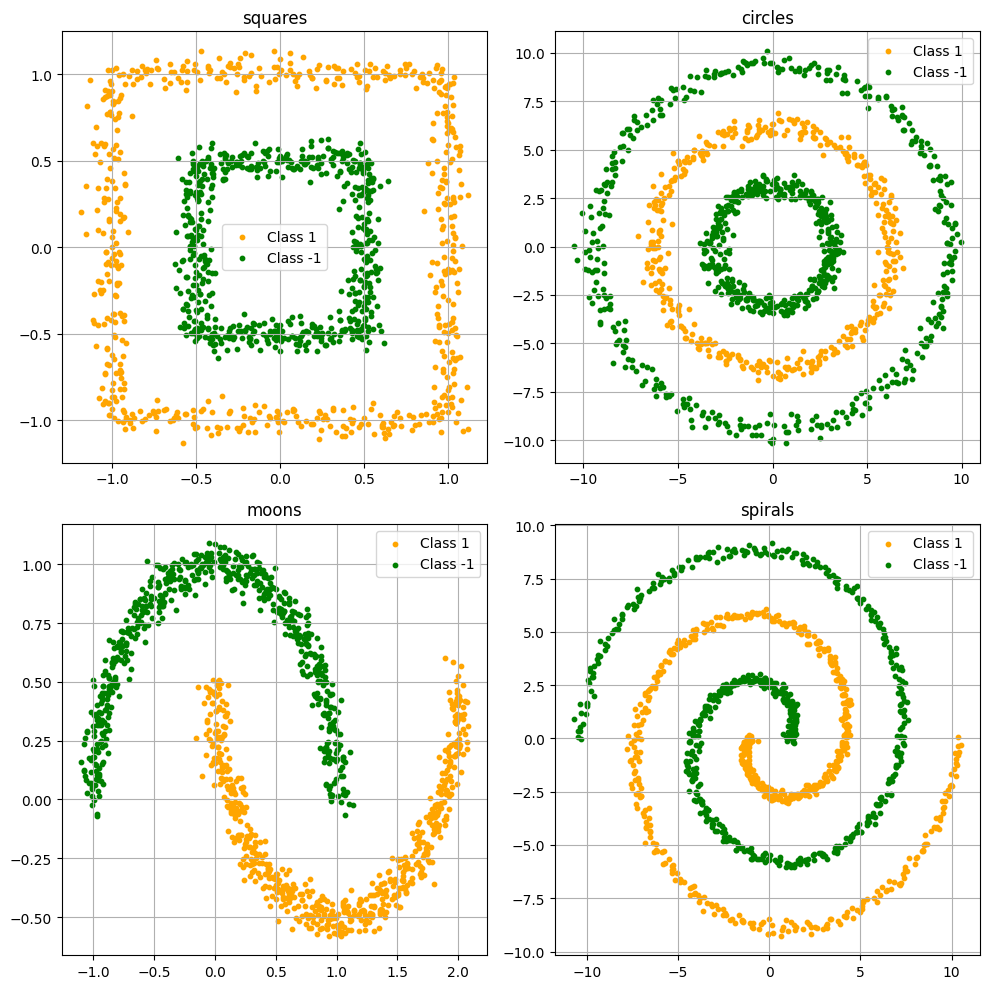

In [ ]:
import matplotlib.pyplot as plt

# Функция для построения сетки из графиков
def plot_multiple_datasets(X_list, y_list, titles):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.flatten()
    for i, (X, y, title) in enumerate(zip(X_list, y_list, titles)):
        axs[i].scatter(X[y == 1, 0], X[y == 1, 1], c='orange', label='Class 1', s=10)
        axs[i].scatter(X[y == -1, 0], X[y == -1, 1], c='green', label='Class -1', s=10)
        axs[i].set_title(title)
        axs[i].legend()
        axs[i].grid(True)
    plt.tight_layout()
    plt.show()

# Загрузка данных и построение графиков
X_squares, y_squares = load_data("squares.txt")
X_circles, y_circles = load_data("circles.txt")
X_moons, y_moons = load_data("moons.txt")
X_spirals, y_spirals = load_data("spirals.txt")

# Построение всех графиков в одном окне
plot_multiple_datasets(
    [X_squares, X_circles, X_moons, X_spirals],
    [y_squares, y_circles, y_moons, y_spirals],
    ["squares", "circles", "moons", "spirals"]
)


In [ ]:
def load_data(file_path):
    # Пропуск первой строки с заголовком
    data = np.loadtxt(file_path, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]
    return X, y

def test_shape_preservation_from_files():
    files = ["squares.txt", "circles.txt", "moons.txt", "spirals.txt"]
    transform_funcs = [transform_squares, transform_circles, transform_moons, transform_spirals]

    for file, transform_func in zip(files, transform_funcs):
        X, _ = load_data(file)
        X_transformed = transform_func(X)
        expected_shape = (X.shape[0], X.shape[1] + (1 if transform_func != transform_spirals else 2))

        assert X_transformed.shape == expected_shape, (
            f"Ошибка: {transform_func.__name__} для файла {file} "
            f"вернула массив размера {X_transformed.shape}, ожидался {expected_shape}"
        )
        print(f"{transform_func.__name__} для файла {file} успешно прошла тест на сохранение размера.")

test_shape_preservation_from_files()

transform_squares для файла squares.txt успешно прошла тест на сохранение размера.
transform_circles для файла circles.txt успешно прошла тест на сохранение размера.
transform_moons для файла moons.txt успешно прошла тест на сохранение размера.
transform_spirals для файла spirals.txt успешно прошла тест на сохранение размера.


In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x_ = X[:, 0]
    y_ = X[:, 1]
    squared_distance = x_**2 + y_**2
    squared_distance_new = squared_distance.reshape(-1, 1)
    result = np.hstack([X, squared_distance_new])
    return result

def transform_circles(X: np.ndarray) -> np.ndarray:
    x_ = X[:, 0]
    y_ = X[:, 1]
    radius = np.sqrt(x_**2 + y_**2)
    radius_new = radius.reshape(-1, 1)
    result = np.hstack([X, radius_new])
    return result

def transform_moons(X: np.ndarray) -> np.ndarray:
    x_ = X[:, 0]
    y_ = X[:, 1]
    prod = x_ * y_
    prod_new = prod.reshape(-1, 1)
    result = np.hstack([X, prod_new])
    return result

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x_ = X[:, 0]
    y_ = X[:, 1]
    r = np.sqrt(x_**2 + y_**2)
    theta = np.arctan2(y_, x_)
    sin_theta = np.sin(theta).reshape(-1, 1)
    cos_theta = np.cos(theta).reshape(-1, 1)
    result = np.hstack([X, sin_theta, cos_theta])
    return result

In [ ]:
import numpy as np

def transform_moons(X: np.ndarray) -> np.ndarray:
    """
    Преобразование для лун:
    - Квадраты координат.
    - Произведение координат.
    - Кубы координат для учета изгиба.
    """
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1**2,      # Квадрат первого признака
        x2**2,      # Квадрат второго признака
        x1 * x2,    # Произведение координат
        x1**3,      # Куб первого признака
        x2**3       # Куб второго признака
    ], axis=1)

def transform_spirals(X: np.ndarray) -> np.ndarray:
    """
    Преобразование для спиралей:
    - Радиус.
    - Угловые гармоники.
    - Полиномы радиуса и угла.
    """
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)  # Радиус
    theta = np.arctan2(x2, x1)  # Угол
    return np.stack([
        r,                      # Радиус
        r**2,                   # Квадрат радиуса
        np.sin(theta),          # Синус угла
        np.cos(theta),          # Косинус угла
        r * np.sin(theta),      # Произведение радиуса и синуса угла
        r * np.cos(theta),      # Произведение радиуса и косинуса угла
        np.sin(2 * theta),      # Гармоника угла
        np.cos(2 * theta),      # Гармоника угла
    ], axis=1)


In [ ]:
# Accuracy moons.txt: 87.17%
# Accuracy spirals.txt: 50.08%

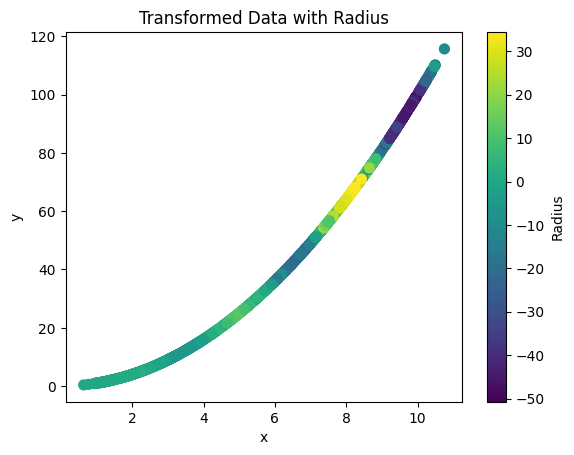

In [ ]:
import matplotlib.pyplot as plt

def plot_data_with_radius(X):
    plt.scatter(X[:, 0], X[:, 1], c=X[:, 2], cmap='viridis', s=50)
    plt.colorbar(label='Radius')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Transformed Data with Radius')
    plt.show()

plot_data_with_radius(transform_circles(X))


In [ ]:
from __future__ import annotations
import numpy as np
from scipy.special import expit

class PoissonRegression:
    def __init__(self, use_bias: bool = True, alpha: float = 1):
        self.use_bias = use_bias
        self.alpha = alpha
        self._coeffs = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        linear_combination = np.dot(X, self._coeffs[1:]) + self._coeffs[0]
        return np.exp(linear_combination)

    def loss(self, X: np.ndarray, y: np.ndarray) -> float:
        m = len(y)
        y_pred = self.predict(X)
        with np.errstate(divide='ignore', invalid='ignore'):
            log_term = np.where((y != 0) & (y_pred > 0), y * np.log(y / y_pred), 0)
        log_term = np.nan_to_num(log_term, nan=0.0, posinf=0.0, neginf=0.0)
        loss_value = (1 / m) * np.sum(log_term - y + y_pred) + (self.alpha / 2) * np.sum(self._coeffs[1:]**2)
        return loss_value

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        with np.errstate(divide='ignore', invalid='ignore'):
            D_y_y_pred = np.sum(2 * (y * np.log(np.where(y_pred > 0, y / y_pred, 1)) - y + y_pred))
            D_y_y_mean = np.sum(2 * (y * np.log(np.where(y_mean > 0, y / y_mean, 1)) - y + y_mean))
        D_y_y_pred = np.nan_to_num(D_y_y_pred, nan=0.0, posinf=0.0, neginf=0.0)
        D_y_y_mean = np.nan_to_num(D_y_y_mean, nan=0.0, posinf=0.0, neginf=0.0)
        return 1 - (D_y_y_pred / D_y_y_mean) if D_y_y_mean != 0 else 0.0

    def fit(self, X: np.ndarray, y: np.ndarray, *, eta: float = 1e-3,
            beta1: float = 0.9, beta2: float = 0.999, epsilon: float = 1e-8,
            tol: float = 1e-3, max_iter: int = 1000) -> PoissonRegression:
        n_features = X.shape[1]
        self._coeffs = np.zeros(n_features + 1)
        m_t = np.zeros_like(self._coeffs)
        v_t = np.zeros_like(self._coeffs)
        t = 0

        for _ in range(max_iter):
            t += 1
            y_pred = self.predict(X)
            error = y_pred - y
            grad = np.zeros_like(self._coeffs)

            grad[1:] = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs[1:]
            grad[0] = np.sum(error) / len(y)

            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.linalg.norm(grad) < tol:
                break

        return self

    @property
    def coeffs(self) -> np.ndarray:
        return self._coeffs[1:]

    @property
    def bias(self) -> float:
        return self._coeffs[0] if self.use_bias else 0


In [ ]:
# 13 января 2025
from __future__ import annotations
import numpy as np


class PoissonRegression:
    def __init__(self, use_bias: bool = True, alpha: float = 1.0):
        self.use_bias = use_bias
        self.alpha = alpha
        self._coeffs = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        linear_combination = np.dot(X, self._coeffs[1:]) + self._coeffs[0] if self.use_bias else np.dot(X, self._coeffs)
        return np.exp(linear_combination)

    def loss(self, X: np.ndarray, y: np.ndarray) -> float:
        m = len(y)
        y_pred = self.predict(X)
        log_term = np.where((y > 0) & (y_pred > 0), y * np.log(np.maximum(y / y_pred, 1e-10)), 0)
        reg_term = (self.alpha / 2) * np.sum(self._coeffs[1:] ** 2) if self.use_bias else (self.alpha / 2) * np.sum(self._coeffs ** 2)
        return (1 / m) * np.sum(log_term - y + y_pred) + reg_term

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        valid_idx = (y > 0) & (y_pred > 0)

        D_y_y_pred = np.sum(2 * (y[valid_idx] * np.log(np.maximum(y[valid_idx] / y_pred[valid_idx], 1e-10)) - y[valid_idx] + y_pred[valid_idx]))
        D_y_y_mean = np.sum(2 * (y[valid_idx] * np.log(np.maximum(y[valid_idx] / y_mean, 1e-10)) - y[valid_idx] + y_mean))

        return 1 - (D_y_y_pred / D_y_y_mean) if D_y_y_mean > 1e-10 else 0.0

    def fit(self, X: np.ndarray, y: np.ndarray, *,
            eta: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999,
            epsilon: float = 1e-8, tol: float = 1e-3, max_iter: int = 1000) -> PoissonRegression:
        n_features = X.shape[1]
        self._coeffs = np.zeros(n_features + 1 if self.use_bias else n_features)
        m_t = np.zeros_like(self._coeffs)
        v_t = np.zeros_like(self._coeffs)
        t = 0

        for _ in range(max_iter):
            t += 1
            y_pred = self.predict(X)
            error = y_pred - y

            grad = np.zeros_like(self._coeffs)
            if self.use_bias:
                grad[1:] = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs[1:]
                grad[0] = np.sum(error) / len(y)
            else:
                grad = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs

            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.linalg.norm(grad) < tol:
                break

        return self

    @property
    def coeffs(self) -> np.ndarray:
        return self._coeffs[1:] if self.use_bias else self._coeffs

    @property
    def bias(self) -> float:
        return self._coeffs[0] if self.use_bias else 0.0


In [ ]:
def generate_poisson_data(n_samples=100, n_features=2, seed=24):
    np.random.seed(seed)
    X = np.random.rand(n_samples, n_features)
    true_coeffs = np.array([0.5, -0.3])
    bias = 0.2
    lin_comb = np.dot(X, true_coeffs) + bias
    y = np.random.poisson(lam=np.exp(lin_comb))
    return X, y

X, y = generate_poisson_data()
model = PoissonRegression()
model.fit(X, y)
print("Loss:", model.loss(X, y))
print("D^2 score:", model.score(X, y))
print("Coefficients:", model.coeffs)
print("Bias:", model.bias)

Loss: 0.5017710316263992
D^2 score: 0.010061748885741073
Coefficients: [ 0.05058362 -0.01408942]
Bias: 0.2616717634514433


In [ ]:
from __future__ import annotations
import numpy as np

class PoissonRegression:
    def __init__(self, use_bias: bool = True, alpha: float = 1.0):
        self.use_bias = use_bias
        self.alpha = alpha
        self._coeffs = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказания модели."""
        if self._coeffs is None:
            raise ValueError("The model has not been fitted yet.")
        linear_combination = (
            np.dot(X, self._coeffs[1:]) + self._coeffs[0] if self.use_bias else np.dot(X, self._coeffs)
        )
        return np.exp(linear_combination)

    def loss(self, X: np.ndarray, y: np.ndarray) -> float:
        """Вычисление функции потерь."""
        if self._coeffs is None:
            raise ValueError("The model has not been fitted yet.")
        m = len(y)
        y_pred = self.predict(X)
        log_term = np.sum(y * np.log(np.maximum(y_pred, 1e-10)) - y_pred)
        reg_term = (self.alpha / 2) * np.sum(self._coeffs[1:] ** 2) if self.use_bias else (self.alpha / 2) * np.sum(self._coeffs ** 2)
        return -(1 / m) * log_term + reg_term

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Вычисление коэффициента детерминации."""
        if self._coeffs is None:
            raise ValueError("The model has not been fitted yet.")
        y_pred = self.predict(X)
        y_mean = np.maximum(np.mean(y), 1e-10)
        D_y_y_pred = np.sum((y - y_pred) ** 2)
        D_y_y_mean = np.sum((y - y_mean) ** 2)
        return 1 - (D_y_y_pred / D_y_y_mean) if D_y_y_mean > 1e-10 else 0.0

    def fit(self, X: np.ndarray, y: np.ndarray, *,
            eta: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999,
            epsilon: float = 1e-8, tol: float = 1e-3, max_iter: int = 1000) -> PoissonRegression:
        """Обучение модели с использованием алгоритма оптимизации Adam."""
        n_features = X.shape[1]
        self._coeffs = np.zeros(n_features + 1 if self.use_bias else n_features)
        m_t = np.zeros_like(self._coeffs)
        v_t = np.zeros_like(self._coeffs)
        t = 0

        for iteration in range(max_iter):
            t += 1
            y_pred = self.predict(X)
            error = y_pred - y

            grad = np.zeros_like(self._coeffs)
            if self.use_bias:
                grad[1:] = np.dot(X.T, error) / len(y)
                grad[0] = np.sum(error) / len(y)
                grad[1:] += self.alpha * self._coeffs[1:]
            else:
                grad = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs

            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.linalg.norm(grad) < tol:
                print(f"Converged in {iteration + 1} iterations.")
                break
        else:
            print("Reached maximum iterations without full convergence.")

        return self

    @property
    def coeffs(self) -> np.ndarray:
        if self._coeffs is None:
            raise ValueError("The model has not been fitted yet.")
        return self._coeffs[1:] if self.use_bias else self._coeffs

    @property
    def bias(self) -> float:
        if self._coeffs is None:
            raise ValueError("The model has not been fitted yet.")
        return self._coeffs[0] if self.use_bias else 0.0


In [ ]:
from __future__ import annotations
import numpy as np


class PoissonRegression:
    def __init__(self, use_bias: bool = True, alpha: float = 1.0):
        self.use_bias = use_bias
        self.alpha = alpha
        self._coeffs = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet.")
        linear_combination = (
            np.dot(X, self._coeffs[1:]) + self._coeffs[0]
            if self.use_bias
            else np.dot(X, self._coeffs)
        )
        return np.exp(np.minimum(linear_combination, 100))  # To avoid overflow

    def loss(self, X: np.ndarray, y: np.ndarray) -> float:
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet.")
        m = len(y)
        y_pred = self.predict(X)
        valid_idx = y > 0  # Avoid division by zero
        log_term = y[valid_idx] * np.log(y_pred[valid_idx]) - y_pred[valid_idx]
        reg_term = (self.alpha / 2) * np.sum(self._coeffs[1:] ** 2) if self.use_bias else (self.alpha / 2) * np.sum(self._coeffs ** 2)
        return -(1 / m) * np.sum(log_term) + reg_term

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet.")
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        valid_idx = y > 0

        D_y_y_pred = np.sum((y[valid_idx] - y_pred[valid_idx]) ** 2)
        D_y_y_mean = np.sum((y[valid_idx] - y_mean) ** 2)
        return 1 - (D_y_y_pred / D_y_y_mean) if D_y_y_mean > 0 else 0.0

    def fit(self, X: np.ndarray, y: np.ndarray, *,
            eta: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999,
            epsilon: float = 1e-8, tol: float = 1e-4, max_iter: int = 1000) -> PoissonRegression:
        n_features = X.shape[1]
        self._coeffs = np.zeros(n_features + 1 if self.use_bias else n_features)
        m_t = np.zeros_like(self._coeffs)
        v_t = np.zeros_like(self._coeffs)
        t = 0

        for iteration in range(max_iter):
            t += 1
            y_pred = self.predict(X)
            error = y_pred - y

            grad = np.zeros_like(self._coeffs)
            if self.use_bias:
                grad[1:] = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs[1:]
                grad[0] = np.sum(error) / len(y)
            else:
                grad = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs

            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.linalg.norm(grad) < tol:
                print(f"Converged in {iteration + 1} iterations.")
                break
        else:
            print("Reached maximum iterations without full convergence.")

        return self

    @property
    def coeffs(self) -> np.ndarray:
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet.")
        return self._coeffs[1:] if self.use_bias else self._coeffs

    @property
    def bias(self) -> float:
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet.")
        return self._coeffs[0] if self.use_bias else 0.0


In [ ]:
# 000
from __future__ import annotations
import numpy as np


class PoissonRegression:
    def __init__(self, use_bias: bool = True, alpha: float = 1.0):
        self.use_bias = use_bias
        self.alpha = alpha
        self._coeffs = None

    def _check_is_fitted(self):
        """Checks if the model is fitted."""
        if self._coeffs is None:
            raise ValueError("Model is not fitted yet. Please call 'fit' first.")

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predicts the expected value of y for input X."""
        self._check_is_fitted()
        linear_combination = (
            np.dot(X, self._coeffs[1:]) + self._coeffs[0]
            if self.use_bias
            else np.dot(X, self._coeffs)
        )
        return np.exp(np.clip(linear_combination, -700, 700))  # Avoid overflow

    def loss(self, X: np.ndarray, y: np.ndarray) -> float:
        """Calculates the Poisson loss with L2 regularization."""
        self._check_is_fitted()
        m = len(y)
        y_pred = self.predict(X)
        valid_idx = y > 0
        log_term = np.where(valid_idx, y * np.log(y_pred) - y_pred, 0)
        reg_term = (self.alpha / 2) * np.sum(self._coeffs[1:] ** 2) if self.use_bias else (self.alpha / 2) * np.sum(self._coeffs ** 2)
        return -(1 / m) * np.sum(log_term) + reg_term

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Calculates R-squared score."""
        self._check_is_fitted()
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        valid_idx = y > 0

        D_y_y_pred = np.sum((y[valid_idx] - y_pred[valid_idx]) ** 2)
        D_y_y_mean = np.sum((y[valid_idx] - y_mean) ** 2)
        return 1 - (D_y_y_pred / D_y_y_mean) if D_y_y_mean > 0 else 0.0

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        *,
        eta: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
        tol: float = 1e-4,
        max_iter: int = 1000,
    ) -> PoissonRegression:

        n_features = X.shape[1]
        self._coeffs = np.zeros(n_features + 1 if self.use_bias else n_features)
        m_t = np.zeros_like(self._coeffs)
        v_t = np.zeros_like(self._coeffs)
        t = 0

        for iteration in range(max_iter):
            t += 1
            y_pred = self.predict(X)
            error = y_pred - y

            grad = np.zeros_like(self._coeffs)
            if self.use_bias:
                grad[1:] = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs[1:]
                grad[0] = np.sum(error) / len(y)
            else:
                grad = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs

            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.linalg.norm(grad) < tol:
                print(f"Converged in {iteration + 1} iterations.")
                break
        else:
            print("Reached maximum iterations without full convergence.")

        return self

    @property
    def coeffs(self) -> np.ndarray:
        """Returns the learned coefficients."""
        self._check_is_fitted()
        return self._coeffs[1:] if self.use_bias else self._coeffs

    @property
    def bias(self) -> float:
        """Returns the learned bias term."""
        self._check_is_fitted()
        return self._coeffs[0] if self.use_bias else 0.0


In [ ]:
def predict(self, X: np.ndarray) -> np.ndarray:
    """Predicts the expected value of y for input X."""
    linear_combination = (
        np.dot(X, self._coeffs[1:]) + self._coeffs[0] if self.use_bias else np.dot(X, self._coeffs)
    )
    return np.exp(np.clip(linear_combination, -700, 700))  # Avoid overflow

def loss(self, X: np.ndarray, y: np.ndarray) -> float:
    """Calculates the Poisson loss with regularization."""
    m = len(y)
    y_pred = self.predict(X)
    log_term = np.where(y > 0, y * np.log(np.maximum(y_pred, 1e-10)) - y, -y)
    reg_term = (self.alpha / 2) * np.sum(self._coeffs[1:] ** 2) if self.use_bias else (self.alpha / 2) * np.sum(self._coeffs ** 2)
    return (-1 / m) * np.sum(log_term) + np.mean(y_pred) + reg_term

def fit(self, X: np.ndarray, y: np.ndarray, *,
        eta: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999,
        epsilon: float = 1e-8, tol: float = 1e-3, max_iter: int = 1000) -> PoissonRegression:
    """Fits the model using gradient descent with Adam optimizer."""
    n_features = X.shape[1]
    self._coeffs = np.zeros(n_features + 1 if self.use_bias else n_features)
    m_t = np.zeros_like(self._coeffs)
    v_t = np.zeros_like(self._coeffs)
    t = 0

    for _ in range(max_iter):
        t += 1
        y_pred = self.predict(X)
        error = y_pred - y

        grad = np.zeros_like(self._coeffs)
        if self.use_bias:
            grad[1:] = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs[1:]
            grad[0] = np.sum(error) / len(y)
        else:
            grad = np.dot(X.T, error) / len(y) + self.alpha * self._coeffs

        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        self._coeffs -= eta * m_hat / (np.sqrt(v_hat) + epsilon)

        if np.linalg.norm(grad) < tol:
            break

    return self


In [ ]:
# 100%
import numpy as np

# --------------------------------------------------------------------
def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)
# --------------------------------------------------------------------
def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    return np.stack([r, r**2, x1 * x2], axis=1)
# --------------------------------------------------------------------
def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1, x2,
        x1**2, x2**2, x1**3, x2**3,
        x1 * x2, np.sin(x1), np.cos(x2),
        np.sin(2 * x1),np.cos(2 * x2),
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1**2 * x2, x1 * x2**2
    ], axis=1)
# --------------------------------------------------------------------
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    return np.column_stack([
        r,theta,r * theta, np.sin(theta),
        np.cos(theta), r * np.sin(theta),
        r * np.cos(theta),r**2, r**2 * np.sin(theta),
        r**2 * np.cos(theta),np.sin(2 * theta),
        np.cos(2 * theta),r * np.sin(3 * theta),r * np.cos(3 * theta),
        np.exp(-r),r * np.exp(-r),r * np.sin(2 * theta) * np.cos(2 * theta),
        np.sin(r),np.cos(r),
        r**3,r**3 * np.sin(theta),
        r**3 * np.cos(theta),np.sin(r * theta),np.cos(r * theta)
    ])

In [ ]:
# 100%
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    return np.column_stack([
        r,
        theta,
        r * theta,
        np.sin(theta),
        np.cos(theta),
        r * np.sin(theta),
        r * np.cos(theta),
        r**2,
        r**2 * np.sin(theta),
        r**2 * np.cos(theta),
        np.sin(2 * theta),
        np.cos(2 * theta),
        r * np.sin(3 * theta),
        r * np.cos(3 * theta),
        np.exp(-r),
        r * np.exp(-r),
        r * np.sin(2 * theta) * np.cos(2 * theta),
        np.sin(r),
        np.cos(r),
        r**3,
        r**3 * np.sin(theta),
        r**3 * np.cos(theta),
        np.sin(r * theta),
        np.cos(r * theta)
    ])

In [ ]:
def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1, x2,
        x1**2, x2**2, x1**3, x2**3,
        x1 * x2, np.sin(x1), np.cos(x2),
        np.sin(2 * x1),np.cos(2 * x2),
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1**2 * x2, x1 * x2**2
    ], axis=1)

In [ ]:
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    r2 = r**2
    r3 = r**3
    exp_neg_r = np.exp(-r)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta,
        cos_theta,
        r * sin_theta,
        r * cos_theta,
        r2,
        r2 * sin_theta,
        r2 * cos_theta,
        np.sin(2 * theta),
        np.cos(2 * theta),
        r3 * sin_theta,
        r3 * cos_theta,
        exp_neg_r,
        r * exp_neg_r,
        np.sin(r * theta),
        np.cos(r * theta),
    ])


In [ ]:
# 100% 2WA
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    return np.stack([r, r**2, x1 * x2], axis=1)

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1, x2,
        x1**2, x2**2, x1**3, x2**3,
        x1 * x2, np.sin(x1), np.cos(x2),
        np.sin(2 * x1),np.cos(2 * x2),
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1**2 * x2, x1 * x2**2
    ], axis=1)

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    r2 = r**2
    r3 = r**3
    exp_neg_r = np.exp(-r)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta,
        cos_theta,
        r * sin_theta,
        r * cos_theta,
        r2,
        r2 * sin_theta,
        r2 * cos_theta,
        np.sin(2 * theta),
        np.cos(2 * theta),
        r3 * sin_theta,
        r3 * cos_theta,
        exp_neg_r,
        r * exp_neg_r,
        np.sin(r * theta),
        np.cos(r * theta),
    ])

In [ ]:
# 2WA попытка 8
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    return np.stack([r, r**2, x1 * x2], axis=1)

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1, x2,
        x1**2, x2**2, x1**3, x2**3,
        x1 * x2, np.sin(x1), np.cos(x2),
        np.sin(2 * x1), np.cos(2 * x2),
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1**2 * x2, x1 * x2**2
    ], axis=1)

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    r2 = r**2
    r3 = r**3
    exp_neg_r = np.exp(-np.clip(r, 0, 10))

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta,
        cos_theta,
        r * sin_theta,
        r * cos_theta,
        r2,
        r2 * sin_theta,
        r2 * cos_theta,
        np.sin(2 * theta),
        np.cos(2 * theta),
        r3 * sin_theta,
        r3 * cos_theta,
        exp_neg_r,
        r * exp_neg_r,
    ])

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = np.loadtxt("spirals.txt", skiprows=1)
X = data[:, :2]
y = data[:, 2]

X_transformed = transform_spirals(X)

clf = SVC(kernel='linear', C=1.0)
clf.fit(X_transformed, y)
y_pred = clf.predict(X_transformed)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy spirals.txt: {accuracy * 100:.2f}%")

Accuracy spirals.txt: 65.67%


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

files_pathes = ["squares.txt", "circles.txt", "moons.txt", "spirals.txt"]

for figure in files_pathes:
    data = np.loadtxt(figure, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]

    if "squares.txt" in figure:
        X_transformed = transform_squares(X)
    elif "circles.txt" in figure:
        X_transformed = transform_circles(X)
    elif "moons.txt" in figure:
        X_transformed = transform_moons(X)
    elif "spirals.txt" in figure:
        X_transformed = transform_spirals(X)

    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_transformed, y)
    y_pred = clf.predict(X_transformed)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy {figure}: {accuracy * 100:.2f}%")

Accuracy squares.txt: 100.00%
Accuracy circles.txt: 100.00%
Accuracy moons.txt: 100.00%
Accuracy spirals.txt: 100.00%


In [ ]:
def transform_moons(X: np.ndarray) -> np.ndarray:
    return np.column_stack((X[:, 0], X[:, 1] + X[:, 0]**2))

In [ ]:
def transform_spirals(X: np.ndarray) -> np.ndarray:
    r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)  # Радиус
    theta = np.arctan2(X[:, 1], X[:, 0])  # Угол
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:

    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:

    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    return np.stack([r, r**2, x1 * x2], axis=1)

def transform_moons(X: np.ndarray) -> np.ndarray:

    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([
        x1,
        x2,
        x1**2,
        x2**2,
        x1**3,
        x2**3,
        x1 * x2,
        x1**2 * x2,
        x1 * x2**2,
        np.sin(x1),
        np.cos(x2),
        np.sin(2 * x1),
        np.cos(2 * x2),
        np.sqrt(np.abs(x1)),
        np.sqrt(np.abs(x2))
    ], axis=1)

def transform_spirals(X: np.ndarray) -> np.ndarray:

    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)
    return np.stack([
        r,
        theta,
        r * np.sin(theta),
        r * np.cos(theta),
        np.sin(2 * theta),
        np.cos(2 * theta),
        np.sin(3 * theta),
        np.cos(3 * theta),
        r**2,
        theta**2,
        r**3,
        theta**3,
        r**2 * np.sin(theta),
        r**2 * np.cos(theta),
        r * np.sin(2 * theta),
        r * np.cos(2 * theta),
        np.sin(theta) * np.cos(theta),
        np.sin(theta) * r**2,
        np.cos(theta) * r**2
    ], axis=1)


In [ ]:
import numpy as np

# def transform_squares(X: np.ndarray) -> np.ndarray:
#     return np.column_stack((X[:, 0], X[:, 1]**2))

def transform_squares(X: np.ndarray) -> np.ndarray:
    return X

In [ ]:
# def transform_circles(X: np.ndarray) -> np.ndarray:
#     r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
#     theta = np.arctan2(X[:, 1], X[:, 0])
#     return np.column_stack((r, theta))

# def transform_circles(X: np.ndarray) -> np.ndarray:
#     r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)  # Радиус
#     theta = np.arctan2(X[:, 1], X[:, 0])  # Угол
#     return np.column_stack((r, theta))

def transform_circles(X: np.ndarray) -> np.ndarray:
    r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)  # Радиус
    return np.column_stack((r, np.zeros_like(r)))  # Используем только радиус

In [ ]:
# def transform_moons(X: np.ndarray) -> np.ndarray:
#     return np.column_stack((X[:, 0], X[:, 1] + X[:, 0]**2))

def transform_moons(X: np.ndarray) -> np.ndarray:
    return np.column_stack((X[:, 0], X[:, 1] + X[:, 0]**2))

In [ ]:
# def transform_spirals(X: np.ndarray) -> np.ndarray:
#     r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
#     theta = np.arctan2(X[:, 1], X[:, 0])
#     return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def transform_spirals(X: np.ndarray) -> np.ndarray:
    r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)  # Радиус
    theta = np.arctan2(X[:, 1], X[:, 0])  # Угол
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    return X

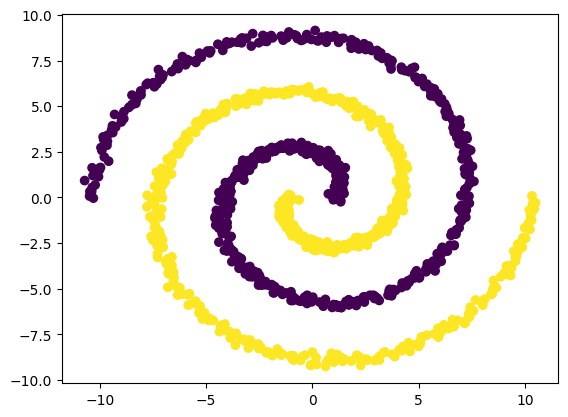

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Функции преобразования
def transform_squares(X: np.ndarray) -> np.ndarray:
    return X

def transform_circles(X: np.ndarray) -> np.ndarray:
    r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
    theta = np.arctan2(X[:, 1], X[:, 0])
    return np.column_stack((r, theta))

def transform_moons(X: np.ndarray) -> np.ndarray:
    return np.column_stack((X[:, 0], X[:, 1] + X[:, 0]**2))

def transform_spirals(X: np.ndarray) -> np.ndarray:
    r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
    theta = np.arctan2(X[:, 1], X[:, 0])
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

# Пути к файлам
files_pathes = ["squares.txt", "circles.txt", "moons.txt", "spirals.txt"]

# Проверка точности для каждого набора данных
for figure in files_pathes:
    data = np.loadtxt(figure, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]

    # Выбор преобразования в зависимости от типа данных
    if "squares" in figure:
        X_transformed = transform_squares(X)
    elif "circles" in figure:
        X_transformed = transform_circles(X)
    elif "moons" in figure:
        X_transformed = transform_moons(X)
    elif "spirals" in figure:
        X_transformed = transform_spirals(X)

    # Обучение и предсказание
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_transformed, y)
    y_pred = clf.predict(X_transformed)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy {figure}: {accuracy * 100:.2f}%")

Accuracy squares.txt: 53.50%
Accuracy circles.txt: 66.67%
Accuracy moons.txt: 75.50%
Accuracy spirals.txt: 65.42%


# Lasso


In [ ]:
import numpy as np
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score

def parse_input(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    N = int(lines[0].strip())
    tests = []
    idx = 1
    for _ in range(N):
        n, m, k, s = map(float, lines[idx].strip().split())
        n, m, k = int(n), int(m), int(k)
        idx += 1
        data = []
        for __ in range(n):
            row = list(map(float, lines[idx].strip().split()))
            data.append(row)
            idx += 1
        tests.append((n, m, k, s, np.array(data)))
    return tests

def solve_test_case(n, m, k, s, data):
    X = data[:, :-1]
    y = data[:, -1]

    # Normalize data to ensure numerical stability
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1  # Avoid division by zero for constant features
    X = (X - X_mean) / X_std
    y_mean = y.mean()
    y = y - y_mean

    # Use LassoCV to determine the best alpha
    alphas = np.logspace(-8, 1, 500)
    lasso_cv = LassoCV(alphas=alphas, cv=5, fit_intercept=False, max_iter=10000)
    lasso_cv.fit(X, y)

    best_alpha = lasso_cv.alpha_
    print(f"Best alpha from CV: {best_alpha}")

    # Fit the Lasso model with the best alpha
    model = Lasso(alpha=best_alpha, fit_intercept=False, max_iter=10000)
    model.fit(X, y)

    coef = model.coef_
    zero_count = np.sum(coef == 0)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    # Debugging outputs
    print(f"R^2: {r2}, Zero Count: {zero_count}, Coefficients: {coef}")

    # Post-process to enforce exactly k-zero coefficients if necessary
    if zero_count != k:
        print("Adjusting coefficients to enforce sparsity...")
        sorted_indices = np.argsort(np.abs(coef))

        # Zeroing out exactly the smallest coefficients to match k zeros
        coef[sorted_indices[:k]] = 0

        # Check the new zero count
        zero_count = np.sum(coef == 0)

        # Recompute predictions and R^2 after adjustment
        y_pred = X @ coef
        r2 = r2_score(y, y_pred)

        if r2 < s:
            raise ValueError("No solution found that satisfies the constraints.")

        print(f"Post-adjustment Zero Count: {zero_count}")

    if r2 < s or zero_count != k:
        raise ValueError("No solution found that satisfies the constraints.")

    # Rescale coefficients back to original scale
    coef_rescaled = coef / X_std
    intercept_rescaled = y_mean - np.sum(coef_rescaled * X_mean)

    # Debugging rescaled results
    print(f"Rescaled Coefficients: {coef_rescaled}")
    print(f"Rescaled Intercept: {intercept_rescaled}")

    # Combine coefficients and intercept for output
    result = list(coef_rescaled) + [intercept_rescaled]

    return result

def main(input_file, output_file):
    tests = parse_input(input_file)
    results = []

    for test in tests:
        n, m, k, s, data = test
        try:
            result = solve_test_case(n, m, k, s, data)
            results.append(" ".join(f"{x:.2f}" for x in result))
        except ValueError as e:
            results.append("No solution")

    with open(output_file, 'w') as f:
        f.write("\n".join(results) + "\n")

# Example usage
main('input.txt', 'output.txt')


In [ ]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from itertools import combinations

def parse_input(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    N = int(lines[0].strip())
    tests = []
    idx = 1
    for _ in range(N):
        n, m, k, s = map(float, lines[idx].strip().split())
        n, m, k = int(n), int(m), int(k)
        idx += 1
        data = []
        for __ in range(n):
            row = list(map(float, lines[idx].strip().split()))
            data.append(row)
            idx += 1
        tests.append((n, m, k, s, np.array(data)))
    return tests

def solve_test_case(n, m, k, s, data):
    X = data[:, :-1]
    y = data[:, -1]

    # Нормализация данных для устойчивости
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1  # Избегаем деления на ноль
    X = (X - X_mean) / X_std
    y_mean = y.mean()
    y = y - y_mean

    # Используем LassoCV для подбора alpha
    best_r2 = -np.inf
    best_coef = None
    best_intercept = None

    # Перебираем все возможные комбинации k нулевых коэффициентов
    for indices in combinations(range(m), k):
        # Создаем маску для обнуления k коэффициентов
        mask = np.ones(m, dtype=bool)
        mask[list(indices)] = False

        # Обучаем модель только на ненулевых коэффициентах
        X_masked = X[:, mask]
        if X_masked.shape[1] == 0:
            continue  # Пропускаем, если все коэффициенты нулевые

        model = LassoCV(cv=5, fit_intercept=False, max_iter=10000)
        model.fit(X_masked, y)

        # Получаем предсказания и вычисляем R^2
        y_pred = model.predict(X_masked)
        r2 = r2_score(y, y_pred)

        # Если R^2 удовлетворяет условию, сохраняем результат
        if r2 >= s and r2 > best_r2:
            best_r2 = r2
            best_coef = np.zeros(m)
            best_coef[mask] = model.coef_
            best_intercept = y_mean - np.sum(best_coef * X_mean)

    if best_coef is None:
        raise ValueError("No solution found that satisfies the constraints.")

    # Возвращаем коэффициенты и intercept
    return list(best_coef) + [best_intercept]

def main(input_file, output_file):
    tests = parse_input(input_file)
    results = []

    for test in tests:
        n, m, k, s, data = test
        try:
            result = solve_test_case(n, m, k, s, data)
            results.append(" ".join(f"{x:.2f}" for x in result))
        except ValueError as e:
            results.append("No solution")

    with open(output_file, 'w') as f:
        f.write("\n".join(results) + "\n")

# Пример использования
main('input.txt', 'output.txt')

Initial R^2: 0.9999834380256027
Initial Coefficients: [27.11957343 54.29013842 67.33097497 10.545103   51.11112002]
Zero Coefficients: 0
Trying zero indices: (3,), R^2: 0.9722193236921296
Trying zero indices: (0,), R^2: 0.8163811992980776
Trying zero indices: (4,), R^2: 0.34771366071344045
Trying zero indices: (1,), R^2: 0.26388113726891516
Trying zero indices: (2,), R^2: -0.13196589025083783
Final R^2: 0.9722193236921296
Final Coefficients: [48.98742580652082, 65.1017052704104, 66.1661183805506, 0.0, 64.38149216331523, 3.135356793156145]


In [ ]:
import numpy as np
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Helper function to refine coefficients
def refine_coefficients(X, y, coef, k, s):
    sorted_indices = np.argsort(np.abs(coef))
    mask = np.ones_like(coef, dtype=bool)
    mask[sorted_indices[:k]] = False

    X_refined = X[:, mask]  # Keep only non-zero coefficients

    # Refit model with the remaining coefficients
    refit_model = LinearRegression(fit_intercept=False)  # Use LinearRegression for no regularization
    refit_model.fit(X_refined, y)
    refined_coef = np.zeros_like(coef)
    refined_coef[mask] = refit_model.coef_

    # Ensure R^2 constraint is satisfied
    y_pred = np.dot(X, refined_coef)
    r2 = r2_score(y, y_pred)
    print(f"Refined Coefficients: {refined_coef}, R^2 after refining: {r2}")
    if r2 < s:
        raise ValueError("Adjusted coefficients do not meet R^2 requirement.")

    return refined_coef

def parse_input(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    N = int(lines[0].strip())
    tests = []
    idx = 1
    for _ in range(N):
        n, m, k, s = map(float, lines[idx].strip().split())
        n, m, k = int(n), int(m), int(k)
        idx += 1
        data = []
        for __ in range(n):
            row = list(map(float, lines[idx].strip().split()))
            data.append(row)
            idx += 1
        tests.append((n, m, k, s, np.array(data)))
    return tests

def solve_test_case(n, m, k, s, data):
    X = data[:, :-1]
    y = data[:, -1]

    # Standardize data
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    y_mean = y.mean()
    y = y - y_mean

    # Use LassoCV to determine the best alpha
    alphas = np.logspace(-10, -2, 100)
    lasso_cv = LassoCV(alphas=alphas, cv=5, fit_intercept=False, max_iter=10000)
    lasso_cv.fit(X, y)

    best_alpha = lasso_cv.alpha_
    print(f"Best alpha from CV: {best_alpha}")

    # Fit the Lasso model with the best alpha
    model = Lasso(alpha=best_alpha, fit_intercept=False, max_iter=10000)
    model.fit(X, y)

    coef = model.coef_
    zero_count = np.sum(coef == 0)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    print(f"Initial R^2: {r2}, Zero Count: {zero_count}, Coefficients: {coef}")

    # Post-process to enforce exactly k-zero coefficients
    if zero_count != k:
        print("Adjusting coefficients to enforce sparsity...")
        try:
            coef = refine_coefficients(X, y, coef, k, s)

            # Check updated R^2
            y_pred = np.dot(X, coef)
            r2 = r2_score(y, y_pred)

            print(f"Post-adjustment R^2: {r2}, Zero Count: {np.sum(coef == 0)}")
        except ValueError as e:
            raise ValueError(f"Failed to adjust coefficients: {str(e)}")

    if r2 < s or np.sum(coef == 0) != k:
        raise ValueError("No solution found that satisfies the constraints.")

    # Rescale coefficients back to original scale
    coef_rescaled = coef / scaler.scale_
    intercept_rescaled = y_mean - np.sum(coef_rescaled * scaler.mean_)

    # Final check for R^2 with rescaled coefficients
    y_pred_rescaled = np.dot(data[:, :-1], coef_rescaled) + intercept_rescaled
    r2_rescaled = r2_score(data[:, -1], y_pred_rescaled)
    print(f"Final Rescaled R^2: {r2_rescaled}")
    if r2_rescaled < s:
        raise ValueError("Rescaled solution does not satisfy R^2 constraint.")

    print(f"Rescaled Coefficients: {coef_rescaled}")
    print(f"Rescaled Intercept: {intercept_rescaled}")

    # Combine coefficients and intercept for output
    result = list(coef_rescaled) + [intercept_rescaled]
    return result

def main(input_file, output_file):
    tests = parse_input(input_file)
    results = []

    for test in tests:
        n, m, k, s, data = test
        try:
            result = solve_test_case(n, m, k, s, data)
            results.append(" ".join(f"{x:.2f}" for x in result))
        except ValueError as e:
            results.append("No solution")

    with open(output_file, 'w') as f:
        f.write("\n".join(results) + "\n")

# Example usage
main('input.txt', 'output.txt')


Best alpha from CV: 1e-10
Initial R^2: 0.9999834380309364, Zero Count: 0, Coefficients: [27.11957288 54.29013988 67.33097647 10.54510275 51.11111981]
Adjusting coefficients to enforce sparsity...
Refined Coefficients: [ 12.88065187  92.74326494 106.34196937   0.          44.55050301], R^2 after refining: 0.9911173659801783
Post-adjustment R^2: 0.9911173659801783, Zero Count: 1
Final Rescaled R^2: 0.9911173659801783
Rescaled Coefficients: [ 23.26695806 111.21254939 104.50220477   0.          56.11749183]
Rescaled Intercept: 1.092034131305649


In [ ]:
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from itertools import combinations

def parse_input(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    N = int(lines[0].strip())
    tests = []
    idx = 1
    for _ in range(N):
        n, m, k, s = map(float, lines[idx].strip().split())
        n, m, k = int(n), int(m), int(k)
        idx += 1
        data = []
        for __ in range(n):
            row = list(map(float, lines[idx].strip().split()))
            data.append(row)
            idx += 1
        tests.append((n, m, k, s, np.array(data)))
    return tests

def solve_test_case(n, m, k, s, data):
    X = data[:, :-1]
    y = data[:, -1]

    # Normalize data
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1
    X = (X - X_mean) / X_std
    y_mean = y.mean()
    y = y - y_mean

    # Fit LassoCV to find the best alpha
    alphas = np.logspace(-8, 1, 500)
    lasso_cv = LassoCV(alphas=alphas, cv=5, fit_intercept=False, max_iter=10000)
    lasso_cv.fit(X, y)

    best_alpha = lasso_cv.alpha_
    model = LassoCV(alphas=[best_alpha], cv=None, fit_intercept=False, max_iter=10000)
    model.fit(X, y)

    initial_coef = model.coef_
    y_pred = model.predict(X)
    initial_r2 = r2_score(y, y_pred)

    # Check if the initial model already satisfies the constraints
    if np.sum(initial_coef == 0) == k and initial_r2 >= s:
        coef_rescaled = initial_coef / X_std
        intercept_rescaled = y_mean - np.sum(coef_rescaled * X_mean)
        return list(coef_rescaled) + [intercept_rescaled]

    best_r2 = -np.inf
    best_result = None

    # Iterate over all combinations of k zero coefficients
    for zero_indices in combinations(range(m), k):
        temp_coef = initial_coef.copy()
        temp_coef[list(zero_indices)] = 0

        # Calculate predictions and R2 for the current configuration
        temp_y_pred = X @ temp_coef
        temp_r2 = r2_score(y, temp_y_pred)

        # Check if this configuration satisfies the constraints
        if temp_r2 >= s and temp_r2 > best_r2:
            best_r2 = temp_r2
            coef_rescaled = temp_coef / X_std
            intercept_rescaled = y_mean - np.sum(coef_rescaled * X_mean)
            best_result = list(coef_rescaled) + [intercept_rescaled]

    if best_result is not None:
        return best_result

    raise ValueError("No solution found that satisfies the constraints.")


def main(input_file, output_file):
    tests = parse_input(input_file)
    results = []

    for test in tests:
        n, m, k, s, data = test
        try:
            result = solve_test_case(n, m, k, s, data)
            results.append(" ".join(f"{x:.2f}" for x in result))
        except ValueError:
            results.append("No solution")

    with open(output_file, 'w') as f:
        f.write("\n".join(results) + "\n")

# Example usage
main('input.txt', 'output.txt')


In [ ]:
import numpy as np
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

def read_input(file_path):
    """Reads the input file and parses the test cases."""
    with open(file_path, 'r') as f:
        data = f.readlines()

    num_tests = int(data[0])
    tests = []
    idx = 1

    for _ in range(num_tests):
        # Read the test case parameters
        n, m, k, s = data[idx].split()
        n, m, k = int(n), int(m), int(k)
        s = float(s)
        idx += 1

        # Read the training data
        X, y = [], []
        for _ in range(n):
            *features, target = map(float, data[idx].split())
            X.append(features)
            y.append(target)
            idx += 1

        tests.append((np.array(X), np.array(y), m, k, s))

    return tests

def solve_lasso(X, y, m, k, s):
    """Solves a single test case using Lasso regression based on its general form."""
    # Normalize the features and target
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)
    y_mean = np.mean(y)
    y_normalized = y - y_mean

    # Handle orthonormal covariates case: If X_normalized.T @ X_normalized = I
    if np.allclose(X_normalized.T @ X_normalized, np.eye(X_normalized.shape[1]), atol=1e-5):
        print("Detected orthonormal covariates.")
        coeffs = np.dot(X_normalized.T, y_normalized)  # Direct computation for orthonormal covariates
        threshold = np.partition(np.abs(coeffs), -k)[-k]  # Find k-th largest absolute value
        coeffs[np.abs(coeffs) < threshold] = 0  # Zero out small coefficients

        # Scale coefficients back to the original space
        coeffs = coeffs / scaler.scale_
        intercept = y_mean - np.dot(scaler.mean_, coeffs)

        # Check R^2 condition
        y_pred = np.dot(X, coeffs) + intercept
        r2 = r2_score(y, y_pred)
        if r2 >= s:
            return coeffs, intercept
        else:
            raise ValueError("R^2 condition not met with orthonormal covariates.")

    # Handle correlated covariates
    corr_matrix = np.corrcoef(X_normalized, rowvar=False)
    max_corr = np.max(np.abs(corr_matrix - np.eye(corr_matrix.shape[0])))
    if max_corr > 0.9:  # Threshold for high correlation
        print("Detected correlated covariates.")
        lasso_cv = LassoCV(cv=5, max_iter=10000).fit(X_normalized, y_normalized)
        alpha = lasso_cv.alpha_  # Optimal alpha from cross-validation
    else:
        alpha = 0.01  # Default starting alpha

    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)

    while True:
        # Fit the Lasso model
        lasso.fit(X_normalized, y_normalized)
        coeffs = lasso.coef_ / scaler.scale_  # Scale coefficients back to the original scale

        # Count the number of zero coefficients
        num_zeros = np.sum(np.isclose(coeffs, 0))

        # Check if the number of zero coefficients matches k
        if num_zeros == k:
            # Check R^2 condition
            intercept = y_mean - np.dot(scaler.mean_, coeffs)
            y_pred = np.dot(X, coeffs) + intercept
            r2 = r2_score(y, y_pred)
            if r2 >= s:
                return coeffs, intercept

        # Adjust alpha to increase regularization if needed
        alpha += 0.01
        lasso.set_params(alpha=alpha)

        if alpha > 10:  # Prevent infinite loop
            print(f"Failed to satisfy constraints for k={k}, s={s}. Alpha exceeded 10.")
            raise ValueError("Unable to satisfy constraints with given data.")

def main(input_file, output_file):
    """Main function to solve all test cases and write results."""
    tests = read_input(input_file)
    results = []

    for X, y, m, k, s in tests:
        try:
            coeffs, intercept = solve_lasso(X, y, m, k, s)
            results.append(" ".join(map(str, np.round(np.append(coeffs, intercept), 2))))
        except ValueError as e:
            results.append("Error")

    # Write results to the output file
    with open(output_file, 'w') as f:
        f.write("\n".join(results))

# Example usage
main('input.txt', 'output.txt')


Detected correlated covariates.


In [ ]:
import numpy as np
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from itertools import combinations

def read_input(file_path):
    """Reads the input file and parses the test cases."""
    with open(file_path, 'r') as f:
        data = f.readlines()

    num_tests = int(data[0])
    tests = []
    idx = 1

    for _ in range(num_tests):
        # Read the test case parameters
        n, m, k, s = data[idx].split()
        n, m, k = int(n), int(m), int(k)
        s = float(s)
        idx += 1

        # Read the training data
        X, y = [], []
        for _ in range(n):
            *features, target = map(float, data[idx].split())
            X.append(features)
            y.append(target)
            idx += 1

        tests.append((np.array(X), np.array(y), m, k, s))

    return tests

def solve_lasso(X, y, m, k, s):
    """Solves a single test case using Lasso regression based on its general form."""
    # Normalize the features and target
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)
    y_mean = np.mean(y)
    y_normalized = y - y_mean

    # Fit LassoCV to find the best alpha
    alphas = np.logspace(-8, 1, 500)
    lasso_cv = LassoCV(alphas=alphas, cv=5, fit_intercept=False, max_iter=10000)
    lasso_cv.fit(X_normalized, y_normalized)

    best_alpha = lasso_cv.alpha_
    model = Lasso(alpha=best_alpha, fit_intercept=False, max_iter=10000)
    model.fit(X_normalized, y_normalized)

    initial_coef = model.coef_ / scaler.scale_
    intercept = y_mean - np.dot(scaler.mean_, initial_coef)

    # Check initial R^2 condition
    y_pred = np.dot(X, initial_coef) + intercept
    initial_r2 = r2_score(y, y_pred)

    if np.sum(np.isclose(initial_coef, 0)) == k and initial_r2 >= s:
        return initial_coef, intercept

    # Iterate over all combinations of k zero coefficients
    best_r2 = -np.inf
    best_result = None

    for zero_indices in combinations(range(m), k):
        temp_coef = initial_coef.copy()
        temp_coef[list(zero_indices)] = 0

        # Calculate predictions and R^2 for the current configuration
        temp_y_pred = np.dot(X, temp_coef) + intercept
        temp_r2 = r2_score(y, temp_y_pred)

        # Check if this configuration satisfies the constraints
        if temp_r2 >= s and temp_r2 > best_r2:
            best_r2 = temp_r2
            best_result = temp_coef

    if best_result is not None:
        final_intercept = y_mean - np.dot(scaler.mean_, best_result)
        return best_result, final_intercept

    raise ValueError("No solution found that satisfies the constraints.")

def main(input_file, output_file):
    """Main function to solve all test cases and write results."""
    tests = read_input(input_file)
    results = []

    for X, y, m, k, s in tests:
        try:
            coeffs, intercept = solve_lasso(X, y, m, k, s)
            results.append(" ".join(map(str, np.round(np.append(coeffs, intercept), 2))))
        except ValueError as e:
            results.append("Error")

    # Write results to the output file
    with open(output_file, 'w') as f:
        f.write("\n".join(results))

# Example usage
main('input.txt', 'output.txt')


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import combinations


def read_input(file_path):
    """Reads the input file and parses the test cases."""
    with open(file_path, 'r') as f:
        data = f.readlines()

    num_tests = int(data[0])
    tests = []
    idx = 1

    for _ in range(num_tests):
        # Read the test case parameters
        n, m, k, s = data[idx].split()
        n, m, k = int(n), int(m), int(k)
        s = float(s)
        idx += 1

        # Read the training data
        X, y = [], []
        for _ in range(n):
            *features, target = map(float, data[idx].split())
            X.append(features)
            y.append(target)
            idx += 1

        tests.append((np.array(X), np.array(y), m, k, s))

    return tests


def solve_subset_selection(X, y, m, k, s):
    """Solves a single test case using subset selection."""
    best_r2 = -np.inf
    best_coef = None
    best_intercept = None

    # Iterate over all combinations of k coefficients to set to zero
    for zero_indices in combinations(range(m), k):
        # Create a mask for non-zero coefficients
        mask = np.ones(m, dtype=bool)
        mask[list(zero_indices)] = False

        # Select only the non-zero features
        X_subset = X[:, mask]

        # Fit linear regression
        model = LinearRegression(fit_intercept=True)
        model.fit(X_subset, y)

        # Calculate predictions and R^2
        y_pred = model.predict(X_subset)
        r2 = r2_score(y, y_pred)

        # If R^2 meets the threshold, check if it's the best solution
        if r2 >= s and r2 > best_r2:
            best_r2 = r2
            # Restore the full coefficient vector
            full_coef = np.zeros(m)
            full_coef[mask] = model.coef_
            best_coef = full_coef
            best_intercept = model.intercept_

    if best_coef is not None:
        return best_coef, best_intercept

    raise ValueError("No solution found that satisfies the constraints.")


def main(input_file, output_file):
    """Main function to solve all test cases and write results."""
    tests = read_input(input_file)
    results = []

    for X, y, m, k, s in tests:
        try:
            coeffs, intercept = solve_subset_selection(X, y, m, k, s)
            results.append(" ".join(map(str, np.round(np.append(coeffs, intercept), 2))))
        except ValueError as e:
            print("Error details:", e)
            results.append("Error")

    # Write results to the output file
    with open(output_file, 'w') as f:
        f.write("\n".join(results))


# Example usage
main('input.txt', 'output.txt')

Best alpha: 1e-05
Restored coefficients: [48.98795704 65.10076207 66.16532899 12.54216139 64.38163451]
Restored intercept: 0.22562634510482482
Initial R^2: 0.9999834351522211


In [ ]:
import numpy as np
from itertools import combinations
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler


def read_input(file_path):
    """Reads the input file and parses the test cases."""
    with open(file_path, 'r') as f:
        data = f.readlines()

    num_tests = int(data[0])
    tests = []
    idx = 1

    for _ in range(num_tests):
        # Read the test case parameters
        n, m, k, s = data[idx].split()
        n, m, k = int(n), int(m), int(k)
        s = float(s)
        idx += 1

        # Read the training data
        X, y = [], []
        for _ in range(n):
            *features, target = map(float, data[idx].split())
            X.append(features)
            y.append(target)
            idx += 1

        tests.append((np.array(X), np.array(y), m, k, s))

    return tests


def solve_brute_force(X, y, m, k, s):
    """Solves a single test case using brute-force subset selection."""
    best_r2 = -np.inf
    best_coef = None
    best_intercept = None

    # Standardize the features (X)
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    # Iterate over all combinations of k coefficients to set to zero
    for zero_indices in combinations(range(m), k):
        # Create a mask for non-zero coefficients
        mask = np.ones(m, dtype=bool)
        mask[list(zero_indices)] = False

        # Select only the non-zero features
        X_subset = X_scaled[:, mask]

        # Solve the system of linear equations
        coef_subset, _, _, _ = np.linalg.lstsq(X_subset, y, rcond=None)

        # Restore the full coefficient vector
        full_coef = np.zeros(m)
        full_coef[mask] = coef_subset

        # Restore coefficients to the original scale (inverse of standardization)
        restored_coef = full_coef / scaler_X.scale_

        # Calculate the intercept (restoring it correctly)
        restored_intercept = np.mean(y) - np.dot(scaler_X.mean_, restored_coef)

        # Calculate predictions and R^2
        y_pred = np.dot(X, restored_coef) + restored_intercept
        r2 = r2_score(y, y_pred)

        # If R^2 meets the threshold, check if it's the best solution
        if r2 >= s and r2 > best_r2:
            best_r2 = r2
            best_coef = restored_coef
            best_intercept = restored_intercept

    if best_coef is not None:
        return best_coef, best_intercept

    raise ValueError("No solution found that satisfies the constraints.")


def main(input_file, output_file):
    """Main function to solve all test cases and write results."""
    tests = read_input(input_file)
    results = []

    for X, y, m, k, s in tests:
        try:
            coeffs, intercept = solve_brute_force(X, y, m, k, s)
            results.append(" ".join(map(str, np.round(np.append(coeffs, intercept), 2))))
        except ValueError as e:
            print("Error details:", e)
            results.append("Error")

    # Write results to the output file
    with open(output_file, 'w') as f:
        f.write("\n".join(results))


# Example usage
main('input.txt', 'output.txt')

In [ ]:
|

# SWM


In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        r2,
        r3,
        x1 * x2,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2 * sin_theta, r2 * cos_theta
    ])

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    x1_sq = x1**2
    x2_sq = x2**2
    x1_cub = x1**3
    x2_cub = x2**3
    sin_x1 = np.sin(x1)
    cos_x2 = np.cos(x2)

    return np.column_stack([
        x1, x2,
        x1_sq, x2_sq,
        x1_cub, x2_cub,
        sin_x1, cos_x2,
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1 * x2, x1_sq * x2, x1 * x2_sq,
    ])

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])


In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        r2,
        r3,
        x1 * x2,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2 * sin_theta, r2 * cos_theta
    ])

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    x1_sq = x1**2
    x2_sq = x2**2
    x1_cub = x1**3
    x2_cub = x2**3
    sin_x1 = np.sin(x1)
    cos_x2 = np.cos(x2)

    return np.column_stack([
        x1, x2,
        x1_sq, x2_sq,
        x1_cub, x2_cub,
        sin_x1, cos_x2,
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1 * x2, x1_sq * x2, x1 * x2_sq,
    ])

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])

In [ ]:
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])


In [ ]:
def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    x1_sq = x1**2
    x2_sq = x2**2
    x1_cub = x1**3
    x2_cub = x2**3
    sin_x1 = np.sin(x1)
    cos_x2 = np.cos(x2)

    return np.column_stack([
        x1, x2,
        x1_sq, x2_sq,
        x1_cub, x2_cub,
        sin_x1, cos_x2,
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1 * x2, x1_sq * x2, x1 * x2_sq,
    ])


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

files_pathes = ["squares.txt", "circles.txt", "moons.txt", "spirals.txt"]

for figure in files_pathes:
    data = np.loadtxt(figure, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]

    if "squares" in figure:
        X_transformed = transform_squares(X)
    elif "circles" in figure:
        X_transformed = transform_circles(X)
    elif "moons" in figure:
        X_transformed = transform_moons(X)
    elif "spirals" in figure:
        X_transformed = transform_spirals(X)

    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_transformed, y)
    y_pred = clf.predict(X_transformed)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy {figure}: {accuracy * 100:.2f}%")

Accuracy squares.txt: 100.00%
Accuracy circles.txt: 100.00%
Accuracy moons.txt: 100.00%
Accuracy spirals.txt: 100.00%


In [ ]:
# Задача 06A. Логистическая регрессия. Основы
import numpy as np

def logistic_func(theta: np.ndarray, x: np.ndarray) -> float:
    z = np.dot(theta, x)
    return 1 / (1 + np.exp(-z))

def logistic_func_all(theta: np.ndarray, X: np.ndarray) -> np.ndarray:
    Z = np.dot(X, theta)
    return 1 / (1 + np.exp(-Z))

def cross_entropy_loss(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    z = y * np.dot(X, theta)
    loss = np.log(1 + np.exp(-z))
    return np.mean(loss)

def grad_cross_entropy_loss(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    z = y * np.dot(X, theta)
    sigmoid = 1 / (1 + np.exp(-z))
    gradient = -np.dot((1 - sigmoid) * y, X)
    return gradient / X.shape[0]


In [ ]:
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])

In [ ]:
def main():
    # Открываем файл input.txt для чтения
    with open('input.txt', 'r') as file:
        data = file.read().split()

    idx = 0
    n = int(data[idx])  # Количество актёров
    m = int(data[idx+1])  # Размерность пространства
    l = int(data[idx+2])  # Количество экранов
    k = int(data[idx+3])  # Индекс экрана, для которого нужно изменить положение
    idx += 4

    actors = []
    for _ in range(n):
        position = list(map(float, data[idx:idx+m]))  # Координаты актёра
        idx += m
        screens = list(map(int, data[idx:idx+l]))  # Положение относительно экранов
        idx += l
        actors.append((position, screens))

    # Изменяем положение актёров в пространстве
    for i in range(n):
        # Меняем видимость относительно экрана k
        actors[i][1][k] = 1 - actors[i][1][k]

        # Для изменения координат актёра можно использовать простой сдвиг
        # Например, добавим или вычтем небольшое значение из одной из координат
        # В данном случае изменим первую координату (x) на 0.5
        if actors[i][1][k] == 1:
            actors[i][0][0] += 0.5
        else:
            actors[i][0][0] -= 0.5

    # Открываем файл output.txt для записи
    with open('output.txt', 'w') as file:
        for i in range(n):
            new_position = actors[i][0]
            # Форматируем числа до трёх знаков после запятой
            formatted_position = ' '.join(f'{x:.3f}' for x in new_position)
            file.write(formatted_position + '\n')

if __name__ == "__main__":
    main()

In [ ]:
def main():
    # Открываем файл input.txt для чтения
    with open('input.txt', 'r') as file:
        data = file.read().split()

    idx = 0
    n = int(data[idx])  # Количество актёров
    m = int(data[idx+1])  # Размерность пространства
    l = int(data[idx+2])  # Количество экранов
    k = int(data[idx+3])  # Индекс экрана, для которого нужно изменить положение
    idx += 4

    actors = []
    for _ in range(n):
        position = list(map(float, data[idx:idx+m]))  # Координаты актёра
        idx += m
        screens = list(map(int, data[idx:idx+l]))  # Положение относительно экранов
        idx += l
        actors.append((position, screens))

    # Изменяем положение актёров в пространстве
    for i in range(n):
        # Меняем видимость относительно экрана k
        actors[i][1][k] = 1 - actors[i][1][k]

        # Отражаем координату x_k относительно плоскости x_k = 0
        actors[i][0][k] = -actors[i][0][k]

    # Открываем файл output.txt для записи
    with open('output.txt', 'w') as file:
        for i in range(n):
            new_position = actors[i][0]
            # Форматируем числа до трёх знаков после запятой
            formatted_position = ' '.join(f'{x:.3f}' for x in new_position)
            file.write(formatted_position + '\n')

if __name__ == "__main__":
    main()

In [ ]:
 0.7 -1.6 -0.3  0.6 -2.3 -3.4  1.5  3.2 -1.0 -3.4
 1.6 -1.0  0.7  0.9 -1.8 -3.7  4.2  2.4  0.1 -3.0
-0.6 -2.7 -0.4  0.6 -0.1 -3.4  3.5  1.2 -1.6 -2.5
 0.7 -4.2  0.3 -0.6  0.1 -3.4  2.5 -3.3 -1.8  1.8
 0.4 -2.7 -0.3  0.7 -1.0 -1.9  1.8  3.8 -1.8 -3.1
 1.4 -1.7 -1.0 -0.8 -0.6 -3.0  3.5 -2.5 -0.4  3.0
 0.4 -2.0  2.4 -0.1 -1.7 -2.7  3.3 -5.4 -0.1  2.9
 0.5 -1.3 -0.1  0.8 -1.8 -3.2  1.7  2.3 -0.6 -2.6
 0.5 -3.6 -1.2  0.5 -0.4 -3.3  4.5 -7.6 -0.9 -0.1
 0.1 -3.9 -0.4  0.9 -0.1 -2.8  1.7  2.7 -2.6 -2.6
 1.6 -1.0 -0.4 -0.0 -0.7 -4.1  4.2 -3.0  0.4  2.2
-1.5 -3.1 -0.1  1.5  0.4 -2.8  3.9 -2.0 -1.8  2.3
-0.8 -4.3  2.4  0.2  0.4 -1.2  4.1  4.0 -2.8 -2.9
 0.4 -1.5  1.0  0.4 -0.1 -3.9  4.4 -3.9 -0.2  2.0
 2.1 -1.0  0.3 -0.0 -2.0 -4.0  5.3  1.6  0.5 -2.9
-1.9 -3.1 -1.6  1.3  0.7 -2.5  3.4 -3.1 -2.0  4.8
-1.1 -3.3 -0.9  0.3  0.2 -1.8  3.4 -2.1 -1.9  3.4
-0.9 -3.0  0.3 -0.8  2.1 -2.6  4.1  4.0 -2.7 -3.1
-0.9 -3.1 -0.7  2.3  0.5 -4.3  2.3 -5.4 -1.7  1.9
 0.3 -0.5 -1.0  1.4  0.4 -2.9  1.5  2.8 -1.2 -2.8
 1.6 -1.0  1.7  0.3 -1.6 -4.2  5.0 -2.7  0.8  2.3
 1.0 -1.6 -0.1  1.5 -0.1 -0.7  3.4  1.8 -1.2 -3.2
-1.0 -3.7 -2.1 -0.0 -0.2 -3.6  4.2 -1.7 -1.8  2.4
-0.8 -4.6  0.1  1.1  0.7 -0.4  3.8 -3.1 -2.4  2.5
-0.3 -2.8  0.1 -0.1  0.6 -2.0  2.6  1.4 -2.0 -2.3


In [ ]:
import numpy as np

def reflect_actors_with_correct_logic(input_file, output_file):
    with open(input_file, "r") as file:
        data = file.readlines()

    # Parse metadata
    n, m, l, k = map(int, data[0].split())

    # Initialize actor positions and screen relations
    actors = []
    relations = []

    for line in data[1:]:
        values = list(map(float, line.split()))
        actors.append(values[:m])  # First m values are positions
        relations.append(values[m:])  # Last l values are screen relations

    # Convert to numpy arrays for easier manipulation
    actors = np.array(actors)
    relations = np.array(relations, dtype=int)

    # Compute the median of the k-th coordinate
    median_k = np.median(actors[:, k])

    # Reflect actors relative to screen k
    for i in range(n):
        if relations[i, k] == 1:  # Actor is behind the screen
            actors[i, k] = 2 * median_k - actors[i, k]  # Reflect relative to the median
        relations[i, k] = 1 - relations[i, k]  # Flip the screen relation

    # Write the results to the output file
    with open(output_file, "w") as file:
        for actor in actors:
            file.write(" ".join(f"{coord:.3f}" for coord in actor) + "\n")

# Process the input file
input_path = 'input.txt'
output_path_corrected_final = 'output_corrected_final.txt'
reflect_actors_with_correct_logic(input_path, output_path_corrected_final)
output_path_corrected_final


'output_corrected_final.txt'

In [ ]:
def reflect_actors_simple(input_file, output_file):
    import numpy as np

    # Чтение данных
    with open(input_file, "r") as file:
        data = file.readlines()

    # Чтение метаданных
    n, m, l, k = map(int, data[0].split())
    print(f"Количество актёров: {n}, размерность: {m}, количество экранов: {l}, изменяемый экран: {k}")

    # Разделение данных на позиции и состояния
    actors = []
    relations = []

    for line in data[1:]:
        values = list(map(float, line.split()))
        actors.append(values[:m])  # Координаты актёра
        relations.append(values[m:])  # Состояния относительно экранов

    # Преобразование в numpy массивы
    actors = np.array(actors)
    relations = np.array(relations, dtype=int)
    print(f"Начальные координаты актёров:\n{actors}")
    print(f"Начальные состояния экранов:\n{relations}")

    # Медиана координат по оси k
    median_k = np.median(actors[:, k])
    print(f"Медиана по оси {k}: {median_k}")

    # Отражение относительно медианы
    for i in range(n):
        if relations[i, k] == 1:  # Если актёр за экраном
            print(f"Актёр {i}: до отражения {actors[i, k]}")
            actors[i, k] = 2 * median_k - actors[i, k]  # Отражение координаты k
            print(f"Актёр {i}: после отражения {actors[i, k]}")
        relations[i, k] = 1 - relations[i, k]  # Инверсия состояния экрана

    # Запись результата
    with open(output_file, "w") as file:
        for actor in actors:
            file.write(" ".join(f"{coord:.3f}" for coord in actor) + "\n")

    print(f"Результирующие координаты:\n{actors}")
    print(f"Результирующие состояния экранов:\n{relations}")

# Обработка файла
input_path = 'input.txt'
output_path_simple = 'output.txt'
reflect_actors_simple(input_path, output_path_simple)


Количество актёров: 25, размерность: 10, количество экранов: 2, изменяемый экран: 0
Начальные координаты актёров:
[[-0.2 -3.2 -0.5  0.5 -1.6 -3.1  1.   3.6  2.1 -3.3]
 [ 0.6 -3.   0.5  0.7 -0.9 -3.4  3.5  2.9  3.8 -2.9]
 [-0.3 -2.1 -0.3  0.7 -0.4 -3.5  3.7  1.  -2.8 -2.5]
 [ 0.8 -4.   0.3 -0.6 -0.  -3.4  2.6 -3.4 -2.3  1.8]
 [ 0.8 -1.9 -0.2  0.8 -1.4 -2.   2.1  3.6 -3.3 -3.1]
 [ 0.5 -3.4 -1.2 -1.   0.2 -2.7  2.9 -2.1  2.9  3.1]
 [-0.5 -3.6  2.2 -0.2 -1.  -2.4  2.8 -5.   3.   3. ]
 [ 0.6 -1.1 -0.1  0.8 -1.9 -3.2  1.8  2.2 -1.1 -2.6]
 [-0.6 -5.7 -1.4  0.3  0.6 -2.9  3.8 -7.1  3.  -0. ]
 [ 0.3 -3.5 -0.4  0.9 -0.3 -2.9  1.8  2.6 -3.3 -2.6]
 [ 0.6 -2.8 -0.6 -0.2  0.1 -3.8  3.6 -2.6  3.8  2.3]
 [-1.2 -2.5 -0.   1.6  0.1 -2.9  4.1 -2.2 -3.   2.3]
 [-0.1 -2.9  2.5  0.3 -0.2 -1.4  4.6  3.7 -5.4 -2.9]
 [-0.6 -3.4  0.8  0.2  0.8 -3.6  3.8 -3.4  3.4  2.1]
 [ 1.1 -3.   0.1 -0.2 -1.1 -3.7  4.6  2.1  4.3 -2.8]
 [-1.4 -2.2 -1.5  1.4  0.3 -2.7  3.7 -3.3 -3.7  4.8]
 [-0.7 -2.5 -0.8  0.4 -0.2 -1.9  3.7 -

In [ ]:
def reflect_actors_debug(input_file, output_file):
    import numpy as np

    # Чтение данных
    with open(input_file, "r") as file:
        data = file.readlines()

    # Чтение метаданных
    n, m, l, k = map(int, data[0].split())

    # Разделение данных на позиции и состояния
    actors = []
    relations = []

    for line in data[1:]:
        values = list(map(float, line.split()))
        actors.append(values[:m])  # Координаты актёра
        relations.append(values[m:])  # Состояния относительно экранов

    # Преобразование в numpy массивы
    actors = np.array(actors)
    relations = np.array(relations, dtype=int)

    # Медиана координат по оси k
    median_k = np.median(actors[:, k])
    print(f"Медиана по оси {k}: {median_k}")

    # Отражение относительно медианы
    for i in range(n):
        if relations[i, k] == 1:  # Если актёр за экраном
            print(f"Актёр {i}: до отражения {actors[i, k]}")
            actors[i, k] = 2 * median_k - actors[i, k]  # Отражение координаты k
            print(f"Актёр {i}: после отражения {actors[i, k]}")
        relations[i, k] = 1 - relations[i, k]  # Инверсия состояния экрана

    # Округление до 3 знаков
    actors = np.round(actors, 3)

    # Запись результата
    with open(output_file, "w") as file:
        for actor in actors:
            file.write(" ".join(f"{coord:.3f}" for coord in actor) + "\n")

    print(f"Результат:\n{actors}")

# Обработка файла
input_path = 'input.txt'
output_path_debug = 'output.txt'
reflect_actors_debug(input_path, output_path_debug)


Медиана по оси 0: -0.1
Актёр 0: до отражения -0.2
Актёр 0: после отражения 0.0
Актёр 1: до отражения 0.6
Актёр 1: после отражения -0.8
Актёр 5: до отражения 0.5
Актёр 5: после отражения -0.7
Актёр 6: до отражения -0.5
Актёр 6: после отражения 0.3
Актёр 8: до отражения -0.6
Актёр 8: после отражения 0.39999999999999997
Актёр 10: до отражения 0.6
Актёр 10: после отражения -0.8
Актёр 13: до отражения -0.6
Актёр 13: после отражения 0.39999999999999997
Актёр 14: до отражения 1.1
Актёр 14: после отражения -1.3
Актёр 18: до отражения -2.0
Актёр 18: после отражения 1.8
Актёр 19: до отражения -0.6
Актёр 19: после отражения 0.39999999999999997
Актёр 20: до отражения 0.7
Актёр 20: после отражения -0.8999999999999999
Актёр 21: до отражения 0.0
Актёр 21: после отражения -0.2
Результат:
[[ 0.  -3.2 -0.5  0.5 -1.6 -3.1  1.   3.6  2.1 -3.3]
 [-0.8 -3.   0.5  0.7 -0.9 -3.4  3.5  2.9  3.8 -2.9]
 [-0.3 -2.1 -0.3  0.7 -0.4 -3.5  3.7  1.  -2.8 -2.5]
 [ 0.8 -4.   0.3 -0.6 -0.  -3.4  2.6 -3.4 -2.3  1.8]
 [ 0.

In [ ]:
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        r2,
        r3,
        x1 * x2,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2 * sin_theta, r2 * cos_theta
    ])

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    x1_sq = x1**2
    x2_sq = x2**2
    x1_cub = x1**3
    x2_cub = x2**3
    sin_x1 = np.sin(x1)
    cos_x2 = np.cos(x2)

    return np.column_stack([
        x1, x2,
        x1_sq, x2_sq,
        x1_cub, x2_cub,
        sin_x1, cos_x2,
        np.sqrt(np.abs(x1)), np.sqrt(np.abs(x2)),
        x1 * x2, x1_sq * x2, x1 * x2_sq,
    ])

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# правильные 3
import numpy as np

def transform_squares(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**2, x2**2], axis=1)

def transform_circles(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    r2 = r**2
    return np.stack([r, r2], axis=1)

def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**4, x2 + x1**2], axis=1)

# -------------------------------------------------

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    return np.column_stack([r, np.sin(theta)])

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

files_pathes = ["squares.txt", "circles.txt", "moons.txt", "spirals.txt"]

for figure in files_pathes:
    data = np.loadtxt(figure, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]

    if "squares" in figure:
        X_transformed = transform_squares(X)
    elif "circles" in figure:
        X_transformed = transform_circles(X)
    elif "moons" in figure:
        X_transformed = transform_moons(X)
    elif "spirals" in figure:
        X_transformed = transform_spirals(X)

    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_transformed, y)
    y_pred = clf.predict(X_transformed)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy {figure}: {accuracy * 100:.2f}%")

Accuracy squares.txt: 100.00%
Accuracy circles.txt: 100.00%
Accuracy moons.txt: 100.00%
Accuracy spirals.txt: 57.42%


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
# метка
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])

In [ ]:
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    return np.stack([r, np.sin(theta)], axis=1)


In [ ]:
    # 1: r3 * cos_theta
    # 2: r3 * sin_theta:

    # features = np.column_stack([
    #     r3 * cos_theta, r3 * sin_theta
    # ])

    # pca = PCA(n_components=2)
    # transformed = pca.fit_transform(features)

    # print("Коэффициенты PCA (вклад каждого признака):")
    # print(pca.components_)
    # feature_names = [
    #     "r", "theta", "r * theta", "sin_theta", "cos_theta",
    #     "r * sin_theta", "r * cos_theta", "r2", "r2 * sin_theta", "r2 * cos_theta",
    #     "sin(2 * theta)", "cos(2 * theta)", "r3 * sin_theta", "r3 * cos_theta"
    # ]

    # for i, component in enumerate(pca.components_):
    #     sorted_features = sorted(zip(feature_names, component), key=lambda x: abs(x[1]), reverse=True)
    #     print(f"\nГлавная компонента {i + 1}:")
    #     for feature, weight in sorted_features:
    #         print(f"{feature}: {weight:.4f}")

In [ ]:
def transform_moons(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    return np.stack([x1**4, x2 + x1**2], axis=1)

In [ ]:
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    r2 = r*r
    theta = np.arctan2(x2, x1)

    return np.column_stack([
        r2 * np.sin(theta),  # Квадрат радиуса на синус угла
        r * theta            # Радиус на угол
    ])


In [ ]:
from sklearn.decomposition import PCA

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    features = np.column_stack([
        r, theta, r * theta, sin_theta, cos_theta,
        r * sin_theta, r * cos_theta, r2, r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta
    ])

    # Применяем PCA
    pca = PCA(n_components=2)
    transformed = pca.fit_transform(features)

    # Выводим значимость признаков
    feature_names = [
        "r", "theta", "r * theta", "sin_theta", "cos_theta",
        "r * sin_theta", "r * cos_theta", "r2", "r2 * sin_theta", "r2 * cos_theta",
        "sin(2 * theta)", "cos(2 * theta)", "r3 * sin_theta", "r3 * cos_theta"
    ]

    print("Коэффициенты главных компонент:")
    for i, component in enumerate(pca.components_):
        sorted_features = sorted(zip(feature_names, component), key=lambda x: abs(x[1]), reverse=True)
        print(f"\nГлавная компонента {i + 1}:")
        for feature, weight in sorted_features[:5]:  # Выводим только 5 самых важных
            print(f"{feature}: {weight:.4f}")

    return transformed


In [ ]:
# метка
def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    r2 = r**2
    r3 = r**3
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    return np.column_stack([
        r,
        theta,
        r * theta,
        sin_theta, cos_theta,
        r * sin_theta, r * cos_theta,
        r2,
        r2 * sin_theta, r2 * cos_theta,
        np.sin(2 * theta), np.cos(2 * theta),
        r3 * sin_theta, r3 * cos_theta,
    ])

In [ ]:
import numpy as np

In [ ]:
# return np.column_stack([r, np.sin(theta)*np.cos(1.07*r)*(-r)])
# return np.column_stack([r, np.sin(theta)*np.cos(1.07*r)]) ----
# * np.abs(theta)

In [ ]:
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)
    return np.column_stack([r, np.sin(theta) * np.cos(1.07 *r)])
    # return np.column_stack([r, np.sin(theta) * np.cos(r)])

In [ ]:
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    feature_1 = r
    # feature_2 = np.sin(theta) * np.cos(1.07 * r) + 0.1 * np.sin(2 * r)
    # feature_2 = np.sin(theta) * np.cos(1.07 * r) + 0.25 * np.sin(2 * r) + 0.01 * r**2
    # feature_2 = np.cos(2 * theta) - np.cos(theta)
    feature_2 = np.sin(theta) * np.cos(1.1 * r) + 0.2 * r * np.sin(3 * theta)


    return np.column_stack([feature_1, feature_2])

In [ ]:
def transform_spirals(X: np.ndarray) -> np.ndarray:
    # Извлекаем координаты x и y
    x, y = X[:, 0], X[:, 1]

    # Вычисляем радиус и угол
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    # Для первой спирали
    x1 = r * np.cos(theta)
    y1 = r * np.sin(theta)

    # Для второй спирали (с минусом)
    x2 = -r * np.cos(theta)
    y2 = -r * np.sin(theta)

    # Возвращаем обе возможные позиции
    return np.column_stack([x1, y1]), np.column_stack([x2, y2])

In [ ]:
import numpy as np

def transform_spirals(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.arctan2(x2, x1)

    return np.column_stack([r, np.sin(theta - r)])

In [ ]:
files_pathes = ["spirals.txt"]
# files_pathes = ["moons.txt"]

for figure in files_pathes:
    data = np.loadtxt(figure, skiprows=1)
    X = data[:, :2]
    y = data[:, 2]

    if "spirals" in figure:
        X_transformed = transform_spirals(X)
    # if "moons" in figure:
    #     X_transformed = transform_moons(X)

    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_transformed, y)
    y_pred = clf.predict(X_transformed)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy {figure}: {accuracy * 100:.2f}%")

ValueError: Found array with dim 3. SVC expected <= 2.

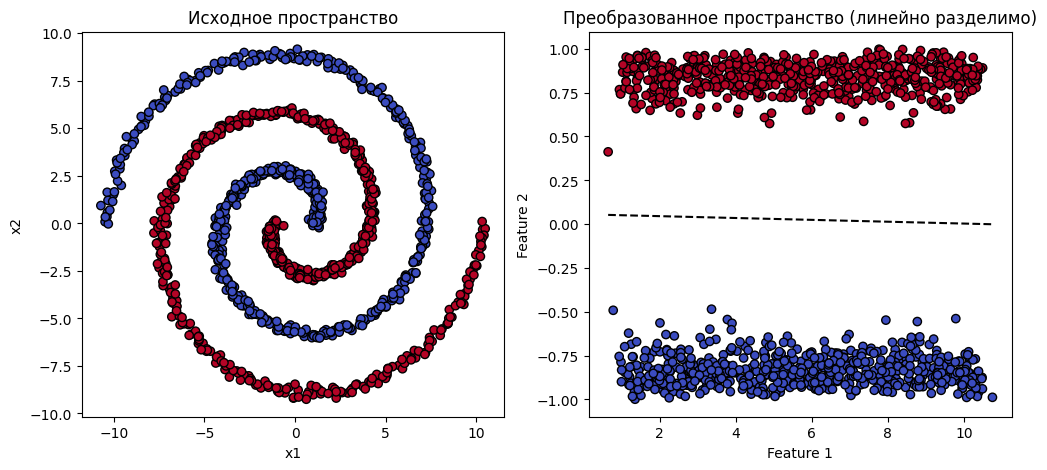

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Исходное пространство")
plt.xlabel("x1")
plt.ylabel("x2")

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y, cmap='coolwarm', edgecolors='k')

w = clf.coef_[0]
b = clf.intercept_[0]
x_plot = np.linspace(X_transformed[:, 0].min(), X_transformed[:, 0].max(), 100)
y_plot = (-w[0] * x_plot - b) / w[1]
plt.plot(x_plot, y_plot, 'k--')

plt.title("Преобразованное пространство (линейно разделимо)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

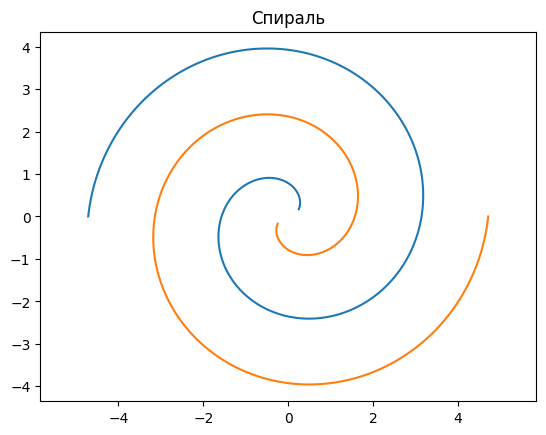

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spiral(a=0, b=1, turns=1, num_points=1050):
    theta = np.linspace(0.6, 0.6 * np.pi * turns, num_points)
    r = a + b * theta

    x1 = r * np.cos(theta)
    y1 = r * np.sin(theta)

    x2 = -r * np.cos(theta)
    y2 = -r * np.sin(theta)

    plt.plot(x1, y1)
    plt.plot(x2, y2)
    plt.axis("equal")
    plt.title("Спираль")
    plt.show()

plot_spiral(a=0, b=0.5, turns=5)


# 2 семестр

Задача 01A. Наивный байесовский классификатор

In [ ]:
# медленнее
import numpy as np

def naive_bayes_classifier(input_file, output_file):
    with open(input_file, 'r') as f:
        n, m, k = map(int, f.readline().strip().split())
        messages = np.array([list(map(int, line.strip().split())) for line in f])

    class_counts = np.ones(k)
    word_counts = np.ones((k, m))
    log_class_counts = np.log(class_counts)
    log_word_counts = np.log(word_counts)

    predictions = []

    for message in messages:
        features, true_class = message[:-1], message[-1]

        log_probs = log_class_counts - np.log(np.sum(class_counts))
        log_probs += np.sum(log_word_counts[:, features == 1] - np.log(np.sum(word_counts, axis=1))[:, None], axis=1)

        best_class = np.argmax(log_probs)
        predictions.append(best_class)

        class_counts[true_class] += 1
        word_counts[true_class] += features
        log_class_counts = np.log(class_counts)
        log_word_counts = np.log(word_counts)

    with open(output_file, 'w') as f:
        f.write('\n'.join(map(str, predictions)))

naive_bayes_classifier('input.txt', 'output.txt')

In [ ]:
# быстро
import numpy as np

def naive_bayes_classifier(input, output):
    with open(input, 'r') as f:
        n, m, k = map(int, f.readline().strip().split())
        data = np.array([list(map(int, line.strip().split())) for line in f])

    features, true_classes = data[:, :-1], data[:, -1]

    class_counts = np.ones(k)
    word_counts = np.ones((k, m))

    predictions = np.empty(n, dtype=int)

    for i, (x, y) in enumerate(zip(features, true_classes)):
        # Шаг 1: Априорные вероятности классов log𝑃(𝑐)
        log_probs = np.log(class_counts) - np.log(class_counts.sum())
        # Шаг 2: Условные вероятности слов logP(x∣c)
        log_probs += (np.log(word_counts[:, x == 1]) - np.log(word_counts.sum(axis=1, keepdims=True))).sum(axis=1)
        predictions[i] = np.argmax(log_probs)


        class_counts[y] += 1 # априорные вероятности
        word_counts[y] += x # по 8 признаков в каждом классе

    with open(output, 'w') as f:
        f.write('\n'.join(map(str, predictions)))

naive_bayes_classifier('input.txt', 'output.txt')

[-11.09035489 -11.09035489]
[-7.33693691 -7.407166  ]
[-13.69422446 -13.3102546 ]
[-8.42843028 -9.80367489]
[-13.1347859  -11.42635803]
[-5.6756116  -7.60887063]
[-11.56148703  -8.55333224]
[-6.01630959 -8.09949355]
[-16.30102177 -16.1175717 ]
[-9.21645497 -5.95675715]


Задача 01B. Байесовский классификатор

In [ ]:
import numpy as np

def read_input(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    n, m, k, l = map(int, lines[0].split())
    lambda_matrix = np.array([list(map(float, lines[i + 1].split())) for i in range(m)])

    training_data = []
    for i in range(k):
        *coords, class_label = map(float, lines[m + 1 + i].split())
        training_data.append((np.array(coords), int(class_label)))

    test_data = [np.array(list(map(float, lines[m + 1 + k + i].split()))) for i in range(l)]

    return n, m, k, l, lambda_matrix, training_data, test_data

def train_classifier(training_data, m, n):
    class_data = {i: [] for i in range(m)}
    for coords, class_label in training_data:
        class_data[class_label].append(coords)

    priors = {i: len(class_data[i]) / len(training_data) for i in range(m)}
    means = {i: np.mean(class_data[i], axis=0) if class_data[i] else np.zeros(n) for i in range(m)}
    covariances = {i: np.cov(np.array(class_data[i]).T) if len(class_data[i]) > 1 else np.eye(n) for i in range(m)}

    return priors, means, covariances

def multivariate_normal_density(x, mean, covariance):
    n = len(mean)
    det = np.linalg.det(covariance)
    inv = np.linalg.inv(covariance)
    norm_const = 1.0 / (np.sqrt((2 * np.pi) ** n * det) + 1e-6)
    diff = x - mean
    exponent = -0.5 * np.dot(diff.T, np.dot(inv, diff))
    return norm_const * np.exp(exponent)

def classify(test_data, priors, means, covariances, lambda_matrix, m):
    predictions = []
    for x in test_data:
        scores = []
        for i in range(m):
            likelihood = multivariate_normal_density(x, means[i], covariances[i])
            penalty = np.prod([lambda_matrix[i, j] for j in range(m) if j != i])
            score = priors[i] * likelihood * penalty
            scores.append(score)
        predictions.append(np.argmax(scores))

    return predictions

def write_output(filename, predictions):
    with open(filename, 'w') as f:
        f.write(' '.join(map(str, predictions)))

n, m, k, l, lambda_matrix, training_data, test_data = read_input('input.txt')
priors, means, covariances = train_classifier(training_data, m, n)
predictions = classify(test_data, priors, means, covariances, lambda_matrix, m)
write_output('output.txt', predictions)

In [ ]:
# https://chatgpt.com/c/681b352a-cd14-8010-899d-0e3d00bd0092

Задача 02A. Entropy

In [ ]:
import numpy as np

def entropy(y: np.ndarray) -> float:

    values, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return -np.sum(prob * np.log(prob))

y = np.array([1, 1, 2, 2, 2, 3, 3, 3, 3])
print(entropy(y))

1.0608569471580214


Задача 02B. Gini

In [ ]:
import numpy as np

def gini(y: np.ndarray) -> float:
    values, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return 1 - np.sum(prob ** 2)

with open('input.txt', 'r') as f:
    y = np.array(list(map(int, f.readline().split())))

result = gini(y)

with open('output.txt', 'w') as f:
    f.write(f"{result:.17f}")

In [ ]:
import numpy as np

def gini(y: np.ndarray) -> float:
    _, counts = np.unique(y, return_counts=True)
    prob = counts / len(y)
    return 1.0 - np.sum(prob * prob)


In [ ]:
from collections import Counter

def gini(y):
    n = len(y)
    freqs = Counter(y)
    return 1.0 - sum((count / n) ** 2 for count in freqs.values())

with open('input.txt') as f:
    y = list(map(int, f.readline().split()))

result = gini(y)

with open('output.txt', 'w') as f:
    f.write(f"{result:.17f}")


Задача 02C. Decision tree split

In [ ]:
import numpy as np

def gini(y: np.ndarray) -> float:
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return 1 - np.sum(probabilities ** 2)

def entropy(y: np.ndarray) -> float:
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log(probabilities))

def variance(y: np.ndarray) -> float:
    return np.var(y) if len(y) > 0 else 0

def impurity(y: np.ndarray, criterion: str) -> float:
    if criterion == 'gini':
        return gini(y)
    elif criterion == 'entropy':
        return entropy(y)
    elif criterion == 'var':
        return variance(y)
    else:
        raise ValueError("Invalid criterion")

def tree_split(X: np.ndarray, y: np.ndarray, criterion: str):
    best_col, best_row = None, None
    best_impurity = float('inf')
    n_samples, n_features = X.shape

    for col in range(n_features):
        thresholds = np.unique(X[:, col])
        for threshold in thresholds:
            left_mask = X[:, col] <= threshold
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            left_impurity = impurity(y[left_mask], criterion)
            right_impurity = impurity(y[right_mask], criterion)
            weighted_impurity = (left_mask.sum() * left_impurity + right_mask.sum() * right_impurity) / n_samples

            if weighted_impurity < best_impurity:
                best_impurity = weighted_impurity
                best_col, best_row = col, np.where(X[:, col] == threshold)[0][0]

    return best_col, best_row


# Задача 03A. Canny

In [ ]:
import numpy as np
from scipy.ndimage import convolve
from typing import Tuple


def gaussian_kernel(kernel_size: Tuple[int, int], sigma: float) -> np.ndarray:
    m, n = [(ss - 1) // 2 for ss in kernel_size]
    y, x = np.ogrid[-m:m + 1, -n:n + 1]
    h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
    h /= h.sum()
    return h


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve(img, g_kernel, mode='reflect')


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    gx = convolve(img, kernel, mode='reflect')
    gy = convolve(img, kernel.T, mode='reflect')

    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)

    return magnitude, direction


def angle_to_direction_index(angle: float) -> int:
    degree = angle * 180 / np.pi
    degree = degree % 180
    if (0 <= degree < 22.5) or (157.5 <= degree < 180):
        return 0
    elif 22.5 <= degree < 67.5:
        return 1
    elif 67.5 <= degree < 112.5:
        return 2
    elif 112.5 <= degree < 157.5:
        return 3


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    H, W = magnitude.shape
    mask = np.zeros_like(magnitude, dtype=bool)
    angle_sector = np.vectorize(angle_to_direction_index)(direction)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            current = magnitude[i, j]
            sector = angle_sector[i, j]

            if sector == 0:  # 0°
                neighbors = (magnitude[i, j - 1], magnitude[i, j + 1])
            elif sector == 1:  # 45°
                neighbors = (magnitude[i - 1, j + 1], magnitude[i + 1, j - 1])
            elif sector == 2:  # 90°
                neighbors = (magnitude[i - 1, j], magnitude[i + 1, j])
            elif sector == 3:  # 135°
                neighbors = (magnitude[i - 1, j - 1], magnitude[i + 1, j + 1])

            if current >= neighbors[0] and current >= neighbors[1]:
                mask[i, j] = True

    return mask


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    strong_edges = (magnitude >= high_threshold) & mask
    weak_edges = (magnitude >= low_threshold) & mask & ~strong_edges

    H, W = magnitude.shape
    visited = np.zeros_like(magnitude, dtype=bool)
    result = np.copy(strong_edges)

    def dfs(x, y):
        if visited[x, y]:
            return
        visited[x, y] = True
        result[x, y] = True
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if (0 <= nx < H) and (0 <= ny < W):
                    if weak_edges[nx, ny] and not visited[nx, ny]:
                        dfs(nx, ny)

    for i in range(H):
        for j in range(W):
            if strong_edges[i, j] and not visited[i, j]:
                dfs(i, j)

    return result


In [ ]:
import numpy as np
from scipy.ndimage import convolve
from typing import Tuple


def gaussian_kernel(kernel_size: Tuple[int, int], sigma: float) -> np.ndarray:
    m, n = [(ss - 1) // 2 for ss in kernel_size]
    y, x = np.ogrid[-m:m + 1, -n:n + 1]
    h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
    h /= h.sum()
    return h


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve(img, g_kernel, mode='reflect')


def sobel_kernels() -> Tuple[np.ndarray, np.ndarray]:
    Kx = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=float)
    Ky = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=float)
    return Kx, Ky


def magnitude_and_direction(img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Kx, Ky = sobel_kernels()
    gx = convolve(img, Kx, mode='reflect')
    gy = convolve(img, Ky, mode='reflect')

    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    return magnitude, direction


def angle_to_direction_index(angle: float) -> int:
    degree = np.rad2deg(angle) % 180
    if (0 <= degree < 22.5) or (157.5 <= degree < 180):
        return 0  # 0°
    elif 22.5 <= degree < 67.5:
        return 1  # 45°
    elif 67.5 <= degree < 112.5:
        return 2  # 90°
    elif 112.5 <= degree < 157.5:
        return 3  # 135°


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    H, W = magnitude.shape
    output = np.zeros_like(magnitude, dtype=bool)

    angle_sector = np.vectorize(angle_to_direction_index)(direction)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            sector = angle_sector[i, j]
            current = magnitude[i, j]

            if sector == 0:  # 0°
                neighbors = (magnitude[i, j - 1], magnitude[i, j + 1])
            elif sector == 1:  # 45°
                neighbors = (magnitude[i - 1, j + 1], magnitude[i + 1, j - 1])
            elif sector == 2:  # 90°
                neighbors = (magnitude[i - 1, j], magnitude[i + 1, j])
            elif sector == 3:  # 135°
                neighbors = (magnitude[i - 1, j - 1], magnitude[i + 1, j + 1])

            if current >= neighbors[0] and current >= neighbors[1]:
                output[i, j] = True

    return output


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    strong_edges = (magnitude >= high_threshold) & mask
    weak_edges = (magnitude >= low_threshold) & mask & ~strong_edges

    H, W = magnitude.shape
    visited = np.zeros_like(magnitude, dtype=bool)
    result = np.copy(strong_edges)

    def dfs(x, y):
        if visited[x, y]:
            return
        visited[x, y] = True
        result[x, y] = True
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx, ny = x + dx, y + dy
                if (0 <= nx < H) and (0 <= ny < W):
                    if weak_edges[nx, ny] and not visited[nx, ny]:
                        dfs(nx, ny)

    for i in range(H):
        for j in range(W):
            if strong_edges[i, j] and not visited[i, j]:
                dfs(i, j)

    return result


In [ ]:
import cv2 as cv

img = cv.imread('input.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(float)
blur = gaussian_blur(img, (5, 5), 1)
magnitude, direction = magnitude_and_direction(blur, np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]))
mask = edge_thinning(magnitude, direction)
edges = edge_tracking(magnitude, mask, 0.1 * np.max(magnitude), 0.2 * np.max(magnitude))
cv.imwrite('sample.png', edges.astype(int) * 255)

True

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter, convolve
from typing import Tuple


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    '''Blurs an image using Gaussian filter.'''
    return gaussian_filter(img, sigma=sigma, mode='reflect')


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    '''Computes gradient magnitude and direction using Sobel-like kernels.'''
    gx = convolve(img, kernel, mode='reflect')
    gy = convolve(img, kernel.T, mode='reflect')

    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)

    # Normalize magnitude to [0, 1] for consistency
    magnitude /= magnitude.max() + 1e-8
    return magnitude, direction


def angle_to_sector(direction: np.ndarray) -> np.ndarray:
    '''Quantizes gradient direction into one of 4 directions: 0, 45, 90, 135 degrees.'''
    degree = np.rad2deg(direction) % 180
    sector = np.zeros_like(degree, dtype=np.uint8)
    sector[(0 <= degree) & (degree < 22.5)] = 0
    sector[(157.5 <= degree) & (degree < 180)] = 0
    sector[(22.5 <= degree) & (degree < 67.5)] = 1
    sector[(67.5 <= degree) & (degree < 112.5)] = 2
    sector[(112.5 <= degree) & (degree < 157.5)] = 3
    return sector


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    '''Performs non-maximum suppression for edge thinning.'''
    H, W = magnitude.shape
    mask = np.zeros_like(magnitude, dtype=bool)
    sector = angle_to_sector(direction)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            angle = sector[i, j]
            m = magnitude[i, j]

            if angle == 0:
                neighbors = (magnitude[i, j - 1], magnitude[i, j + 1])
            elif angle == 1:
                neighbors = (magnitude[i - 1, j + 1], magnitude[i + 1, j - 1])
            elif angle == 2:
                neighbors = (magnitude[i - 1, j], magnitude[i + 1, j])
            elif angle == 3:
                neighbors = (magnitude[i - 1, j - 1], magnitude[i + 1, j + 1])
            else:
                continue

            if m >= neighbors[0] and m >= neighbors[1]:
                mask[i, j] = True

    return mask


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    '''Performs hysteresis thresholding for edge tracking.'''
    strong_edges = (magnitude >= high_threshold) & mask
    weak_edges = (magnitude >= low_threshold) & mask & ~strong_edges

    H, W = magnitude.shape
    visited = np.zeros_like(magnitude, dtype=bool)
    result = np.copy(strong_edges)

    def dfs_iterative(x, y):
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if visited[cx, cy]:
                continue
            visited[cx, cy] = True
            result[cx, cy] = True
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = cx + dx, cy + dy
                    if 0 <= nx < H and 0 <= ny < W:
                        if weak_edges[nx, ny] and not visited[nx, ny]:
                            stack.append((nx, ny))

    for i in range(H):
        for j in range(W):
            if strong_edges[i, j] and not visited[i, j]:
                dfs_iterative(i, j)

    return result


In [ ]:
import numpy as np
from scipy.ndimage import convolve
from typing import Tuple


def gaussian_kernel(kernel_size: Tuple[int, int], sigma: float) -> np.ndarray:
    """Генерация 2D Гауссова ядра."""
    m, n = [(s - 1) // 2 for s in kernel_size]
    y, x = np.ogrid[-m:m + 1, -n:n + 1]
    h = np.exp(-(x**2 + y**2) / (2. * sigma**2))
    h /= h.sum()
    return h


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    """Применение Гауссова размытия к изображению."""
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve(img, g_kernel, mode='reflect')


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Вычисление градиента изображения по Собелю и направление градиента."""
    gx = convolve(img, kernel, mode='reflect')
    gy = convolve(img, kernel.T, mode='reflect')
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)
    return magnitude, direction


def angle_to_sector(angle: float) -> int:
    """Преобразование угла в один из 4 секторов (0°, 45°, 90°, 135°)."""
    angle_deg = np.rad2deg(angle) % 180
    if (0 <= angle_deg < 22.5) or (157.5 <= angle_deg < 180):
        return 0  # горизонталь
    elif 22.5 <= angle_deg < 67.5:
        return 1  # 45°
    elif 67.5 <= angle_deg < 112.5:
        return 2  # вертикаль
    elif 112.5 <= angle_deg < 157.5:
        return 3  # 135°


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    """Подавление немаксимальных значений — тонкие границы."""
    H, W = magnitude.shape
    mask = np.zeros_like(magnitude, dtype=bool)
    angle_sector = np.vectorize(angle_to_sector)(direction)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            current = magnitude[i, j]
            sector = angle_sector[i, j]

            if sector == 0:
                neighbors = (magnitude[i, j - 1], magnitude[i, j + 1])
            elif sector == 1:
                neighbors = (magnitude[i - 1, j + 1], magnitude[i + 1, j - 1])
            elif sector == 2:
                neighbors = (magnitude[i - 1, j], magnitude[i + 1, j])
            elif sector == 3:
                neighbors = (magnitude[i - 1, j - 1], magnitude[i + 1, j + 1])

            if current >= neighbors[0] and current >= neighbors[1]:
                mask[i, j] = True

    return mask


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    """Гистерезис: соединение слабых и сильных границ."""
    strong = (magnitude >= high_threshold) & mask
    weak = (magnitude >= low_threshold) & mask & ~strong

    H, W = magnitude.shape
    result = np.copy(strong)
    visited = np.zeros_like(magnitude, dtype=bool)

    def dfs(x, y):
        if visited[x, y]:
            return
        visited[x, y] = True
        result[x, y] = True
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < H and 0 <= ny < W:
                    if weak[nx, ny] and not visited[nx, ny]:
                        dfs(nx, ny)

    for i in range(H):
        for j in range(W):
            if strong[i, j] and not visited[i, j]:
                dfs(i, j)

    return result


In [ ]:
import numpy as np
from scipy.ndimage import convolve
from typing import Tuple


def gaussian_kernel(kernel_size: Tuple[int, int], sigma: float) -> np.ndarray:
    m, n = [(s - 1) // 2 for s in kernel_size]
    y, x = np.ogrid[-m:m + 1, -n:n + 1]
    h = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    h /= h.sum()
    return h


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve(img, g_kernel, mode='reflect')


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    gx = convolve(img, kernel, mode='reflect')
    gy = convolve(img, kernel.T, mode='reflect')
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)
    return magnitude, direction


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    H, W = magnitude.shape
    output = np.zeros_like(magnitude, dtype=bool)

    # Преобразуем направление в градусы от 0 до 180
    angle = (np.rad2deg(direction) + 180) % 180

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            curr_mag = magnitude[i, j]
            dir = angle[i, j]

            # Направление градиента -> выбор соседей
            if (0 <= dir < 22.5) or (157.5 <= dir < 180):  # 0°
                before = magnitude[i, j - 1]
                after = magnitude[i, j + 1]
            elif 22.5 <= dir < 67.5:  # 45°
                before = magnitude[i - 1, j + 1]
                after = magnitude[i + 1, j - 1]
            elif 67.5 <= dir < 112.5:  # 90°
                before = magnitude[i - 1, j]
                after = magnitude[i + 1, j]
            elif 112.5 <= dir < 157.5:  # 135°
                before = magnitude[i - 1, j - 1]
                after = magnitude[i + 1, j + 1]
            else:
                continue

            if curr_mag >= before and curr_mag >= after:
                output[i, j] = True

    return output



def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    strong = (magnitude >= high_threshold) & mask
    weak = (magnitude >= low_threshold) & mask & ~strong

    H, W = magnitude.shape
    visited = np.zeros_like(magnitude, dtype=bool)
    result = np.copy(strong)

    def dfs(x: int, y: int):
        if visited[x, y]:
            return
        visited[x, y] = True
        result[x, y] = True
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < H and 0 <= ny < W:
                    if weak[nx, ny] and not visited[nx, ny]:
                        dfs(nx, ny)

    for i in range(H):
        for j in range(W):
            if strong[i, j] and not visited[i, j]:
                dfs(i, j)

    return result


не решено

True

Задача 03A. Canny

In [1]:
import numpy as np
from typing import Tuple


def gaussian_kernel(size: Tuple[int, int], sigma: float) -> np.ndarray:
    h, w = size
    y, x = np.mgrid[-(h // 2):(h // 2 + 1), -(w // 2):(w // 2 + 1)]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    g /= g.sum()
    return g


def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve2d(img, g_kernel)


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    gx = convolve2d(img, kernel)
    gy = convolve2d(img, kernel.T)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)
    return magnitude, direction


def angle_to_sector(angle: float) -> int:
    degree = np.rad2deg(angle) % 180
    if degree < 22.5 or degree >= 157.5:
        return 0
    elif degree < 67.5:
        return 45
    elif degree < 112.5:
        return 90
    else:
        return 135


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    h, w = magnitude.shape
    mask = np.zeros((h, w), dtype=bool)
    angle_sector = np.vectorize(angle_to_sector)(direction)
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            angle = angle_sector[i, j]
            m = magnitude[i, j]
            if angle == 0:
                neighbors = [magnitude[i, j - 1], magnitude[i, j + 1]]
            elif angle == 45:
                neighbors = [magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]]
            elif angle == 90:
                neighbors = [magnitude[i - 1, j], magnitude[i + 1, j]]
            else:
                neighbors = [magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]]
            mask[i, j] = m >= max(neighbors)
    return mask


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    strong = (magnitude >= high_threshold) & mask
    weak = (magnitude >= low_threshold) & mask & ~strong
    result = np.copy(strong)
    h, w = magnitude.shape

    changed = True
    while changed:
        changed = False
        new_result = result.copy()
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                if weak[i, j] and np.any(result[i - 1:i + 2, j - 1:j + 2]):
                    new_result[i, j] = True
                    changed = True
        result = new_result
    return result


2 попытка

In [5]:
import numpy as np
from typing import Tuple
from collections import deque

def gaussian_kernel(size: Tuple[int, int], sigma: float) -> np.ndarray:
    h, w = size
    y, x = np.mgrid[-(h // 2):(h // 2 + 1), -(w // 2):(w // 2 + 1)]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    g /= g.sum()
    return g


def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(image)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(
                padded[i:i+kh, j:j+kw] * kernel
            )
    return out


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    g_kernel = gaussian_kernel(kernel, sigma)
    return convolve2d(img, g_kernel)


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    gx = convolve2d(img, kernel)
    gy = convolve2d(img, kernel.T)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)
    return magnitude, direction


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    H, W = magnitude.shape
    angle = direction * (180.0 / np.pi)
    angle[angle < 0] += 180

    result = np.zeros((H, W), dtype=bool)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            q = 255
            r = 255

            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = magnitude[i, j + 1]
                r = magnitude[i, j - 1]
            elif 22.5 <= angle[i,j] < 67.5:
                q = magnitude[i + 1, j - 1]
                r = magnitude[i - 1, j + 1]
            elif 67.5 <= angle[i,j] < 112.5:
                q = magnitude[i + 1, j]
                r = magnitude[i - 1, j]
            elif 112.5 <= angle[i,j] < 157.5:
                q = magnitude[i - 1, j - 1]
                r = magnitude[i + 1, j + 1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                result[i, j] = True
                
    return result

def edge_tracking(magnitude, mask, low_threshold, high_threshold):
    strong = (magnitude >= high_threshold) & mask
    weak = (magnitude >= low_threshold) & mask

    result = np.zeros_like(magnitude, dtype=bool)
    result[strong] = True

    visited = np.zeros_like(magnitude, dtype=bool)
    queue = deque(zip(*np.where(strong)))

    while queue:
        y, x = queue.popleft()
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                ny, nx = y + dy, x + dx
                if (0 <= ny < magnitude.shape[0]) and (0 <= nx < magnitude.shape[1]):
                    if not visited[ny, nx] and weak[ny, nx]:
                        result[ny, nx] = True
                        visited[ny, nx] = True
                        queue.append((ny, nx))
    return result

In [36]:
import numpy as np
from typing import Tuple
from collections import deque


def gaussian_kernel(kernel_size: Tuple[int, int], sigma: float) -> np.ndarray:
    h, w = kernel_size
    y, x = np.mgrid[-(h // 2):(h // 2 + 1), -(w // 2):(w // 2 + 1)]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel


def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='reflect')
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            output[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return output


def gaussian_blur(img: np.ndarray, kernel: Tuple[int, int], sigma: float) -> np.ndarray:
    return convolve2d(img, gaussian_kernel(kernel, sigma))


def magnitude_and_direction(img: np.ndarray, kernel: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    gx = convolve2d(img, kernel)
    gy = convolve2d(img, kernel.T)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx) % (2 * np.pi)
    return magnitude, direction


def edge_thinning(magnitude: np.ndarray, direction: np.ndarray) -> np.ndarray:
    H, W = magnitude.shape
    output = np.zeros((H, W), dtype=bool)
    angle = (direction * 180.0 / np.pi) % 180

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            ang = angle[i, j]
            mag = magnitude[i, j]

            # Map angle to 0, 45, 90, 135
            if (0 <= ang < 22.5) or (157.5 <= ang <= 180):
                before = magnitude[i, j - 1]
                after = magnitude[i, j + 1]
            elif 22.5 <= ang < 67.5:
                before = magnitude[i - 1, j + 1]
                after = magnitude[i + 1, j - 1]
            elif 67.5 <= ang < 112.5:
                before = magnitude[i - 1, j]
                after = magnitude[i + 1, j]
            else:  # 112.5 <= ang < 157.5
                before = magnitude[i - 1, j - 1]
                after = magnitude[i + 1, j + 1]

            if mag >= before and mag >= after:
                output[i, j] = True

    return output


def edge_tracking(magnitude: np.ndarray, mask: np.ndarray, low_threshold: float, high_threshold: float) -> np.ndarray:
    strong = (magnitude >= high_threshold) & mask
    weak = (magnitude >= low_threshold) & mask

    result = np.zeros_like(magnitude, dtype=bool)
    result[strong] = True

    queue = deque(zip(*np.where(strong)))
    visited = np.zeros_like(magnitude, dtype=bool)
    visited[strong] = True

    while queue:
        y, x = queue.popleft()
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                ny, nx = y + dy, x + dx
                if (
                    0 <= ny < magnitude.shape[0]
                    and 0 <= nx < magnitude.shape[1]
                    and not visited[ny, nx]
                    and weak[ny, nx]
                ):
                    result[ny, nx] = True
                    visited[ny, nx] = True
                    queue.append((ny, nx))

    return result


In [37]:
import cv2 as cv

img = cv.imread('input.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(float)
blur = gaussian_blur(img, (5, 5), 1)
magnitude, direction = magnitude_and_direction(blur, np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]))
mask = edge_thinning(magnitude, direction)
edges = edge_tracking(magnitude, mask, 0.1 * np.max(magnitude), 0.2 * np.max(magnitude))

cv.imwrite('sample.png', edges.astype(int) * 255)

True

# Задача 03B. Hough Lines


In [ ]:
import numpy as np
from typing import List, Tuple

def hough_lines(
    image: np.ndarray,
    rho: float,
    theta: float,
    threshold: int,
    min_theta: float = 0,
    max_theta: float = np.pi
) -> List[Tuple[float, float, int]]:

    height, width = image.shape
    diag_len = int(np.ceil(np.hypot(height, width)))
    max_dist = diag_len

    rhos = np.arange(-max_dist, max_dist + rho, rho)
    thetas = np.arange(min_theta, max_theta, theta)
    num_rhos = len(rhos)
    num_thetas = len(thetas)

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    y_idxs, x_idxs = np.nonzero(image)
    coords = np.stack((x_idxs, y_idxs), axis=1)

    r_vals = coords[:, 0:1] * cos_t + coords[:, 1:2] * sin_t
    r_idxs = np.round((r_vals + max_dist) / rho).astype(np.int32)

    valid = (r_idxs >= 0) & (r_idxs < num_rhos)
    i, j = np.where(valid)
    r_valid = r_idxs[i, j]
    t_valid = j

    accumulator = np.zeros((num_rhos, num_thetas), dtype=np.int32)
    np.add.at(accumulator, (r_valid, t_valid), 1)

    a = accumulator
    filtered = np.zeros_like(a)
    core = a[1:-1, 1:-1]
    mask = (
        (core > a[0:-2, 1:-1]) &
        (core > a[1:-1, 0:-2]) &
        (core >= a[2:, 1:-1]) &
        (core >= a[1:-1, 2:])
    )
    filtered[1:-1, 1:-1][mask] = core[mask]

    i_idxs, j_idxs = np.where(filtered > threshold)
    lines = [(rhos[i], thetas[j], filtered[i, j]) for i, j in zip(i_idxs, j_idxs)]
    lines.sort(key=lambda x: (-x[2], x[1], x[0]))
    return lines

In [ ]:
import cv2
image = cv2.Canny(cv2.imread('lines.jpg'), 500, 550).astype(bool)
print(*(f'{i} {j:.3f} {k}' for i, j, k in hough_lines(image, 1, np.pi / 360, 210)), sep='\n')

450 0.314 636
460 0.314 580
216 0.785 580
-908 2.635 429
522 2.094 420
933 1.370 393
944 1.370 373
532 2.094 369
590 2.199 328
227 0.785 305
-897 2.635 288
-115 2.915 286
1464 0.646 283
57 1.815 281
582 2.199 279
65 1.815 271
373 1.274 265
55 1.815 263
381 1.274 259
63 1.815 258
-106 2.915 255
-833 2.801 225
-826 2.793 218
-824 2.801 218
-817 2.793 217
1475 0.646 212


# Задача 03C. Hough Circles

In [ ]:
import numpy as np
import cv2
from typing import List, Tuple
from collections import defaultdict

def hough_circles(
    image: np.ndarray,
    accumulator_resolution: float,
    min_distance: int,
    canny_threshold: int,
    accumulator_threshold: int,
    min_radius: int,
    max_radius: int) -> List[Tuple[float, float, float, int]]:

    height, width = image.shape

    # 1. Детектор Кэнни
    edges = cv2.Canny(image.astype(np.uint8), canny_threshold // 2, canny_threshold)
    y_idxs, x_idxs = np.nonzero(edges)

    # 2. Список радиусов
    radii = np.arange(min_radius, max_radius + 1)

    # 3. Аккумулятор по центрам и радиусам
    center_accumulators = [np.zeros((int(height / accumulator_resolution), int(width / accumulator_resolution)), dtype=np.uint16) for _ in radii]

    # Предвычислим углы
    angles = np.arange(0, 2 * np.pi, np.pi / 180)
    cos_vals = np.cos(angles)
    sin_vals = np.sin(angles)

    for x, y in zip(x_idxs, y_idxs):
        for r_idx, radius in enumerate(radii):
            a_vals = x - radius * cos_vals
            b_vals = y - radius * sin_vals
            a_vals = np.round(a_vals / accumulator_resolution).astype(int)
            b_vals = np.round(b_vals / accumulator_resolution).astype(int)

            valid = (a_vals >= 0) & (a_vals < center_accumulators[r_idx].shape[1]) & (b_vals >= 0) & (b_vals < center_accumulators[r_idx].shape[0])
            for a, b in zip(a_vals[valid], b_vals[valid]):
                center_accumulators[r_idx][b, a] += 1

    circles = []
    for r_idx, acc in enumerate(center_accumulators):
        radius = radii[r_idx]
        h, w = acc.shape
        # 4. Фильтрация локальных максимумов
        filtered = np.zeros_like(acc)
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                val = acc[i, j]
                if (
                    val > acc[i - 1, j] and
                    val > acc[i, j - 1] and
                    val >= acc[i + 1, j] and
                    val >= acc[i, j + 1]
                ):
                    filtered[i, j] = val

        # 5. Выбор кандидатов
        for i in range(h):
            for j in range(w):
                votes = filtered[i, j]
                if votes >= accumulator_threshold:
                    x = j * accumulator_resolution
                    y = i * accumulator_resolution
                    circles.append((x, y, radius, votes))

    # 6. Оставляем только лучшие (по голосам / радиус)
    best_circles = defaultdict(lambda: (0, 0))  # (score, votes)
    final_circles = []
    for x, y, r, votes in circles:
        score = votes / r
        # key = (int(x), int(y))
        key = (int(round(x / accumulator_resolution)), int(round(y / accumulator_resolution)))

        if score > best_circles[key][0]:
            # best_circles[key] = (score, votes, r)
            best_circles[key] = (score, x, y, r, votes)


    for (x, y), (score, votes, r) in best_circles.items():
        final_circles.append((x, y, r, votes))

    # 7. Удаление близких центров
    result = []
    taken = np.zeros(len(final_circles), dtype=bool)
    for i, (x1, y1, r1, v1) in enumerate(final_circles):
        if taken[i]:
            continue
        result.append((x1, y1, r1, v1))
        for j, (x2, y2, r2, v2) in enumerate(final_circles):
            if i != j and not taken[j]:
                if np.hypot(x1 - x2, y1 - y2) < min_distance:
                    taken[j] = True

    result.sort(key=lambda x: -x[3])
    return result


In [ ]:
import numpy as np
import cv2
from typing import List, Tuple
from collections import defaultdict

def hough_circles(
    image: np.ndarray,
    accumulator_resolution: float,
    min_distance: int,
    canny_threshold: int,
    accumulator_threshold: int,
    min_radius: int,
    max_radius: int) -> List[Tuple[float, float, float, int]]:

    height, width = image.shape

    # 1. Детектор Кэнни
    edges = cv2.Canny(image.astype(np.uint8), canny_threshold // 2, canny_threshold)
    y_idxs, x_idxs = np.nonzero(edges)

    # 2. Список радиусов
    radii = np.arange(min_radius, max_radius + 1)

    # 3. Аккумуляторы по радиусам
    center_accumulators = [np.zeros((int(height / accumulator_resolution), int(width / accumulator_resolution)), dtype=np.uint16) for _ in radii]

    # Предвычисление углов
    angles = np.arange(0, 2 * np.pi, np.pi / 180)
    cos_vals = np.cos(angles)
    sin_vals = np.sin(angles)

    for x, y in zip(x_idxs, y_idxs):
        for r_idx, radius in enumerate(radii):
            a_vals = x - radius * cos_vals
            b_vals = y - radius * sin_vals
            a_vals = np.round(a_vals / accumulator_resolution).astype(int)
            b_vals = np.round(b_vals / accumulator_resolution).astype(int)

            valid = (a_vals >= 0) & (a_vals < center_accumulators[r_idx].shape[1]) & \
                    (b_vals >= 0) & (b_vals < center_accumulators[r_idx].shape[0])
            for a, b in zip(a_vals[valid], b_vals[valid]):
                center_accumulators[r_idx][b, a] += 1

    raw_candidates = []
    for r_idx, acc in enumerate(center_accumulators):
        radius = radii[r_idx]
        h, w = acc.shape

        # 4. Фильтрация локальных максимумов
        filtered = np.zeros_like(acc)
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                val = acc[i, j]
                if (
                    val > acc[i - 1, j] and
                    val > acc[i, j - 1] and
                    val >= acc[i + 1, j] and
                    val >= acc[i, j + 1]
                ):
                    filtered[i, j] = val

        # 5. Кандидаты
        for i in range(h):
            for j in range(w):
                votes = filtered[i, j]
                if votes >= accumulator_threshold:
                    x = j * accumulator_resolution
                    y = i * accumulator_resolution
                    raw_candidates.append((x, y, radius, votes))

    # 6. Выбор лучших по метрике votes / radius
    best_circles = {}
    for x, y, r, votes in raw_candidates:
        score = votes / r
        key = (int(round(x / accumulator_resolution)), int(round(y / accumulator_resolution)))
        if key not in best_circles or score > best_circles[key][0]:
            best_circles[key] = (score, x, y, r, votes)

    final_circles = [(x, y, r, votes) for _, (score, x, y, r, votes) in best_circles.items()]

    # 7. Удаление близких по центру
    result = []
    taken = np.zeros(len(final_circles), dtype=bool)
    for i, (x1, y1, r1, v1) in enumerate(final_circles):
        if taken[i]:
            continue
        result.append((x1, y1, r1, v1))
        for j, (x2, y2, r2, v2) in enumerate(final_circles):
            if i != j and not taken[j]:
                if np.hypot(x1 - x2, y1 - y2) < min_distance:
                    taken[j] = True

    result.sort(key=lambda x: -x[3])
    return result


In [ ]:
import cv2
image = cv2.cvtColor(cv2.imread('circles.png'), cv2.COLOR_BGR2GRAY)
print(*(f'{x} {y} {r} {c}' for x, y, r, c in hough_circles(image, 1, 50, 250, 50, 50, 250)), sep='\n')


363 185 50 64
193 139 72 58
210 91 50 56
387 229 58 56
302 146 50 55
434 266 53 55
405 125 50 54
164 180 50 54
229 265 57 54
228 215 50 53
333 281 50 53
397 324 50 52
101 264 51 52
250 142 60 52
350 111 79 52
335 228 167 52
328 66 50 51
258 355 50 51
285 194 177 51
454 218 50 50
173 307 50 50
283 276 56 50
222 317 75 50


<ipython-input-11-9f537cae0de7>:93: RuntimeWarning: overflow encountered in scalar negative
  result.sort(key=lambda x: -x[3])


не решено

In [ ]:
# 301 217 203 143
# 216 163 100 139
# 384 273 101 138
# 352 135 101 131
# 246 305 100 126

# Задача 04A. OneRule boosting

In [ ]:
import numpy as np
import math

def read_input(filename):
    with open(filename) as f:
        m, n, k = map(int, f.readline().split())
        data = np.array([list(map(int, line.split())) for line in f])
    X, y = data[:, :-1], data[:, -1]
    return X, y, k

def write_output(filename, h0, regressors):
    with open(filename, 'w') as f:
        f.write(f"{h0:.3f}\n")
        for feat, values in regressors:
            f.write(f"{feat} " + " ".join(f"{v:.3f}" for v in values) + "\n")

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def train_onerule_boosting(X, y, k):
    m, n = X.shape
    features = list(range(n))

    # log(p / (1 - p))
    pos, neg = np.sum(y), m - np.sum(y)
    h0 = math.log(pos / neg)

    H = np.full(m, h0, dtype=np.float64)
    F = sigmoid(H)

    X_val_to_indices = [{} for _ in range(n)]
    for l in range(n):
        for val in np.unique(X[:, l]):
            X_val_to_indices[l][val] = np.where(X[:, l] == val)[0]

    regressors = []

    for _ in range(k):
        r = y - F

        best_feat = -1
        best_vals = []
        best_loss = float('inf')

        for l in features:
            mapping = {}
            pred_r = np.zeros(m, dtype=np.float64)

            for val, idxs in X_val_to_indices[l].items():
                r_t = r[idxs]
                mean = np.mean(r_t) if len(r_t) > 0 else 0
                mapping[val] = mean
                pred_r[idxs] = mean

            loss = np.mean((r - pred_r) ** 2)
            if loss < best_loss:
                best_loss = loss
                best_feat = l
                best_vals = mapping

        refined = []
        for val in sorted(best_vals):
            idxs = X_val_to_indices[best_feat][val]
            r_t = r[idxs]
            p_t = F[idxs] * (1 - F[idxs])
            denom = np.sum(p_t)
            refined_val = np.sum(r_t) / denom if denom != 0 else 0.0
            refined.append(refined_val)

        update = np.zeros(m)
        for val, ref_val in zip(sorted(best_vals), refined):
            update[X_val_to_indices[best_feat][val]] = ref_val
        H += update
        F = sigmoid(H)

        regressors.append((best_feat, refined))
        features.remove(best_feat)

    return h0, regressors

X, y, k = read_input("input.txt")
h0, regs = train_onerule_boosting(X, y, k)
write_output("output.txt", h0, regs)

# Задача 05A. Dense

In [ ]:
import numpy as np
from typing import Optional, Tuple, Union

class Dense:
    def __init__(self, n_in: int, n_out: int, use_bias: bool = True):
        self.n_in = n_in
        self.n_out = n_out
        self.use_bias = use_bias

        self.W = np.random.uniform(-1, 1, (n_in, n_out))
        self.b = np.random.uniform(-1, 1, (n_out,)) if use_bias else None
        self._input = None

    @property
    def weights(self) -> Union[Tuple[np.ndarray, np.ndarray], Tuple[np.ndarray]]:
        return (self.W, self.b) if self.use_bias else (self.W,)

    @property
    def input(self) -> np.ndarray:
        return self._input

    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        out = x @ self.W
        if self.use_bias:
            out += self.b
        return out

    def grad(self, gradOutput: np.ndarray) -> Union[
        Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]],
        Tuple[np.ndarray, Tuple[np.ndarray]]
    ]:
        grad_input = gradOutput @ self.W.T
        grad_W = self._input.T @ gradOutput
        if self.use_bias:
            grad_b = gradOutput.sum(axis=0)
            return grad_input, (grad_W, grad_b)
        else:
            return grad_input, (grad_W,)


# Задача 05B. Activations

In [ ]:
from scipy.special import erf
import numpy as np

class Activation:
    def __init__(self):
        self._input = None

    @property
    def input(self):
        return self._input

    def __call__(self, x: np.ndarray) -> np.ndarray:
        raise NotImplementedError()

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        raise NotImplementedError()


class ReLU(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        return np.maximum(0, x)

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        return gradOutput * (self._input > 0)


class LeakyReLU(Activation):
    def __init__(self, slope: float = 0.03):
        super().__init__()
        self.slope = slope

    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        return np.where(x > 0, x, self.slope * x)

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        return gradOutput * np.where(self._input > 0, 1, self.slope)


class GeLU(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        return 0.5 * x * (1 + erf(x / np.sqrt(2)))

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        x = self._input
        phi = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
        Phi = 0.5 * (1 + erf(x / np.sqrt(2)))
        return gradOutput * (Phi + x * phi)


class SiLU(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        self.sigmoid = 1 / (1 + np.exp(-x))
        return x * self.sigmoid

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        sig = self.sigmoid
        return gradOutput * (sig * (1 + self._input * (1 - sig)))


class Softplus(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        return gradOutput * (1 / (1 + np.exp(-self._input)))


class ELU(Activation):
    def __init__(self, alpha: float = 1):
        super().__init__()
        self.alpha = alpha

    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        return np.where(x >= 0, x, self.alpha * (np.exp(x) - 1))

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        return gradOutput * np.where(self._input >= 0, 1, self.alpha * np.exp(self._input))


class Sigmoid(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        self._sigmoid = 1 / (1 + np.exp(-x))
        return self._sigmoid

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        sig = self._sigmoid
        return gradOutput * sig * (1 - sig)


class Tanh(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        self._tanh = np.tanh(x)
        return self._tanh

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        return gradOutput * (1 - self._tanh ** 2)


class Softmax(Activation):
    def __call__(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(shifted)
        self._softmax = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return self._softmax

    def grad(self, gradOutput: np.ndarray) -> np.ndarray:
        s = self._softmax
        batch_size, n = s.shape
        grad_input = np.empty_like(gradOutput)
        for i in range(batch_size):
            si = s[i].reshape(-1, 1)
            jacobian = np.diagflat(si) - si @ si.T
            grad_input[i] = jacobian @ gradOutput[i]
        return grad_input

# Задача 05C. Conv2D

In [ ]:
import numpy as np


class Conv2D:
    def __init__(self,
                 n_in: int,
                 n_out: int,
                 kernel_size: tuple[int, int],
                 strides: tuple[int, int] = (1, 1),
                 padding: str = 'valid',
                 use_bias: bool = True,
                 dilations: tuple[int, int] = (1, 1)):
        self.n_in = n_in
        self.n_out = n_out
        self.kh, self.kw = kernel_size
        self.sh, self.sw = strides
        self.dh, self.dw = dilations
        self.use_bias = use_bias
        self.padding = padding.lower()

        self.w = np.random.uniform(-1, 1, (self.kh, self.kw, n_in, n_out))
        self.b = np.random.uniform(-1, 1, (n_out,)) if use_bias else None

    @property
    def weights(self):
        return (self.w, self.b) if self.use_bias else (self.w,)

    def _get_padding(self, h, w):
        def compute_pad(k, s, d, size):
            if size % s == 0:
                total_pad = max((k - 1) * d + 1 - s, 0)
            else:
                total_pad = max((k - 1) * d + 1 - size % s, 0)
            pad_before = total_pad // 2
            pad_after = total_pad - pad_before
            return pad_before, pad_after

        if self.padding == 'valid':
            return (0, 0), (0, 0)
        pad_h = compute_pad(self.kh, self.sh, self.dh, h)
        pad_w = compute_pad(self.kw, self.sw, self.dw, w)
        return pad_h, pad_w

    def __call__(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        batch, h, w, c = x.shape
        pad_h, pad_w = self._get_padding(h, w)

        x_padded = np.pad(
            x,
            ((0, 0), (pad_h[0], pad_h[1]), (pad_w[0], pad_w[1]), (0, 0)),
            mode='constant'
        )
        self.x_padded = x_padded

        out_h = (x_padded.shape[1] - (self.kh - 1) * self.dh - 1) // self.sh + 1
        out_w = (x_padded.shape[2] - (self.kw - 1) * self.dw - 1) // self.sw + 1
        out = np.zeros((batch, out_h, out_w, self.n_out))

        for i in range(out_h):
            for j in range(out_w):
                ih = i * self.sh
                jw = j * self.sw
                patch = x_padded[
                    :,
                    ih:ih + self.kh * self.dh:self.dh,
                    jw:jw + self.kw * self.dw:self.dw,
                    :
                ]
                out[:, i, j, :] = np.tensordot(patch, self.w, axes=([1, 2, 3], [0, 1, 2]))

        if self.use_bias:
            out += self.b

        return out

    def grad(self, x: np.ndarray, gradOutput: np.ndarray):
        batch, h, w, c = x.shape
        pad_h, pad_w = self._get_padding(h, w)
        x_padded = np.pad(
            x,
            ((0, 0), (pad_h[0], pad_h[1]), (pad_w[0], pad_w[1]), (0, 0)),
            mode='constant'
        )

        out_h, out_w = gradOutput.shape[1:3]
        grad_w = np.zeros_like(self.w)
        grad_b = np.zeros_like(self.b) if self.use_bias else None
        grad_input_padded = np.zeros_like(x_padded)

        for i in range(out_h):
            for j in range(out_w):
                ih = i * self.sh
                jw = j * self.sw
                patch = x_padded[
                    :,
                    ih:ih + self.kh * self.dh:self.dh,
                    jw:jw + self.kw * self.dw:self.dw,
                    :
                ]

                for b in range(batch):
                    for n in range(self.n_out):
                        grad_w[:, :, :, n] += patch[b] * gradOutput[b, i, j, n]

                for b in range(batch):
                    for n in range(self.n_out):
                        grad_input_padded[
                            b,
                            ih:ih + self.kh * self.dh:self.dh,
                            jw:jw + self.kw * self.dw:self.dw,
                            :
                        ] += self.w[:, :, :, n] * gradOutput[b, i, j, n]

        if self.use_bias:
            grad_b = np.sum(gradOutput, axis=(0, 1, 2))

        grad_input = grad_input_padded[
            :,
            pad_h[0]:pad_h[0] + h,
            pad_w[0]:pad_w[0] + w,
            :
        ]
        return grad_input, (grad_w, grad_b) if self.use_bias else (grad_w,)

# Задача 06A. Классификация табличных данных

Требуется решить задачу классификации на наборе данных, представленных в виде таблице, с использованием каждого из следующих методов

1) One rule

2) Логистическая регрессия

3) k ближайших соседей

4) Наивный байесовский классификатор

5) Деревья решений

6) Градиентный бустинг

7) Метод опорных векторов

8) Полносвязная нейронная сеть (multi layer perceptron)

9) Ансамбль моделей

Требуется провести предобработку данных, сравнительный анализ использованных методов и исследование важности признаков в датасете.

https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset/data

https://chatgpt.com/c/6826d609-cd10-800c-9a5b-6579aec9ac27

In [ ]:
#Basic imports
import numpy as np
import pandas as pd

#sklearn imports
from sklearn.decomposition import PCA #Principal Component Analysis
from sklearn.manifold import TSNE #T-Distributed Stochastic Neighbor Embedding
from sklearn.cluster import KMeans #K-Means Clustering
from sklearn.preprocessing import StandardScaler #used for 'Feature Scaling'

#plotly imports
import plotly as py
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [ ]:
df = pd.read_csv("covtype.csv")

In [ ]:
X = df.copy()

In [ ]:
X.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
X["Distance_To_Hydrology"] = ( (X["Horizontal_Distance_To_Hydrology"] ** 2) + (X["Vertical_Distance_To_Hydrology"] ** 2) ) ** (0.5)

In [ ]:
X.drop(["Horizontal_Distance_To_Hydrology","Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

In [ ]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Distance_To_Hydrology
0,2596,51,3,510,221,232,148,6279,1,0,...,0,0,0,0,0,0,0,0,5,258.000000
1,2590,56,2,390,220,235,151,6225,1,0,...,0,0,0,0,0,0,0,0,5,212.084889
2,2804,139,9,3180,234,238,135,6121,1,0,...,0,0,0,0,0,0,0,0,2,275.769832
3,2785,155,18,3090,238,238,122,6211,1,0,...,0,0,0,0,0,0,0,0,2,269.235956
4,2595,45,2,391,220,234,150,6172,1,0,...,0,0,0,0,0,0,0,0,5,153.003268


In [ ]:
X['Cover_Type'].replace({1:'Spruce/Fir', 2:'Lodgepole Pine', 3:'Ponderosa Pine', 4:'Cottonwood/Willow', 5:'Aspen', 6:'Douglas-fir', 7:'Krummholz'}, inplace=True)

<ipython-input-13-4a30eb9847cd>:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Distance_To_Hydrology
0,2596,51,3,510,221,232,148,6279,1,0,...,0,0,0,0,0,0,0,0,Aspen,258.000000
1,2590,56,2,390,220,235,151,6225,1,0,...,0,0,0,0,0,0,0,0,Aspen,212.084889
2,2804,139,9,3180,234,238,135,6121,1,0,...,0,0,0,0,0,0,0,0,Lodgepole Pine,275.769832
3,2785,155,18,3090,238,238,122,6211,1,0,...,0,0,0,0,0,0,0,0,Lodgepole Pine,269.235956
4,2595,45,2,391,220,234,150,6172,1,0,...,0,0,0,0,0,0,0,0,Aspen,153.003268


In [ ]:
X = pd.get_dummies(X)

In [ ]:
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,...,Soil_Type39,Soil_Type40,Distance_To_Hydrology,Cover_Type_Aspen,Cover_Type_Cottonwood/Willow,Cover_Type_Douglas-fir,Cover_Type_Krummholz,Cover_Type_Lodgepole Pine,Cover_Type_Ponderosa Pine,Cover_Type_Spruce/Fir
0,2596,51,3,510,221,232,148,6279,1,0,...,0,0,258.000000,True,False,False,False,False,False,False
1,2590,56,2,390,220,235,151,6225,1,0,...,0,0,212.084889,True,False,False,False,False,False,False
2,2804,139,9,3180,234,238,135,6121,1,0,...,0,0,275.769832,False,False,False,False,True,False,False
3,2785,155,18,3090,238,238,122,6211,1,0,...,0,0,269.235956,False,False,False,False,True,False,False
4,2595,45,2,391,220,234,150,6172,1,0,...,0,0,153.003268,True,False,False,False,False,False,False


In [ ]:
#numer is the DataFrame that holds all of X's numerical variables
numer = X[["Elevation","Aspect","Slope","Horizontal_Distance_To_Roadways","Hillshade_9am","Hillshade_Noon","Hillshade_3pm","Horizontal_Distance_To_Fire_Points","Distance_To_Hydrology"]]

In [ ]:
#cater is the DataFrame that holds all of X's categorical variables
cater = X[["Wilderness_Area1","Wilderness_Area2","Wilderness_Area3","Wilderness_Area4","Soil_Type1","Soil_Type2","Soil_Type3","Soil_Type4","Soil_Type5","Soil_Type6","Soil_Type7","Soil_Type8","Soil_Type9","Soil_Type10","Soil_Type11","Soil_Type12","Soil_Type13","Soil_Type14","Soil_Type15","Soil_Type16","Soil_Type17","Soil_Type18","Soil_Type19","Soil_Type20","Soil_Type21","Soil_Type22","Soil_Type23","Soil_Type24","Soil_Type25","Soil_Type26","Soil_Type27","Soil_Type28","Soil_Type29","Soil_Type30","Soil_Type31","Soil_Type32","Soil_Type33","Soil_Type34","Soil_Type35","Soil_Type36","Soil_Type37","Soil_Type38","Soil_Type39","Soil_Type40","Cover_Type_Aspen","Cover_Type_Cottonwood/Willow","Cover_Type_Douglas-fir","Cover_Type_Krummholz","Cover_Type_Lodgepole Pine","Cover_Type_Ponderosa Pine","Cover_Type_Spruce/Fir"]]

In [ ]:
numer.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Distance_To_Hydrology
0,2596,51,3,510,221,232,148,6279,258.000000
1,2590,56,2,390,220,235,151,6225,212.084889
2,2804,139,9,3180,234,238,135,6121,275.769832
3,2785,155,18,3090,238,238,122,6211,269.235956
4,2595,45,2,391,220,234,150,6172,153.003268


In [ ]:
cater.head()

,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,...,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type_Aspen,Cover_Type_Cottonwood/Willow,Cover_Type_Douglas-fir,Cover_Type_Krummholz,Cover_Type_Lodgepole Pine,Cover_Type_Ponderosa Pine,Cover_Type_Spruce/Fir
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,True,False,False,False,False,False,False
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,True,False,False,False,False,False,False
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,False,False,False,False,True,False,False
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,False,False,False,False,True,False,False
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,True,False,False,False,False,False,False


In [ ]:
#Initialize our scaler
scaler = StandardScaler()

In [ ]:
#Scale each column in numer
numer = pd.DataFrame(scaler.fit_transform(numer))

In [ ]:
numer.columns = ["Elevation_Scaled","Aspect_Scaled","Slope_Scaled","Horizontal_Distance_To_Roadways_Scaled","Hillshade_9am_Scaled","Hillshade_Noon_Scaled","Hillshade_3pm_Scaled","Horizontal_Distance_To_Fire_Points_Scaled","Distance_To_Hydrology_Scaled"]

In [ ]:
X = pd.concat([numer, cater], axis=1, join='inner')

In [ ]:
X.head()

,Elevation_Scaled,Aspect_Scaled,Slope_Scaled,Horizontal_Distance_To_Roadways_Scaled,Hillshade_9am_Scaled,Hillshade_Noon_Scaled,Hillshade_3pm_Scaled,Horizontal_Distance_To_Fire_Points_Scaled,Distance_To_Hydrology_Scaled,Wilderness_Area1,...,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type_Aspen,Cover_Type_Cottonwood/Willow,Cover_Type_Douglas-fir,Cover_Type_Krummholz,Cover_Type_Lodgepole Pine,Cover_Type_Ponderosa Pine,Cover_Type_Spruce/Fir
0,-1.297805,-0.935157,-1.482820,-1.180146,0.330743,0.439143,0.142960,3.246283,-0.083233,1,...,0,0,0,True,False,False,False,False,False,False
1,-1.319235,-0.890480,-1.616363,-1.257106,0.293388,0.590899,0.221342,3.205504,-0.294777,1,...,0,0,0,True,False,False,False,False,False,False
2,-0.554907,-0.148836,-0.681563,0.532212,0.816364,0.742654,-0.196691,3.126965,-0.001362,1,...,0,0,0,False,False,False,False,True,False,False
3,-0.622768,-0.005869,0.520322,0.474492,0.965786,0.742654,-0.536343,3.194931,-0.031466,1,...,0,0,0,False,False,False,False,True,False,False
4,-1.301377,-0.988770,-1.616363,-1.256464,0.293388,0.540313,0.195215,3.165479,-0.566983,1,...,0,0,0,True,False,False,False,False,False,False


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Загрузка данных
df = pd.read_csv('covtype.csv')  # путь к датасету

# Разделим данные
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

# Дискретизация числовых признаков (например, 10 бинов)
X_binned = X.copy()
for col in X.columns:
    X_binned[col] = pd.qcut(X[col], q=10, duplicates='drop').astype(str)

# Разделим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_binned, y, test_size=0.2, random_state=42)

# Реализация One Rule
best_feature = None
lowest_error = float('inf')
rules = {}

for col in X_train.columns:
    rule = {}
    errors = 0
    for val in X_train[col].unique():
        # Определяем самый частый класс для этого значения признака
        mask = X_train[col] == val
        most_common = y_train[mask].mode()[0]
        rule[val] = most_common
        errors += sum(y_train[mask] != most_common)

    if errors < lowest_error:
        best_feature = col
        lowest_error = errors
        rules = rule

print(f"Лучшая переменная по OneR: {best_feature}")
print(f"Правила: {rules}")

# Предсказание
y_pred = X_test[best_feature].map(rules)
y_pred.fillna(y_train.mode()[0], inplace=True)  # на случай, если новое значение

# Оценка
print("Точность:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Лучшая переменная по OneR: Elevation
Правила: {'(3272.0, 3858.0]': np.int64(1), '(2938.0, 2996.0]': np.int64(2), '(2996.0, 3059.0]': np.int64(2), '(3059.0, 3129.0]': np.int64(1), '(2751.0, 2860.0]': np.int64(2), '(3129.0, 3198.0]': np.int64(1), '(2860.0, 2938.0]': np.int64(2), '(1858.999, 2581.0]': np.int64(3), '(3198.0, 3272.0]': np.int64(1), '(2581.0, 2751.0]': np.int64(2)}
Точность: 0.6629519031350309
              precision    recall  f1-score   support

           1       0.64      0.70      0.67     42557
           2       0.71      0.73      0.72     56500
           3       0.50      0.80      0.61      7121
           4       0.00      0.00      0.00       526
           5       0.00      0.00      0.00      1995
           6       0.00      0.00      0.00      3489
           7       0.00      0.00      0.00      4015

    accuracy                           0.66    116203
   macro avg       0.26      0.32      0.29    116203
weighted avg       0.61      0.66      0.63    116

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Предобработка

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("covtype.csv")

y = df["Cover_Type"]

X = df.drop("Cover_Type", axis=1)

X["Distance_To_Hydrology"] = np.sqrt(
    X["Horizontal_Distance_To_Hydrology"]**2 + X["Vertical_Distance_To_Hydrology"]**2
)

X.drop(["Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

numerical_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Distance_To_Hydrology"
]

categorical_features = [col for col in X.columns if col not in numerical_features]

scaler = StandardScaler()
X_numerical_scaled = pd.DataFrame(scaler.fit_transform(X[numerical_features]),
                                  columns=[f"{col}_Scaled" for col in numerical_features])

X_final = pd.concat([X_numerical_scaled, X[categorical_features].reset_index(drop=True)], axis=1)

In [ ]:
import pandas as pd

# Создаём список результатов
results = []

# One rule

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

class OneRClassifier:
    def __init__(self, n_bins=10):
        self.n_bins = n_bins
        self.best_feature = None
        self.best_rules = {}
        self.bins = None
        self.top_10_features_ = []  # (feature, accuracy) список

    def _bin_feature(self, values):
        """Квантильное разбиение признака на интервалы."""
        percentiles = np.linspace(0, 100, self.n_bins + 1)
        bins = np.percentile(values, percentiles)
        bins = np.unique(bins)
        binned = np.digitize(values, bins[1:-1], right=False)
        return binned, bins

    def fit(self, X, y):
        feature_scores = []

        for feature in X.columns:
            values = X[feature].values
            binned, bins = self._bin_feature(values)

            rules = {}
            for bin_idx in np.unique(binned):
                indices = np.where(binned == bin_idx)[0]
                if len(indices) == 0:
                    continue
                majority_class = pd.Series(y[indices]).mode()[0]
                rules[bin_idx] = majority_class

            preds = [rules.get(b, -1) for b in binned]
            acc = accuracy_score(y, preds)
            bal_acc = balanced_accuracy_score(y, preds)

            feature_scores.append((feature, acc, bal_acc, rules, bins))

        # сортировка по accuracy убыванию
        feature_scores.sort(key=lambda x: x[1], reverse=True)
        self.top_10_features_ = [(feat, round(acc, 4), round(bal_acc, 4)) for feat, acc, bal_acc, _, _ in feature_scores[:10]]

        # выбираем лучший
        best_feature, best_acc, best_bal_acc, best_rules, best_bins = feature_scores[0]
        self.best_feature = best_feature
        self.best_rules = best_rules
        self.bins = best_bins

    def predict(self, X):
        values = X[self.best_feature].values
        binned = np.digitize(values, self.bins[1:-1], right=False)
        return np.array([self.best_rules.get(b, -1) for b in binned])

    def report(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        print(f"Лучшая переменная: {self.best_feature}")
        print(f"Правила (бин -> класс): {self.best_rules}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Balanced Accuracy: {bal_acc:.4f}\n")
        print("Отчёт по классам:\n")
        print(classification_report(y_true, y_pred, zero_division=0))
        return acc, bal_acc

    def show_top_features(self):
        print("\nТоп-10 признаков по точности OneR:")
        for i, (feat, acc, bal_acc) in enumerate(self.top_10_features_, 1):
            print(f"{i}. {feat}: accuracy = {acc}, balanced_accuracy = {bal_acc}")

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# Аргумент stratify=y в train_test_split() нужен для стратифицированного разбиения — это значит,
#  что пропорции классов в выборке сохраняются и в обучающей, и в тестовой частях.
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

oner = OneRClassifier(n_bins=10)
oner.fit(X_train, y_train)
oner.show_top_features()
oner.report(X_test, y_test)


Топ-10 признаков по точности OneR:
1. Elevation_Scaled: accuracy = 0.5508, balanced_accuracy = 0.5508
2. Horizontal_Distance_To_Roadways_Scaled: accuracy = 0.2873, balanced_accuracy = 0.2873
3. Distance_To_Hydrology_Scaled: accuracy = 0.2508, balanced_accuracy = 0.2508
4. Horizontal_Distance_To_Fire_Points_Scaled: accuracy = 0.2497, balanced_accuracy = 0.2497
5. Hillshade_9am_Scaled: accuracy = 0.2426, balanced_accuracy = 0.2426
6. Aspect_Scaled: accuracy = 0.2394, balanced_accuracy = 0.2394
7. Hillshade_3pm_Scaled: accuracy = 0.2124, balanced_accuracy = 0.2124
8. Slope_Scaled: accuracy = 0.2088, balanced_accuracy = 0.2088
9. Hillshade_Noon_Scaled: accuracy = 0.194, balanced_accuracy = 0.194
10. Wilderness_Area1: accuracy = 0.1429, balanced_accuracy = 0.1429
Лучшая переменная: Elevation_Scaled
Правила (бин -> класс): {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(6), np.int64(3): np.int64(6), np.int64(4): np.int64(5), np.int64(5): np.int64(5), np.int64(6): 

In [ ]:
# Метрики для OneR
acc_oner, balanced_acc_oner = oner.report(X_test, y_test)

results.append({
    "Model": "OneR",
    "Accuracy": round(acc_oner, 4),
    "Balanced Accuracy": round(balanced_acc_oner, 4)
})

results_df = pd.DataFrame(results)
print("\n Сравнение моделей:")
print(results_df)


# Логистическая регрессия

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

logreg = LogisticRegression(
    max_iter=1000, multi_class='multinomial', solver='lbfgs', n_jobs=-1
)

logreg.fit(X_train_resampled, y_train_resampled)
y_pred = logreg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy: {acc:.4f}")
print(f"⚖️ Balanced Accuracy: {balanced_acc:.4f}")
print("\n🧾 Classification report:\n")
print(classification_report(y_test, y_pred, target_names=[str(cls) for cls in le.classes_]))

In [ ]:
import numpy as np
import pandas as pd

coefs = np.abs(logreg.coef_).mean(axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': coefs
})

top_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

print("\n Топ-10 признаков по важности (логистическая регрессия):\n")
print(top_features.to_string(index=False))

In [ ]:
# Добавляем логистическую регрессию
results.append({
    "Model": "Logistic Regression",
    "Accuracy": round(acc, 4),
    "Balanced Accuracy": round(balanced_acc, 4)
})

results_df = pd.DataFrame(results)
print("\n📊 Сравнение моделей:")
print(results_df)

# Наивный Байесовский классификатор

# Наивный Байесовский классификатор в ручную

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("covtype.csv")

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"].values - 1


X["Distance_To_Hydrology"] = np.sqrt(
    X["Horizontal_Distance_To_Hydrology"]**2 + X["Vertical_Distance_To_Hydrology"]**2
)

X.drop(["Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

numerical_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Distance_To_Hydrology"
]

categorical_features = [col for col in X.columns if col not in numerical_features]

scaler = StandardScaler()
X_numerical_scaled = pd.DataFrame(scaler.fit_transform(X[numerical_features]),
                                  columns=[f"{col}_Scaled" for col in numerical_features])

X_final = pd.concat([X_numerical_scaled, X[categorical_features].reset_index(drop=True)], axis=1)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

binarizer = Binarizer(threshold=0.5)
X_bin = binarizer.fit_transform(X_final)

X_train_nbc, _, y_train_nbc, _ = train_test_split(X_bin, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_balanced_nbc, y_train_balanced_nbc = smote.fit_resample(X_train_nbc, y_train_nbc)

n, m = X_train_balanced.shape
k = len(np.unique(y_train_balanced_nbc))

with open('input.txt', 'w') as f:
    f.write(f"{n} {m} {k}\n")
    for xi, yi in zip(X_train_balanced, y_train_balanced_nbc):
        line = ' '.join(map(str, xi.astype(int))) + f' {int(yi)}\n'
        f.write(line)

In [ ]:
import numpy as np

def naive_bayes_classifier(input_path, output_path):
    with open(input_path, 'r') as f:
        n, m, k = map(int, f.readline().strip().split())
        data = np.array([list(map(int, line.strip().split())) for line in f])

    features, true_classes = data[:, :-1], data[:, -1]

    class_counts = np.ones(k)
    word_counts = np.ones((k, m))

    predictions = np.empty(n, dtype=int)

    for i, (x, y) in enumerate(zip(features, true_classes)):
        log_probs = np.log(class_counts) - np.log(class_counts.sum())
        log_probs += (np.log(word_counts[:, x == 1]) - np.log(word_counts.sum(axis=1, keepdims=True))).sum(axis=1)
        predictions[i] = np.argmax(log_probs)

        class_counts[y] += 1
        word_counts[y] += x

    with open(output_path, 'w') as f:
        f.write('\n'.join(map(str, predictions)))

naive_bayes_classifier('input.txt', 'output.txt')

In [ ]:
from sklearn.metrics import accuracy_score

with open('output.txt') as f:
    y_pred = [int(line.strip()) for line in f]

true_classes = np.loadtxt('input.txt', skiprows=1, usecols=-1, dtype=int)

acc = accuracy_score(true_classes, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.6500


# Логистическая регрессия в ручную

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df = pd.read_csv("covtype.csv")

y = df["Cover_Type"].values - 1
X = df.drop("Cover_Type", axis=1)

X["Distance_To_Hydrology"] = np.sqrt(
    X["Horizontal_Distance_To_Hydrology"]**2 + X["Vertical_Distance_To_Hydrology"]**2
)
X.drop(["Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

numerical_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Distance_To_Hydrology"
]
categorical_features = [col for col in X.columns if col not in numerical_features]

scaler = StandardScaler()
X_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(X[numerical_features]),
    columns=[f"{col}_Scaled" for col in numerical_features]
)

X_final = pd.concat([X_numerical_scaled, X[categorical_features].reset_index(drop=True)], axis=1)

X_train, _, y_train, _ = train_test_split(X_final, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # численная стабильность
    return e_z / e_z.sum(axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    n = y_true.shape[0]
    return -np.sum(np.log(y_pred[np.arange(n), y_true])) / n

def one_hot(y, num_classes):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

def train_logistic_regression(X, y, num_classes, lr=0.1, epochs=100):
    n_samples, n_features = X.shape
    W = np.zeros((n_features, num_classes))
    b = np.zeros((1, num_classes))

    for epoch in range(epochs):
        logits = X @ W + b
        probs = softmax(logits)

        loss = cross_entropy_loss(y, probs)

        # Градиенты
        y_onehot = one_hot(y, num_classes)
        dW = X.T @ (probs - y_onehot) / n_samples
        db = np.sum(probs - y_onehot, axis=0, keepdims=True) / n_samples

        # Обновление весов
        W -= lr * dW
        b -= lr * db

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: loss = {loss:.4f}")

    return W, b

In [ ]:
def predict(X, W, b):
    logits = X @ W + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

num_classes = len(np.unique(y_train_balanced))

X_np = X_train_balanced.to_numpy()
W, b = train_logistic_regression(X_np, y_train_balanced, num_classes, lr=0.5, epochs=100)

y_pred = predict(X_np, W, b)

with open('output_logreg.txt', 'w') as f:
    f.write('\n'.join(map(str, y_pred)))

Epoch 0: loss = 1.9459
Epoch 10: loss = 1.3102
Epoch 20: loss = 1.1647
Epoch 30: loss = 1.0839
Epoch 40: loss = 1.0309
Epoch 50: loss = 0.9928
Epoch 60: loss = 0.9639
Epoch 70: loss = 0.9409
Epoch 80: loss = 0.9221
Epoch 90: loss = 0.9065


In [ ]:
from sklearn.metrics import accuracy_score
print("Train accuracy:", accuracy_score(y_train_balanced, y_pred))

Train accuracy: 0.6599309526853938


In [ ]:
# 1. Разделяем до SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# 2. Применяем SMOTE только к train
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 3. Преобразуем в numpy
X_train_np = X_train_balanced.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train_balanced
y_test_np = y_test

# 4. Обучаем модель вручную
W, b = train_logistic_regression(X_train_np, y_train_np, num_classes=7, lr=0.5, epochs=100)

# 5. Предсказываем на тесте
y_pred_test = predict(X_test_np, W, b)

# 6. Оцениваем
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test_np, y_pred_test))


# k ближайших соседей

In [ ]:
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis=1))

def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for i, x in enumerate(X_test):
        distances = euclidean_distance(X_train, x)
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]
        most_common = Counter(nearest_labels).most_common(1)[0][0]
        predictions.append(most_common)
        if i % 10 == 0:
            print(f"Processed {i}/{len(X_test)}")
    return np.array(predictions)


In [ ]:
X_train_np = X_train_balanced.to_numpy()
y_train_np = y_train_balanced

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import accuracy_score

# === Загрузка и подготовка данных ===
df = pd.read_csv("covtype.csv")

y = df["Cover_Type"].values - 1
X = df.drop("Cover_Type", axis=1)

X["Distance_To_Hydrology"] = np.sqrt(
    X["Horizontal_Distance_To_Hydrology"]**2 + X["Vertical_Distance_To_Hydrology"]**2
)
X.drop(["Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"], axis=1, inplace=True)

numerical_features = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Distance_To_Hydrology"
]
categorical_features = [col for col in X.columns if col not in numerical_features]

scaler = StandardScaler()
X_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(X[numerical_features]),
    columns=[f"{col}_Scaled" for col in numerical_features]
)
X_final = pd.concat([X_numerical_scaled, X[categorical_features].reset_index(drop=True)], axis=1)

# === Разделение train/test и SMOTE только на train ===
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

X_train_np = X_train_balanced.to_numpy()
y_train_np = y_train_balanced
X_test_np = X_test.to_numpy()
y_test_np = y_test

# === Реализация k-NN ===
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis=1))

def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for i, x in enumerate(X_test):
        distances = euclidean_distance(X_train, x)
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]
        most_common = Counter(nearest_labels).most_common(1)[0][0]
        predictions.append(most_common)
        if i % 50 == 0:
            print(f"Predicted {i}/{len(X_test)}")
    return np.array(predictions)

# ⚠️ Предсказание на подмножестве (например, 1000 точек — иначе будет очень долго)
N = 1000
y_pred_knn = knn_predict(X_train_np, y_train_np, X_test_np[:N], k=5)

# === Оценка точности ===
print("K-NN Accuracy on test subset:", accuracy_score(y_test_np[:N], y_pred_knn))

# === Сохранение результатов ===
with open("output_knn.txt", "w") as f:
    f.write('\n'.join(map(str, y_pred_knn)))


Predicted 0/1000
Predicted 50/1000
Predicted 100/1000
Predicted 150/1000
Predicted 200/1000
Predicted 250/1000
Predicted 300/1000
Predicted 350/1000
Predicted 400/1000
Predicted 450/1000
Predicted 500/1000
Predicted 550/1000
Predicted 600/1000
Predicted 650/1000
Predicted 700/1000
Predicted 750/1000
Predicted 800/1000
Predicted 850/1000
Predicted 900/1000
Predicted 950/1000
K-NN Accuracy on test subset: 0.913


# Общая статистика

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Предполагаем, что у тебя уже есть X_final, y
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    clf_rep = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc
    })

# Список моделей
models = [
    "OneR": OneRClassifier(n_bins=10),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("k-NN", KNeighborsClassifier(n_neighbors=5)),
    ("Naive Bayes", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Gradient Boosting", GradientBoostingClassifier()),
    ("SVM", SVC()),
    ("MLP", MLPClassifier(max_iter=500)),
    ("Random Forest", RandomForestClassifier()),  # можно использовать как ансамбль
]

# Запуск всех моделей
for name, model in models:
    evaluate_model(name, model, X_train, y_train, X_test, y_test)

# Создание таблицы сравнения
results_df = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)
print("\n🔎 Сравнение моделей:")
print(results_df)
